# Setup  

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
drive.mount('/content/drive')

df_curated = pd.read_excel("/content/drive/MyDrive/data/PPMI_Curated_Data_Cut_Public_20260223.xlsx")

df_vital = pd.read_csv("/content/drive/MyDrive/data/Vital_Signs_22Mar2026.csv")

Mounted at /content/drive


In [ ]:
!apt-get install r-base

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.3-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!pip install "rpy2[all]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.8 MB/s eta 0:00:00


In [ ]:
import rpy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

In [ ]:
%load_ext rpy2.ipython

In [ ]:
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector

utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packages = ["lcmm"]
# packages = ["lcmm", "moments"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)












	‘/tmp/RtmpStW0Xm/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7dc456247350> [0]

In [ ]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00


/tmp/ipykernel_12240/2891563905.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


# Inclusion criteria  
drug naïve; early course with Hoehn-Yahr stage (H-Y stage) of 1 or 2 at baseline; disease duration within 2 years   


In [ ]:
curated = df_curated[[
    # ID
    "PATNO",
    "COHORT",
    "EVENT_ID",

    # time variable
    "YEAR", # visit year, derived from EVENT_ID, numeric
    "visit_date", # Month and Year of Clinical Visit (Note: Collection dates of DATSCAN, lumbar puncture, or other imaging/lab data may be different.)

    # sleep
    "rem", # REM Sleep Behavior Disorder Screening Questionnaire (RBDSQ) total score
    # autonomic dysfunction
    "scopa", # SCOPA-AUT Total Score
    # psychiatric
    "stai", #State-Trait Anxiety Index (STAI) Total Score
    # cognitive
    "DVT_SDM", # Symbol Digit Modalities Test t-score (age- and education-corrected), DVT_SDM = 10*SD + 50, where SD is derived as above
    # motor
    "updrs3_score", # Score is based on values taken when participant is either "OFF" PD medication or untreated for PD

    # demo & clinical
    "SEX",
    "EDUCYRS", #Years of Education capped at 20
    "age", # age at enrollment
    "fampd_bin",  # Family History of PD - Binary, 1 Any Family w/PD, 2 No Family w/PD
    "LEDD", # Total Levodopa Equivalent Daily Dose
    "duration_yrs", # Duration from PD Diagnosis to Enrollment (Years)
    "hy", # Reclassified Hoehn & Yahr Stage (includes OFF and untreated scores)
    "ageonset",
    "subgroup",
    "moca",
    "gds",
    "stai_state",
    "stai_trait",
    "pigd",
    "COG_COMPOSITE_INT",
    "COG_COMPOSITE_EXT",
    "td_pigd",
    "ess",
    "MSEADLG",
    "upsit_pctl15"
]].copy()

In [ ]:
vs = df_vital[[
    "PATNO",
    "EVENT_ID",
    "SYSSUP",   # Supine BP - systolic (mmHg)
    "SYSSTND"    # Standing BP - systolic (mmHg)
]].copy()

In [ ]:
df = curated.merge(
    vs,
    on=["PATNO", "EVENT_ID"],
    how="left",
    validate="one_to_one"
)

In [ ]:
df["delta_sbp"] = df["SYSSUP"] - df["SYSSTND"]
df["delta_sbp"].describe()

,delta_sbp
count,17203.000000
mean,4.076731
std,13.370832
min,-77.000000
25%,-4.000000
50%,3.000000
75%,11.000000
max,111.000000


(-50.0, 100.0)

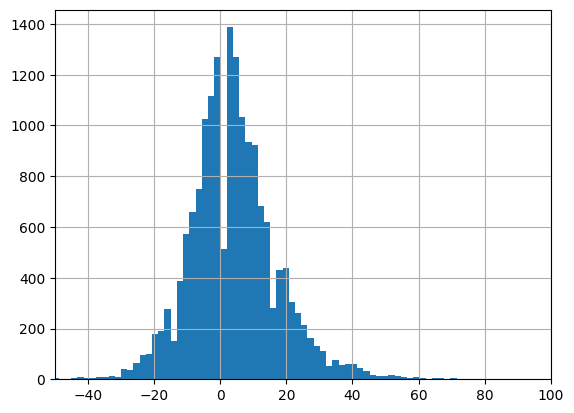

In [ ]:
df["delta_sbp"].hist(bins=100)
plt.xlim(-50, 100)

In [ ]:
df_pd = df[df["COHORT"] == 1].copy()

In [ ]:
bl_pd = df_pd[df_pd["YEAR"] == 0].copy()

In [ ]:
# boolean series
mask = (
    (bl_pd["ageonset"] >= 50) &
    (bl_pd["duration_yrs"] <=2) &
    (bl_pd["LEDD"] == 0) &
    (bl_pd["hy"] != 3)
)

ids = bl_pd.loc[mask, "PATNO"].dropna().unique()
print(len(ids))

919


In [ ]:
df_pd = df_pd[df_pd["PATNO"].isin(ids)].copy()

In [ ]:
visit_counts = df_pd.groupby("PATNO")["YEAR"].nunique()
ids_2plus = visit_counts[visit_counts >=2].index
df_pd_final = df_pd[df_pd["PATNO"].isin(ids_2plus)].copy()

In [ ]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 4542
YEAR range: 0 15
count    855.000000
mean       5.312281
std        3.653560
min        2.000000
25%        3.000000
50%        4.000000
75%        7.000000
max       15.000000
Name: YEAR, dtype: float64
YEAR
0     855
1     828
2     671
3     481
4     330
5     244
6     209
7     184
8     130
9     122
10    136
11    128
12    120
13     79
14     23
15      2
Name: PATNO, dtype: int64


In [ ]:
df_pd_final = df_pd_final[df_pd_final["YEAR"] <= 5].copy()

In [ ]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 3409
YEAR range: 0 5
count    855.000000
mean       3.987135
std        1.491921
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max        6.000000
Name: YEAR, dtype: float64
YEAR
0    855
1    828
2    671
3    481
4    330
5    244
Name: PATNO, dtype: int64


In [ ]:
vars_model = [
    "rem", "moca", "updrs3_score", "delta_sbp", "gds", "pigd"]

missing_model = df_pd_final[vars_model].isna().mean().sort_values(ascending=False)

print(missing_model)

updrs3_score    0.159871
pigd            0.157524
delta_sbp       0.029921
moca            0.010854
rem             0.008800
gds             0.008800
dtype: float64


In [ ]:
'''

report_cross = ProfileReport(
    df_pd_final,
    title="Cross Variables Report",
    explorative=True,
    correlations={
    "pearson": {"calculate": True},
    "spearman": {"calculate": True},
    "phi_k": {"calculate": True}
}
)

report_cross.to_notebook_iframe()

'''

'\n\nreport_cross = ProfileReport(\n    df_pd_final,\n    title="Cross Variables Report",\n    explorative=True,\n    correlations={\n    "pearson": {"calculate": True},\n    "spearman": {"calculate": True},\n    "phi_k": {"calculate": True}\n}\n)\n\nreport_cross.to_notebook_iframe()\n\n'

In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

# MRI Trajectories

In [ ]:
# Load the FastSurfer data
fs_data = pd.read_csv('/content/drive/MyDrive/data/FastSurfer_Master_Aggregation.csv')

# Identify the base information columns (first 4)
base_cols = fs_data.columns[:4].tolist()

# Filter columns for Left structures ('Left' or '-lh-')
left_cols = [col for col in fs_data.columns if 'Left' in col or '-lh-' in col]
df_left = fs_data[base_cols + left_cols].copy()

# Filter columns for Right structures ('Right' or '-rh-')
right_cols = [col for col in fs_data.columns if 'Right' in col or '-rh-' in col]
df_right = fs_data[base_cols + right_cols].copy()

# Display the shapes to confirm
print(f"Left dataframe shape: {df_left.shape}")
print(f"Right dataframe shape: {df_right.shape}")

Left dataframe shape: (1036, 49)
Right dataframe shape: (1036, 49)


In [ ]:
display(df_left)

,PATNO,EVENT_ID,Study_Date,Image_Description,Left-Cerebral-White-Matter,Left-Lateral-Ventricle,Left-Inf-Lat-Vent,Left-Cerebellum-White-Matter,Left-Cerebellum-Cortex,Left-Thalamus,...,ctx-lh-precentral,ctx-lh-precuneus,ctx-lh-rostralanteriorcingulate,ctx-lh-rostralmiddlefrontal,ctx-lh-superiorfrontal,ctx-lh-superiorparietal,ctx-lh-superiortemporal,ctx-lh-supramarginal,ctx-lh-transversetemporal,ctx-lh-insula
0,100001,BL,10-07-20,SAG 3D MPRAGE,235224.665,7697.275,586.895,15906.552,54048.575,7529.575,...,12064.922,7457.834,3493.038,9702.772,20438.712,8026.675,16076.755,9240.844,1081.044,5727.941
1,100001,V06,11-29-22,SAG 3D MPRAGE,230059.881,7965.760,667.278,15961.318,53076.050,7438.111,...,11907.451,7530.868,3413.702,9593.357,20010.732,7910.193,16023.621,9298.589,1117.221,5714.787
2,100001,V10,09-11-24,SAG 3D T1 FSPGR,244662.726,8999.780,580.990,14026.028,58313.647,8197.307,...,11424.819,7154.704,3485.061,10334.243,21138.633,8082.966,16593.472,9533.689,1001.641,5677.020
3,100005,BL,01-27-21,3D T1 _weighted,299543.184,8022.178,293.206,19243.413,65558.294,9746.962,...,13651.467,10810.150,4329.064,10718.826,24612.513,12910.334,18687.815,12506.005,1310.407,6587.379
4,100005,V04,02-02-22,3D T1 _weighted,297242.437,8420.090,324.843,18826.308,64739.797,9713.446,...,13541.982,10715.661,4155.097,10198.558,24331.718,13148.321,18896.476,12423.183,1254.832,6429.517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1031,4136,V04,05-06-14,MPRAGE w/ GRAPPA,247659.996,11596.696,615.133,16375.178,60015.193,7017.809,...,11493.879,10286.490,3843.442,9790.547,22086.199,9099.882,17045.004,9647.936,1265.917,6481.328
1032,50983,BL,05-15-15,MPRAGE w/ GRAPPA,224320.810,14907.183,453.889,13841.691,50549.675,6644.079,...,12088.615,8197.011,3642.577,10313.506,24094.047,8262.226,16532.755,9188.438,1379.205,6395.442
1033,50983,V06,10-16-17,MPRAGE GRAPPA,216215.943,15443.348,447.903,13279.583,50159.339,6564.247,...,12411.343,8153.953,3699.306,10440.581,24415.957,8754.467,17231.840,9326.201,1481.106,6557.618
1034,71978,BL,10-31-17,T1,214972.367,8740.640,423.146,11651.999,39281.257,6392.438,...,11610.922,8584.405,2548.723,9605.869,24024.536,8964.875,14914.721,8543.521,1474.688,5623.378


In [ ]:
# Function to strip prefixes from column names
def clean_column_names(df, side_prefixes):
    new_cols = []
    for col in df.columns:
        new_col = col
        for pref in side_prefixes:
            if col.startswith(pref):
                new_col = col.replace(pref, "")
                break
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Define prefixes to remove
left_prefixes = ['Left-', 'ctx-lh-']
right_prefixes = ['Right-', 'ctx-rh-']

# Clean the dataframes
# First 4 columns are base_cols, so we don't clean them
df_left_clean = df_left.copy()
df_right_clean = df_right.copy()

clean_column_names(df_left_clean, left_prefixes)
clean_column_names(df_right_clean, right_prefixes)

# Identify region columns (excluding metadata)
regions = [col for col in df_left_clean.columns if col not in base_cols]

# Calculate correlations
correlation_results = []

for region in regions:
    if region in df_right_clean.columns:
        # Extract the series and drop any combined NaNs
        combined = pd.concat([df_left_clean[region], df_right_clean[region]], axis=1).dropna()

        if len(combined) > 1:
            pearson = combined.corr(method='pearson').iloc[0, 1]
            spearman = combined.corr(method='spearman').iloc[0, 1]

            correlation_results.append({
                'Region': region,
                'Pearson_R': pearson,
                'Spearman_R': spearman,
                'N': len(combined)
            })

# Create a results dataframe and display it
df_correlations = pd.DataFrame(correlation_results)
display(df_correlations)

,Region,Pearson_R,Spearman_R,N
0,Cerebral-White-Matter,0.994696,0.994260,1036
1,Lateral-Ventricle,0.920246,0.902667,1036
2,Inf-Lat-Vent,0.894844,0.786941,1036
3,Cerebellum-White-Matter,0.968630,0.968882,1036
4,Cerebellum-Cortex,0.973851,0.974143,1036
5,Thalamus,0.953680,0.947636,1036
6,Caudate,0.939073,0.938378,1036
7,Putamen,0.930030,0.947440,1036
8,Pallidum,0.919285,0.918071,1036
9,Hippocampus,0.904356,0.900105,1036


In [ ]:
# Identify region columns
regions = [col for col in df_left_clean.columns if col not in base_cols]

# Create normalized dataframes by dividing structural volumes by MaskVol
# Note: MaskVol is in column index 4 of the original fs_data (or we can extract it specifically)
mask_vol = fs_data['MaskVol']

df_left_norm = df_left_clean[regions].div(mask_vol, axis=0)
df_right_norm = df_right_clean[regions].div(mask_vol, axis=0)

# Re-calculate correlations with normalized data
normalized_correlation_results = []

for region in regions:
    if region in df_right_norm.columns:
        combined = pd.concat([df_left_norm[region], df_right_norm[region]], axis=1).dropna()

        if len(combined) > 1:
            pearson = combined.corr(method='pearson').iloc[0, 1]
            spearman = combined.corr(method='spearman').iloc[0, 1]

            normalized_correlation_results.append({
                'Region': region,
                'Pearson_R_Norm': pearson,
                'Spearman_R_Norm': spearman,
                'N': len(combined)
            })

df_correlations_norm = pd.DataFrame(normalized_correlation_results)
print("Correlations after normalization by MaskVol:")
display(df_correlations_norm)

Correlations after normalization by MaskVol:


,Region,Pearson_R_Norm,Spearman_R_Norm,N
0,Cerebral-White-Matter,0.978665,0.976978,1036
1,Lateral-Ventricle,0.911955,0.891416,1036
2,Inf-Lat-Vent,0.893539,0.779661,1036
3,Cerebellum-White-Matter,0.954836,0.956528,1036
4,Cerebellum-Cortex,0.956423,0.952379,1036
5,Thalamus,0.921574,0.915108,1036
6,Caudate,0.922328,0.912965,1036
7,Putamen,0.899046,0.923623,1036
8,Pallidum,0.876316,0.856522,1036
9,Hippocampus,0.876504,0.873108,1036


In [ ]:
# Regions identified with 1035 subjects
check_regions = ['rostralanteriorcingulate', 'Accumbens-area', 'medialorbitofrontal', 'Pallidum']

for region in check_regions:
    # Find subjects where either left or right is NaN or Zero
    mask_missing = (
        df_left_clean[region].isna() | (df_left_clean[region] == 0) |
        df_right_clean[region].isna() | (df_right_clean[region] == 0)
    )

    missing_info = fs_data.loc[mask_missing, ['PATNO', 'EVENT_ID']]
    print(f"\nMissing/Zero data for {region}:")
    if len(missing_info) > 0:
        display(missing_info)
    else:
        print("No explicit NaNs or Zeros found in cleaning; likely dropped during previous concatenation step.")


Missing/Zero data for rostralanteriorcingulate:


,PATNO,EVENT_ID
496,182427,BL



Missing/Zero data for Accumbens-area:


,PATNO,EVENT_ID
496,182427,BL



Missing/Zero data for medialorbitofrontal:


,PATNO,EVENT_ID
496,182427,BL



Missing/Zero data for Pallidum:


,PATNO,EVENT_ID
496,182427,BL


In [ ]:
import pandas as pd
import numpy as np

# Initialize a list to store descriptive stats for each region
pct_diff_stats = []

for region in regions:
    if region in df_right_clean.columns:
        left_vals = df_left_clean[region]
        right_vals = df_right_clean[region]

        # Calculate absolute percentage difference per subject
        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Remove NaNs and Infs resulting from division by zero if any
        pct_diff = pct_diff.replace([np.inf, -np.inf], np.nan).dropna()

        if len(pct_diff) > 0:
            pct_diff_stats.append({
                'Region': region,
                'Mean_%_Diff': pct_diff.mean(),
                'Std_%_Diff': pct_diff.std(),
                'Min_%_Diff': pct_diff.min(),
                'Max_%_Diff': pct_diff.max(),
                'N_Subjects': len(pct_diff)
            })

# Create a results dataframe
df_pct_stats = pd.DataFrame(pct_diff_stats).sort_values(by='Mean_%_Diff', ascending=False)

print("Descriptive Statistics for Percentage Differences (|L-R|/Mean * 100):")
display(df_pct_stats)

Descriptive Statistics for Percentage Differences (|L-R|/Mean * 100):


,Region,Mean_%_Diff,Std_%_Diff,Min_%_Diff,Max_%_Diff,N_Subjects
37,rostralanteriorcingulate,37.253482,15.923502,2.425605,99.737916,1035
14,caudalanteriorcingulate,33.103496,18.712059,0.047972,200.000000,1036
43,transversetemporal,29.654958,14.529852,0.152966,83.637823,1036
2,Inf-Lat-Vent,24.147207,18.146463,0.004528,104.697524,1036
19,inferiorparietal,18.810011,9.314254,0.138756,51.901975,1036
1,Lateral-Ventricle,18.661523,14.962831,0.018249,76.258258,1036
32,pericalcarine,15.370661,10.229845,0.045001,56.165169,1036
11,Accumbens-area,15.340027,10.848936,0.038184,89.536097,1035
15,caudalmiddlefrontal,13.523450,10.889787,0.013407,64.370030,1036
31,parstriangularis,13.518577,12.127455,0.025653,198.224954,1036


In [ ]:
import pandas as pd
import numpy as np

extreme_cases = []

for region in regions:
    if region in df_right_clean.columns:
        left_vals = df_left_clean[region]
        right_vals = df_right_clean[region]

        # Calculate absolute percentage difference
        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Identify indices where pct_diff > 100
        outliers = pct_diff[pct_diff > 100].index

        for idx in outliers:
            extreme_cases.append({
                'PATNO': fs_data.loc[idx, 'PATNO'],
                'EVENT_ID': fs_data.loc[idx, 'EVENT_ID'],
                'Region': region,
                'Pct_Diff': pct_diff[idx],
                'Left_Vol': left_vals[idx],
                'Right_Vol': right_vals[idx]
            })

df_extreme = pd.DataFrame(extreme_cases)

if not df_extreme.empty:
    print("Cases with >100% asymmetry:")
    summary_sessions = df_extreme.groupby(['PATNO', 'EVENT_ID']).agg(
        Failed_Regions_Count=('Region', 'count'),
        Regions_List=('Region', lambda x: ', '.join(x))
    ).reset_index()
    display(summary_sessions)
else:
    print("No cases found with >100% asymmetry.")

Cases with >100% asymmetry:


,PATNO,EVENT_ID,Failed_Regions_Count,Regions_List
0,3314,BL,1,lingual
1,3314,V04,1,lingual
2,102054,BL,1,Inf-Lat-Vent
3,102054,V04,1,Inf-Lat-Vent
4,182427,BL,7,"Cerebellum-White-Matter, Putamen, caudalanteri..."


In [ ]:
import pandas as pd
import numpy as np

# 1. Define the exclusion criteria
exclude_mask = (fs_data['PATNO'] == 182427) & (fs_data['EVENT_ID'] == 'BL')

# 2. Filter all relevant dataframes
fs_data = fs_data[~exclude_mask].reset_index(drop=True)
df_left_clean = df_left_clean[~exclude_mask].reset_index(drop=True)
df_right_clean = df_right_clean[~exclude_mask].reset_index(drop=True)

print(f"Removed scan 182427 BL. New row count: {len(fs_data)}")

# 3. Re-run asymmetry check with 75% threshold
threshold = 75
flagged_cases = []

# 'regions' variable is defined in previous cells
for region in regions:
    if region in df_right_clean.columns:
        left_vals = df_left_clean[region]
        right_vals = df_right_clean[region]

        # Calculate absolute percentage difference
        # |L - R| / Mean(L, R) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Identify indices where pct_diff > threshold
        outliers = pct_diff[pct_diff > threshold].index

        for idx in outliers:
            flagged_cases.append({
                'PATNO': fs_data.loc[idx, 'PATNO'],
                'EVENT_ID': fs_data.loc[idx, 'EVENT_ID'],
                'Region': region,
                'Pct_Diff': pct_diff[idx],
                'Left_Vol': left_vals[idx],
                'Right_Vol': right_vals[idx]
            })

df_flagged = pd.DataFrame(flagged_cases)

if not df_flagged.empty:
    print(f"\nSessions with at least one region exceeding {threshold}% asymmetry:")
    summary_flagged = df_flagged.groupby(['PATNO', 'EVENT_ID']).agg(
        Flagged_Regions_Count=('Region', 'count'),
        Regions_List=('Region', lambda x: ', '.join(x))
    ).reset_index().sort_values(by='Flagged_Regions_Count', ascending=False)
    display(summary_flagged)
else:
    print(f"\nNo cases found exceeding {threshold}% asymmetry threshold.")

Removed scan 182427 BL. New row count: 1035

Sessions with at least one region exceeding 75% asymmetry:


,PATNO,EVENT_ID,Flagged_Regions_Count,Regions_List
4,3314,BL,2,"lingual, transversetemporal"
5,3314,V04,2,"lingual, transversetemporal"
0,3118,V04,1,rostralanteriorcingulate
2,3131,BL,1,rostralanteriorcingulate
1,3118,V06,1,rostralanteriorcingulate
3,3131,V04,1,rostralanteriorcingulate
6,3323,V08,1,Accumbens-area
7,3592,V04,1,Inf-Lat-Vent
8,3780,BL,1,caudalanteriorcingulate
9,3780,V04,1,caudalanteriorcingulate


# MRI Preparation

In [ ]:
path_vol = "/content/drive/MyDrive/data/Volume values summarized over ASEG parcellation_17Aug2025.csv"
path_SA = "/content/drive/MyDrive/data/Surface area (SA) values summarized over aparc parcellation_17Aug2025.csv"
path_CTh = "/content/drive/MyDrive/data/Cortical thickness (CTh) values summarized over aparc parcellation_17Aug2025.csv"
path_mriqc = "/content/drive/MyDrive/data/MRIQC metrics for T1-weighted images_17Aug2025.csv"

## Volumes

In [ ]:
volumes_to_norm = [
    "Optic_Chiasm",
    "Right_Lateral_Ventricle",
    "CC_Central",
    "5th_Ventricle",
    "Right_choroid_plexus",
    "Left_vessel",
    "Left_Cerebellum_Cortex",
    "TotalGrayVol",
    "Left_choroid_plexus",
    "Right_Inf_Lat_Vent",
    "Left_Pallidum",
    "Left_Thalamus",
    "Right_VentralDC",
    "rhCortexVol",
    "Right_Amygdala",
    "Left_Amygdala",
    "4th_Ventricle",
    "Left_Inf_Lat_Vent",
    "Right_Pallidum",
    "lhCortexVol",
    "CC_Anterior",
    "CC_Posterior",
    "Left_Accumbens_area",
    "Right_vessel",
    "Right_Cerebellum_Cortex",
    "Left_Putamen",
    "3rd_Ventricle",
    "non_WM_hypointensities",
    "Right_Caudate",
    "CC_Mid_Posterior",
    "Left_Hippocampus",
    "Right_Hippocampus",
    "Left_Caudate",
    "Right_Putamen",
    "WM_hypointensities",
    "Right_Accumbens_area",
    "Left_VentralDC",
    "CC_Mid_Anterior",
    "SubCortGrayVol",
    "Right_Thalamus",
    "Left_Lateral_Ventricle",
    "SurfaceHoles",
    "CerebralWhiteMatterVol"
]

In [ ]:
cols_vol = ["PATNO"] + volumes_to_norm + ["EstimatedTotalIntraCranialVol"]
df_vol = pd.read_csv(path_vol, usecols=cols_vol)

display(df_vol.head())

,PATNO,Optic_Chiasm,Right_Lateral_Ventricle,CC_Central,5th_Ventricle,Right_choroid_plexus,Left_vessel,Left_Cerebellum_Cortex,TotalGrayVol,Left_choroid_plexus,...,Right_Putamen,WM_hypointensities,Right_Accumbens_area,Left_VentralDC,CC_Mid_Anterior,SubCortGrayVol,Right_Thalamus,Left_Lateral_Ventricle,SurfaceHoles,CerebralWhiteMatterVol
0,3000,96.7,9579.3,936.4,0.0,537.7,12.2,54840.0,600024,747.9,...,3956.8,3690.8,411.8,4188.8,599.2,52729.0,7122.1,9970.7,23,497730
1,3001,152.0,17897.3,887.0,0.0,633.1,40.8,59127.2,651817,716.5,...,6070.9,7263.3,351.5,4407.5,542.6,67357.0,7495.3,22811.9,26,565148
2,3002,102.1,8822.4,568.9,0.0,592.4,0.0,52148.3,572593,495.2,...,5537.5,2404.1,375.4,3191.4,725.7,54813.0,6470.1,8445.8,23,425313
3,3003,107.3,8620.4,1020.8,4.1,623.8,0.0,56613.4,616339,682.2,...,6072.6,1081.3,481.7,4427.0,1279.4,60577.0,7458.9,9266.9,16,510845
4,3004,135.3,9447.4,857.1,0.0,420.0,8.5,50758.6,623995,358.6,...,5349.4,632.7,489.1,3837.1,831.4,56642.0,6451.1,6889.7,21,540211


In [ ]:
df_vol[volumes_to_norm] = df_vol[volumes_to_norm].div(df_vol["EstimatedTotalIntraCranialVol"], axis=0)
df_vol.drop(columns=["EstimatedTotalIntraCranialVol"], inplace=True)

In [ ]:
display(df_vol.head())

,PATNO,Optic_Chiasm,Right_Lateral_Ventricle,CC_Central,5th_Ventricle,Right_choroid_plexus,Left_vessel,Left_Cerebellum_Cortex,TotalGrayVol,Left_choroid_plexus,...,Right_Putamen,WM_hypointensities,Right_Accumbens_area,Left_VentralDC,CC_Mid_Anterior,SubCortGrayVol,Right_Thalamus,Left_Lateral_Ventricle,SurfaceHoles,CerebralWhiteMatterVol
0,3000,0.000061,0.006076,0.000594,0.000000,0.000341,0.000008,0.034784,0.380586,0.000474,...,0.002510,0.002341,0.000261,0.002657,0.000380,0.033445,0.004517,0.006324,0.000015,0.315702
1,3001,0.000088,0.010382,0.000515,0.000000,0.000367,0.000024,0.034300,0.378124,0.000416,...,0.003522,0.004213,0.000204,0.002557,0.000315,0.039074,0.004348,0.013233,0.000015,0.327846
2,3002,0.000075,0.006459,0.000417,0.000000,0.000434,0.000000,0.038179,0.419209,0.000363,...,0.004054,0.001760,0.000275,0.002336,0.000531,0.040130,0.004737,0.006183,0.000017,0.311382
3,3003,0.000068,0.005438,0.000644,0.000003,0.000394,0.000000,0.035715,0.388823,0.000430,...,0.003831,0.000682,0.000304,0.002793,0.000807,0.038216,0.004706,0.005846,0.000010,0.322271
4,3004,0.000083,0.005796,0.000526,0.000000,0.000258,0.000005,0.031143,0.382852,0.000220,...,0.003282,0.000388,0.000300,0.002354,0.000510,0.034753,0.003958,0.004227,0.000013,0.331446


Averaging or considering only one side of the brain is common in analysis of MRI data, for example: https://pmc.ncbi.nlm.nih.gov/articles/PMC3316476/.

In [ ]:
df_vol_rh = df_vol.loc[:, df_vol.columns.str.contains("PATNO|Right|rh")]
df_vol_lh = df_vol.loc[:, df_vol.columns.str.contains("PATNO|Left|lh")]
df_vol_both = df_vol.loc[:, ~df_vol.columns.str.contains("Right|Left|lh|rh")]

display(df_vol_both)

,PATNO,Optic_Chiasm,CC_Central,5th_Ventricle,TotalGrayVol,4th_Ventricle,CC_Anterior,CC_Posterior,3rd_Ventricle,non_WM_hypointensities,CC_Mid_Posterior,WM_hypointensities,CC_Mid_Anterior,SubCortGrayVol,SurfaceHoles,CerebralWhiteMatterVol
0,3000,0.000061,0.000594,0.000000,0.380586,0.001441,0.000611,0.000645,0.001143,0.0,0.000484,0.002341,0.000380,0.033445,0.000015,0.315702
1,3001,0.000088,0.000515,0.000000,0.378124,0.001144,0.000629,0.000857,0.001074,0.0,0.000606,0.004213,0.000315,0.039074,0.000015,0.327846
2,3002,0.000075,0.000417,0.000000,0.419209,0.001336,0.000724,0.000946,0.000628,0.0,0.000481,0.001760,0.000531,0.040130,0.000017,0.311382
3,3003,0.000068,0.000644,0.000003,0.388823,0.000886,0.000876,0.000895,0.000550,0.0,0.000475,0.000682,0.000807,0.038216,0.000010,0.322271
4,3004,0.000083,0.000526,0.000000,0.382852,0.001474,0.000790,0.000755,0.000554,0.0,0.000494,0.000388,0.000510,0.034753,0.000013,0.331446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1708,219562,0.000061,0.000611,0.000000,0.498677,0.001582,0.000752,0.000873,0.001424,0.0,0.000476,0.003201,0.000566,0.048453,0.000018,0.409846
1709,219621,0.000065,0.000276,0.000000,0.373641,0.001621,0.000561,0.000696,0.001072,0.0,0.000262,0.001496,0.000265,0.031785,0.000003,0.301953
1710,219715,0.000069,0.000286,0.000000,0.386155,0.001367,0.000488,0.000637,0.000988,0.0,0.000358,0.002967,0.000289,0.038355,0.000007,0.306493
1711,220392,0.000118,0.000268,0.000000,0.391271,0.001161,0.000542,0.000581,0.001110,0.0,0.000274,0.001112,0.000295,0.034588,0.000008,0.325719


In [ ]:
display(df_vol_lh.head())

,PATNO,Left_vessel,Left_Cerebellum_Cortex,Left_choroid_plexus,Left_Pallidum,Left_Thalamus,Left_Amygdala,Left_Inf_Lat_Vent,lhCortexVol,Left_Accumbens_area,Left_Putamen,Left_Hippocampus,Left_Caudate,Left_VentralDC,Left_Lateral_Ventricle
0,3000,0.000008,0.034784,0.000474,0.001120,0.004412,0.000609,0.000275,0.136488,0.000102,0.002778,0.002208,0.001800,0.002657,0.006324
1,3001,0.000024,0.034300,0.000416,0.001316,0.004494,0.000939,0.000435,0.134334,0.000193,0.004275,0.002506,0.003064,0.002557,0.013233
2,3002,0.000000,0.038179,0.000363,0.001401,0.004982,0.000826,0.000130,0.150916,0.000266,0.003705,0.002508,0.002739,0.002336,0.006183
3,3003,0.000000,0.035715,0.000430,0.001320,0.004701,0.000888,0.000155,0.139183,0.000209,0.003049,0.002943,0.001974,0.002793,0.005846
4,3004,0.000005,0.031143,0.000220,0.000855,0.004993,0.000959,0.000258,0.141850,0.000243,0.003303,0.002574,0.001886,0.002354,0.004227


In [ ]:
display(df_vol_rh.head())

,PATNO,Right_Lateral_Ventricle,Right_choroid_plexus,Right_Inf_Lat_Vent,Right_VentralDC,rhCortexVol,Right_Amygdala,Right_Pallidum,Right_vessel,Right_Cerebellum_Cortex,Right_Caudate,Right_Hippocampus,Right_Putamen,Right_Accumbens_area,Right_Thalamus
0,3000,0.006076,0.000341,0.000172,0.002384,0.140064,0.001070,0.001096,0.000000,0.035308,0.002001,0.002839,0.002510,0.000261,0.004517
1,3001,0.010382,0.000367,0.000385,0.002410,0.134446,0.001205,0.001293,0.000000,0.035421,0.002969,0.002639,0.003522,0.000204,0.004348
2,3002,0.006459,0.000434,0.000152,0.002632,0.149069,0.001220,0.001653,0.000013,0.041034,0.002649,0.002676,0.004054,0.000275,0.004737
3,3003,0.005438,0.000394,0.000349,0.002700,0.138542,0.001176,0.001349,0.000000,0.036769,0.002271,0.003052,0.003831,0.000304,0.004706
4,3004,0.005796,0.000258,0.000267,0.002170,0.142636,0.001178,0.001146,0.000000,0.031952,0.002036,0.002567,0.003282,0.000300,0.003958


In [ ]:
df_vol_rh.columns = df_vol_rh.columns.str.replace("Right_", "")
df_vol_rh.columns = df_vol_rh.columns.str.replace("rh", "")
df_vol_lh.columns = df_vol_lh.columns.str.replace("Left_", "")
df_vol_lh.columns = df_vol_lh.columns.str.replace("lh", "")
lh_indexing = df_vol_lh.columns
df_vol_rh = df_vol_rh[lh_indexing]
# rearrange columns so that the left and right regions are at the same column index in their respective dataframes

display(df_vol_rh)
print(lh_indexing)

,PATNO,vessel,Cerebellum_Cortex,choroid_plexus,Pallidum,Thalamus,Amygdala,Inf_Lat_Vent,CortexVol,Accumbens_area,Putamen,Hippocampus,Caudate,VentralDC,Lateral_Ventricle
0,3000,0.000000,0.035308,0.000341,0.001096,0.004517,0.001070,0.000172,0.140064,0.000261,0.002510,0.002839,0.002001,0.002384,0.006076
1,3001,0.000000,0.035421,0.000367,0.001293,0.004348,0.001205,0.000385,0.134446,0.000204,0.003522,0.002639,0.002969,0.002410,0.010382
2,3002,0.000013,0.041034,0.000434,0.001653,0.004737,0.001220,0.000152,0.149069,0.000275,0.004054,0.002676,0.002649,0.002632,0.006459
3,3003,0.000000,0.036769,0.000394,0.001349,0.004706,0.001176,0.000349,0.138542,0.000304,0.003831,0.003052,0.002271,0.002700,0.005438
4,3004,0.000000,0.031952,0.000258,0.001146,0.003958,0.001178,0.000267,0.142636,0.000300,0.003282,0.002567,0.002036,0.002170,0.005796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1708,219562,0.000006,0.041335,0.000659,0.001985,0.005649,0.001988,0.000167,0.183900,0.000490,0.004046,0.004372,0.002336,0.003238,0.008378
1709,219621,0.000006,0.035898,0.000591,0.001051,0.004152,0.001102,0.000604,0.136056,0.000243,0.002546,0.002404,0.001998,0.002469,0.019642
1710,219715,0.000013,0.034474,0.000684,0.001274,0.004591,0.001364,0.000466,0.139501,0.000405,0.002996,0.003069,0.002684,0.002465,0.007893
1711,220392,0.000011,0.033683,0.000506,0.001233,0.004277,0.001156,0.000150,0.145304,0.000319,0.002710,0.002658,0.002191,0.002302,0.008862


Index(['PATNO', 'vessel', 'Cerebellum_Cortex', 'choroid_plexus', 'Pallidum',
       'Thalamus', 'Amygdala', 'Inf_Lat_Vent', 'CortexVol', 'Accumbens_area',
       'Putamen', 'Hippocampus', 'Caudate', 'VentralDC', 'Lateral_Ventricle'],
      dtype='object')


In [ ]:
df_corr1 = pd.DataFrame({'Pearson': df_vol_rh.corrwith(df_vol_lh, axis=0, method="pearson"),
                        'Spearman': df_vol_rh.corrwith(df_vol_lh, axis=0, method="spearman")})
display(df_corr1)

,Pearson,Spearman
PATNO,1.000000,1.000000
vessel,0.286563,0.412508
Cerebellum_Cortex,0.957744,0.948929
choroid_plexus,0.788381,0.786011
Pallidum,0.756496,0.748152
Thalamus,0.850576,0.840325
Amygdala,0.807755,0.803125
Inf_Lat_Vent,0.794894,0.713040
CortexVol,0.986438,0.982719
Accumbens_area,0.768464,0.757798


In [ ]:
from functools import reduce

df_vol_avg = reduce(lambda x, y: x.add(y), [df_vol_lh, df_vol_rh]) / 2    # add up all elements and divide by 2
df_vol_both = df_vol_both.merge(df_vol_avg.drop(columns=["PATNO", "vessel"]), left_index=True, right_index=True)
display(df_vol_both)

,PATNO,Optic_Chiasm,CC_Central,5th_Ventricle,TotalGrayVol,4th_Ventricle,CC_Anterior,CC_Posterior,3rd_Ventricle,non_WM_hypointensities,...,Thalamus,Amygdala,Inf_Lat_Vent,CortexVol,Accumbens_area,Putamen,Hippocampus,Caudate,VentralDC,Lateral_Ventricle
0,3000,0.000061,0.000594,0.000000,0.380586,0.001441,0.000611,0.000645,0.001143,0.0,...,0.004465,0.000840,0.000224,0.138276,0.000181,0.002644,0.002523,0.001900,0.002520,0.006200
1,3001,0.000088,0.000515,0.000000,0.378124,0.001144,0.000629,0.000857,0.001074,0.0,...,0.004421,0.001072,0.000410,0.134390,0.000199,0.003898,0.002573,0.003017,0.002483,0.011808
2,3002,0.000075,0.000417,0.000000,0.419209,0.001336,0.000724,0.000946,0.000628,0.0,...,0.004860,0.001023,0.000141,0.149992,0.000270,0.003880,0.002592,0.002694,0.002484,0.006321
3,3003,0.000068,0.000644,0.000003,0.388823,0.000886,0.000876,0.000895,0.000550,0.0,...,0.004703,0.001032,0.000252,0.138863,0.000256,0.003440,0.002997,0.002122,0.002746,0.005642
4,3004,0.000083,0.000526,0.000000,0.382852,0.001474,0.000790,0.000755,0.000554,0.0,...,0.004476,0.001068,0.000263,0.142243,0.000272,0.003293,0.002570,0.001961,0.002262,0.005012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1708,219562,0.000061,0.000611,0.000000,0.498677,0.001582,0.000752,0.000873,0.001424,0.0,...,0.005496,0.001918,0.000183,0.184675,0.000368,0.003941,0.004159,0.002417,0.003309,0.008660
1709,219621,0.000065,0.000276,0.000000,0.373641,0.001621,0.000561,0.000696,0.001072,0.0,...,0.004146,0.000905,0.000741,0.135232,0.000188,0.002472,0.002220,0.001944,0.002474,0.018146
1710,219715,0.000069,0.000286,0.000000,0.386155,0.001367,0.000488,0.000637,0.000988,0.0,...,0.004615,0.001195,0.000603,0.139536,0.000329,0.002955,0.002874,0.002678,0.002562,0.008289
1711,220392,0.000118,0.000268,0.000000,0.391271,0.001161,0.000542,0.000581,0.001110,0.0,...,0.004279,0.001121,0.000158,0.145757,0.000336,0.002719,0.002650,0.002052,0.002337,0.008908


In [ ]:
import pandas as pd
import numpy as np

# Initialize a list to store descriptive stats for each FreeSurfer volume region
fs_vol_pct_diff_stats = []

# Identify region columns (excluding PATNO)
# We use the cleaned column names from df_vol_lh and df_vol_rh which already align
regions_fs = [col for col in df_vol_lh.columns if col not in ['PATNO', 'vessel']]

for region in regions_fs:
    if region in df_vol_rh.columns:
        left_vals = df_vol_lh[region]
        right_vals = df_vol_rh[region]

        # Calculate absolute percentage difference per subject
        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Remove NaNs and Infs resulting from division by zero if any
        pct_diff = pct_diff.replace([np.inf, -np.inf], np.nan).dropna()

        if len(pct_diff) > 0:
            fs_vol_pct_diff_stats.append({
                'Region': region,
                'Mean_%_Diff': pct_diff.mean(),
                'Std_%_Diff': pct_diff.std(),
                'Min_%_Diff': pct_diff.min(),
                'Max_%_Diff': pct_diff.max(),
                'N_Subjects': len(pct_diff)
            })

# Create a results dataframe
df_fs_vol_pct_stats = pd.DataFrame(fs_vol_pct_diff_stats).sort_values(by='Mean_%_Diff', ascending=False)

print("Descriptive Statistics for FreeSurfer Volume Percentage Differences (|L-R|/Mean * 100):")
display(df_fs_vol_pct_stats)

Descriptive Statistics for FreeSurfer Volume Percentage Differences (|L-R|/Mean * 100):


,Region,Mean_%_Diff,Std_%_Diff,Min_%_Diff,Max_%_Diff,N_Subjects
5,Inf_Lat_Vent,34.537522,27.096550,0.099817,195.623632,1713
7,Accumbens_area,24.355760,17.755629,0.042830,92.614770,1713
12,Lateral_Ventricle,17.409840,14.259661,0.006101,89.136700,1713
1,choroid_plexus,17.020110,13.555319,0.031521,102.992407,1713
4,Amygdala,11.446956,8.836274,0.000000,125.999908,1713
2,Pallidum,6.826658,5.849995,0.000000,72.171685,1713
10,Caudate,5.489942,5.654802,0.011348,92.025005,1713
9,Hippocampus,5.240451,5.057877,0.008744,83.810376,1713
3,Thalamus,4.955755,4.351874,0.010079,33.150508,1713
8,Putamen,4.546109,5.805103,0.000000,115.444962,1713


In [ ]:
import pandas as pd
import numpy as np

fs_vol_extreme_cases = []

# Using regions_fs defined in the previous analysis
for region in regions_fs:
    if region in df_vol_rh.columns:
        left_vals = df_vol_lh[region]
        right_vals = df_vol_rh[region]

        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Identify indices where pct_diff > 100
        outliers = pct_diff[pct_diff > 100].index

        for idx in outliers:
            # We use the original df_vol or a lookup to get the PATNO
            patno = df_vol_lh.loc[idx, 'PATNO']
            fs_vol_extreme_cases.append({
                'PATNO': patno,
                'Region': region,
                'Pct_Diff': pct_diff[idx],
                'Left_Vol': left_vals[idx],
                'Right_Vol': right_vals[idx]
            })

df_fs_vol_extreme = pd.DataFrame(fs_vol_extreme_cases)

# Filter df_fs_vol_extreme to include only PATNOs present in df_pd_final
patnos_in_pd_final = df_pd_final['PATNO'].unique()
df_fs_vol_extreme_filtered = df_fs_vol_extreme[df_fs_vol_extreme['PATNO'].isin(patnos_in_pd_final)].copy()

if not df_fs_vol_extreme_filtered.empty:
    print("FreeSurfer cases with >100% asymmetry (filtered to df_pd_final subjects):")
    summary_fs_extreme = df_fs_vol_extreme_filtered.groupby(['PATNO']).agg(
        Failed_Regions_Count=('Region', 'count'),
        Regions_List=('Region', lambda x: ', '.join(x))
    ).reset_index().sort_values(by='Failed_Regions_Count', ascending=False)
    display(summary_fs_extreme)
else:
    print("No FreeSurfer volume cases found with >100% asymmetry within df_pd_final subjects.")

FreeSurfer cases with >100% asymmetry (filtered to df_pd_final subjects):


,PATNO,Failed_Regions_Count,Regions_List
0,3076,1,Inf_Lat_Vent
1,3409,1,Inf_Lat_Vent
2,3417,1,Inf_Lat_Vent
3,3763,1,Inf_Lat_Vent
4,3957,1,Putamen
5,3972,1,Inf_Lat_Vent
6,101799,1,Inf_Lat_Vent
7,111278,1,Inf_Lat_Vent


In [ ]:
import pandas as pd
import numpy as np

fs_vol_extreme_cases = []

# Using regions_fs defined in the previous analysis
for region in regions_fs:
    if region in df_vol_rh.columns:
        left_vals = df_vol_lh[region]
        right_vals = df_vol_rh[region]

        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Identify indices where pct_diff > 75
        outliers = pct_diff[pct_diff > 75].index

        for idx in outliers:
            # We use the original df_vol or a lookup to get the PATNO
            patno = df_vol_lh.loc[idx, 'PATNO']
            fs_vol_extreme_cases.append({
                'PATNO': patno,
                'Region': region,
                'Pct_Diff': pct_diff[idx],
                'Left_Vol': left_vals[idx],
                'Right_Vol': right_vals[idx]
            })

df_fs_vol_extreme = pd.DataFrame(fs_vol_extreme_cases)

# Filter df_fs_vol_extreme to include only PATNOs present in df_pd_final
patnos_in_pd_final = df_pd_final['PATNO'].unique()
df_fs_vol_extreme_filtered = df_fs_vol_extreme[df_fs_vol_extreme['PATNO'].isin(patnos_in_pd_final)].copy()

if not df_fs_vol_extreme_filtered.empty:
    print("FreeSurfer cases with >75% asymmetry (filtered to df_pd_final subjects):")
    summary_fs_extreme = df_fs_vol_extreme_filtered.groupby(['PATNO']).agg(
        Failed_Regions_Count=('Region', 'count'),
        Regions_List=('Region', lambda x: ', '.join(x))
    ).reset_index().sort_values(by='Failed_Regions_Count', ascending=False)
    display(summary_fs_extreme)
else:
    print("No FreeSurfer volume cases found with >75% asymmetry within df_pd_final subjects.")

FreeSurfer cases with >75% asymmetry (filtered to df_pd_final subjects):


,PATNO,Failed_Regions_Count,Regions_List
14,3630,2,"Inf_Lat_Vent, Accumbens_area"
1,3076,1,Inf_Lat_Vent
0,3056,1,Inf_Lat_Vent
3,3269,1,Caudate
4,3275,1,Caudate
5,3285,1,choroid_plexus
2,3251,1,Accumbens_area
6,3307,1,Accumbens_area
7,3325,1,Inf_Lat_Vent
9,3409,1,Inf_Lat_Vent


## Surface Areas and Cortical Thicknesses

In [ ]:
df_SA = pd.read_csv(path_SA)
df_CTh = pd.read_csv(path_CTh)

df_SA_rh = df_SA.loc[:, df_SA.columns.str.contains("PATNO|rh_")]
df_SA_lh = df_SA.loc[:, df_SA.columns.str.contains("PATNO|lh_")]

df_CTh_rh = df_CTh.loc[:, df_CTh.columns.str.contains("PATNO|rh_")]
df_CTh_lh = df_CTh.loc[:, df_CTh.columns.str.contains("PATNO|lh_")]

display(df_SA_rh.head())

,PATNO,rh_bankssts,rh_caudalanteriorcingulate,rh_caudalmiddlefrontal,rh_cuneus,rh_entorhinal,rh_fusiform,rh_inferiorparietal,rh_inferiortemporal,rh_isthmuscingulate,...,rh_rostralmiddlefrontal,rh_superiorfrontal,rh_superiorparietal,rh_superiortemporal,rh_supramarginal,rh_frontalpole,rh_temporalpole,rh_transversetemporal,rh_insula,rh_WhiteSurfArea
0,3000,897,631,2102,1794,525,3428,4663,3926,862,...,6067,6879,6145,3655,3882,328,411,364,2558,88045.1
1,3001,1195,680,2147,1652,488,3082,7207,3821,617,...,6963,7826,5799,3989,3992,365,574,342,2726,94841.0
2,3002,998,551,1982,1345,487,3018,5230,3293,696,...,5228,5378,5490,3240,2763,301,459,272,1927,75975.8
3,3003,991,315,1883,1576,425,3208,4478,4207,739,...,6359,6937,4770,3869,3429,363,498,315,2242,84621.6
4,3004,1177,528,2053,1379,507,3142,5316,4056,947,...,5132,7102,6632,3887,4863,342,452,319,2408,89305.1


In [ ]:
display(df_SA_lh)

,PATNO,lh_bankssts,lh_caudalanteriorcingulate,lh_caudalmiddlefrontal,lh_cuneus,lh_entorhinal,lh_fusiform,lh_inferiorparietal,lh_inferiortemporal,lh_isthmuscingulate,...,lh_rostralmiddlefrontal,lh_superiorfrontal,lh_superiorparietal,lh_superiortemporal,lh_supramarginal,lh_frontalpole,lh_temporalpole,lh_transversetemporal,lh_insula,lh_WhiteSurfArea
0,3000,1131,682,2050,2077,501,3201,4759,3842,793,...,5335,6599,5408,4109,3729,252,411,396,2486,87201.1
1,3001,1264,833,2462,1680,532,3315,5176,4315,1095,...,6978,7960,5204,4560,4718,272,558,432,2375,94296.6
2,3002,941,455,1961,1382,347,3057,4246,3273,941,...,5019,5926,4728,3479,3267,215,384,408,2240,75326.3
3,3003,1109,473,2174,1557,407,3096,3943,4035,769,...,5888,6600,5158,4299,3526,239,458,479,2463,82333.1
4,3004,1201,625,1775,1451,511,3426,4058,4276,828,...,5050,7558,5483,4004,4765,232,565,392,2401,87029.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1711,219562,666,479,1700,1584,371,2535,3182,3110,865,...,4835,6025,4482,2930,3110,249,447,385,2058,71355.2
1712,219621,907,510,1605,1821,418,3119,3975,2793,1027,...,5270,7410,5555,3974,4192,323,454,480,2349,83587.2
1713,219715,992,497,1856,1548,539,2774,3985,3157,889,...,5643,5821,4903,3341,3820,265,490,392,2135,76603.8
1714,220392,1294,892,2451,1590,582,3812,4514,4071,1371,...,5615,8803,6250,5013,4706,257,570,443,2297,96144.1


In [ ]:
# Explicitly create copies and cast to float to ensure correct dtypes and avoid FutureWarning
df_SA_rh = df_SA_rh.copy()
df_SA_lh = df_SA_lh.copy()

for df in [df_SA_rh, df_SA_lh]:
    cols_to_convert = df.columns[~df.columns.str.contains("PATNO")]
    df[cols_to_convert] = df[cols_to_convert].astype(float)

In [ ]:
# --- Calculate Percentage Differences for Surface Area (SA) ---
# Ensure PATNO is the index for cleaner operations
sa_rh_indexed = df_SA_rh.set_index("PATNO")
sa_lh_indexed = df_SA_lh.set_index("PATNO")

# FIX: Rename columns to remove hemisphere prefixes so they align for arithmetic
sa_rh_indexed.columns = sa_rh_indexed.columns.str.replace("rh_", "")
sa_lh_indexed.columns = sa_lh_indexed.columns.str.replace("lh_", "")

# Calculate percentage difference: (Right - Left) / (Mean(Right, Left)) * 100
df_sa_pct_diff = ((sa_rh_indexed - sa_lh_indexed) / ((sa_rh_indexed + sa_lh_indexed) / 2)) * 100
df_sa_pct_diff.columns = [f"{col}_pct_diff" for col in df_sa_pct_diff.columns]

print("Descriptive statistics for Surface Area Percentage Differences (RH vs LH) - Before Normalization:")
display(df_sa_pct_diff.describe().T)

# --- Calculate Percentage Differences for Cortical Thickness (CTh) ---
cth_rh_indexed = df_CTh_rh.set_index("PATNO")
cth_lh_indexed = df_CTh_lh.set_index("PATNO")

# FIX: Rename columns to remove hemisphere prefixes
cth_rh_indexed.columns = cth_rh_indexed.columns.str.replace("rh_", "")
cth_lh_indexed.columns = cth_lh_indexed.columns.str.replace("lh_", "")

df_cth_pct_diff = ((cth_rh_indexed - cth_lh_indexed) / ((cth_rh_indexed + cth_lh_indexed) / 2)) * 100
df_cth_pct_diff.columns = [f"{col}_pct_diff" for col in df_cth_pct_diff.columns]

print("\nDescriptive statistics for Cortical Thickness Percentage Differences (RH vs LH) - Before Normalization:")
display(df_cth_pct_diff.describe().T)

Descriptive statistics for Surface Area Percentage Differences (RH vs LH) - Before Normalization:


,count,mean,std,min,25%,50%,75%,max
bankssts_pct_diff,1716.0,-9.608411,16.419244,-89.708310,-19.649327,-8.842314,0.924980,61.883408
caudalanteriorcingulate_pct_diff,1716.0,15.468900,25.873589,-87.348735,-2.237972,14.871085,33.045483,98.039216
caudalmiddlefrontal_pct_diff,1716.0,-6.272417,14.423156,-65.850673,-15.390562,-6.489628,2.315638,66.977746
cuneus_pct_diff,1716.0,5.917541,12.184037,-88.613303,-0.814706,6.115340,12.841492,81.328751
entorhinal_pct_diff,1716.0,-8.664826,18.342674,-70.879121,-20.514050,-9.041991,3.004928,67.684478
fusiform_pct_diff,1716.0,-2.517366,9.104114,-39.059929,-8.273792,-2.302229,3.616583,25.153282
inferiorparietal_pct_diff,1716.0,18.482408,12.116813,-46.503011,11.134509,18.506404,26.332677,63.439453
inferiortemporal_pct_diff,1716.0,-4.349854,10.599828,-46.457990,-11.420925,-4.314972,2.497717,31.613372
isthmuscingulate_pct_diff,1716.0,-11.442570,17.776628,-200.000000,-19.562323,-11.059570,-2.235326,194.630872
lateraloccipital_pct_diff,1716.0,0.271286,9.743321,-43.350338,-6.100989,-0.177397,6.662555,40.664052



Descriptive statistics for Cortical Thickness Percentage Differences (RH vs LH) - Before Normalization:


,count,mean,std,min,25%,50%,75%,max
bankssts_pct_diff,1716.0,3.226211,8.166934,-59.804878,-1.499783,3.473992,7.927745,50.819217
caudalanteriorcingulate_pct_diff,1716.0,-4.621733,9.865744,-38.583786,-10.975575,-4.782915,1.268093,32.670700
caudalmiddlefrontal_pct_diff,1716.0,-1.547249,5.621144,-28.654124,-4.873698,-1.547363,1.961392,19.688155
cuneus_pct_diff,1716.0,2.292347,6.548111,-33.015873,-1.966242,2.339856,6.723455,45.720637
entorhinal_pct_diff,1716.0,1.532567,9.401615,-46.777514,-3.693218,1.812645,6.869375,62.382499
fusiform_pct_diff,1716.0,0.568973,4.593840,-32.248521,-1.848887,0.676778,3.130187,28.383627
inferiorparietal_pct_diff,1716.0,1.665735,4.592993,-41.787440,-0.948866,1.632304,4.504198,17.136659
inferiortemporal_pct_diff,1716.0,0.680563,4.690067,-22.894905,-2.189415,0.636185,3.492326,23.481467
isthmuscingulate_pct_diff,1716.0,0.099078,8.795370,-200.000000,-4.626550,0.311281,4.437332,45.536723
lateraloccipital_pct_diff,1716.0,2.792601,4.525933,-26.590374,-0.090939,2.943697,5.786097,18.978102


In [ ]:
# Normalization by total surface area of each hemisphere

df_SA_rh.loc[:, ~df_SA_rh.columns.str.contains("PATNO|SurfArea")] = df_SA_rh.loc[:, ~df_SA_rh.columns.str.contains("PATNO|SurfArea")].div(df_SA_rh["rh_WhiteSurfArea"], axis=0)
df_SA_lh.loc[:, ~df_SA_lh.columns.str.contains("PATNO|SurfArea")] = df_SA_lh.loc[:, ~df_SA_lh.columns.str.contains("PATNO|SurfArea")].div(df_SA_lh["lh_WhiteSurfArea"], axis=0)

display(df_SA_rh.head())

,PATNO,rh_bankssts,rh_caudalanteriorcingulate,rh_caudalmiddlefrontal,rh_cuneus,rh_entorhinal,rh_fusiform,rh_inferiorparietal,rh_inferiortemporal,rh_isthmuscingulate,...,rh_rostralmiddlefrontal,rh_superiorfrontal,rh_superiorparietal,rh_superiortemporal,rh_supramarginal,rh_frontalpole,rh_temporalpole,rh_transversetemporal,rh_insula,rh_WhiteSurfArea
0,3000,0.010188,0.007167,0.023874,0.020376,0.005963,0.038935,0.052961,0.044591,0.009790,...,0.068908,0.078130,0.069794,0.041513,0.044091,0.003725,0.004668,0.004134,0.029053,88045.1
1,3001,0.012600,0.007170,0.022638,0.017419,0.005145,0.032496,0.075990,0.040288,0.006506,...,0.073418,0.082517,0.061144,0.042060,0.042092,0.003849,0.006052,0.003606,0.028743,94841.0
2,3002,0.013136,0.007252,0.026087,0.017703,0.006410,0.039723,0.068838,0.043343,0.009161,...,0.068811,0.070786,0.072260,0.042645,0.036367,0.003962,0.006041,0.003580,0.025363,75975.8
3,3003,0.011711,0.003722,0.022252,0.018624,0.005022,0.037910,0.052918,0.049715,0.008733,...,0.075146,0.081977,0.056369,0.045721,0.040522,0.004290,0.005885,0.003722,0.026494,84621.6
4,3004,0.013180,0.005912,0.022989,0.015441,0.005677,0.035183,0.059526,0.045417,0.010604,...,0.057466,0.079525,0.074262,0.043525,0.054454,0.003830,0.005061,0.003572,0.026964,89305.1


In [ ]:
# Normalization by mean thickness of each hemisphere

df_CTh_rh.loc[:, ~df_CTh_rh.columns.str.contains("PATNO|MeanThickness")] = df_CTh_rh.loc[:, ~df_CTh_rh.columns.str.contains("PATNO|MeanThickness")].div(df_CTh_rh["rh_MeanThickness"], axis=0)
df_CTh_lh.loc[:, ~df_CTh_lh.columns.str.contains("PATNO|MeanThickness")] = df_CTh_lh.loc[:, ~df_CTh_lh.columns.str.contains("PATNO|MeanThickness")].div(df_CTh_lh["lh_MeanThickness"], axis=0)

display(df_CTh_rh.head())

,PATNO,rh_bankssts,rh_caudalanteriorcingulate,rh_caudalmiddlefrontal,rh_cuneus,rh_entorhinal,rh_fusiform,rh_inferiorparietal,rh_inferiortemporal,rh_isthmuscingulate,...,rh_rostralmiddlefrontal,rh_superiorfrontal,rh_superiorparietal,rh_superiortemporal,rh_supramarginal,rh_frontalpole,rh_temporalpole,rh_transversetemporal,rh_insula,rh_MeanThickness
0,3000,1.184966,0.950728,1.016177,0.818109,1.328781,1.225871,0.927907,1.115211,0.994648,...,0.961924,1.077750,0.871501,1.094543,0.954173,1.034262,1.775296,0.987328,1.226302,2.32243
1,3001,1.046069,0.846568,1.047819,0.758192,1.579822,1.155445,1.046944,1.158070,1.110382,...,0.903006,1.045632,0.902131,1.118257,0.976069,1.087632,1.680011,0.993569,1.205758,2.28570
2,3002,1.096000,0.951360,1.062998,0.808758,1.557216,1.117594,1.006364,1.165671,0.889430,...,0.961139,1.087851,0.859280,1.032440,1.043441,1.030810,1.426429,1.036922,1.238602,2.45438
3,3003,1.112728,0.968455,1.017790,0.815061,1.485434,1.050541,0.999963,1.132628,0.976332,...,0.949799,1.119776,0.897976,1.097389,0.994573,1.034787,1.635926,1.142578,1.206008,2.41209
4,3004,1.148769,0.988708,1.018720,0.681508,1.408868,1.079159,1.044146,1.141683,0.932854,...,0.939523,1.096666,0.934521,1.112922,0.937856,1.046647,1.487231,0.982039,1.220880,2.39909


In [ ]:
df_SA_rh.columns = df_SA_rh.columns.str.replace("rh_", "")
df_SA_lh.columns = df_SA_lh.columns.str.replace("lh_", "")

# Left and Right columns are already aligned with each other, correlations can be calculated without further manipulation

df_corr2 = pd.DataFrame({'Pearson': df_SA_rh.corrwith(df_SA_lh, axis=0, method="pearson"),
                        'Spearman': df_SA_rh.corrwith(df_SA_lh, axis=0, method="spearman")})
display(df_corr2)


,Pearson,Spearman
PATNO,1.000000,1.000000
bankssts,0.286559,0.283577
caudalanteriorcingulate,0.212535,0.061991
caudalmiddlefrontal,0.358390,0.397868
cuneus,0.619637,0.628073
entorhinal,0.590094,0.518638
fusiform,0.444647,0.415227
inferiorparietal,0.390231,0.377892
inferiortemporal,0.413338,0.391804
isthmuscingulate,0.466525,0.452945


In [ ]:
df_CTh_rh.columns = df_CTh_rh.columns.str.replace("rh_", "")
df_CTh_lh.columns = df_CTh_lh.columns.str.replace("lh_", "")

df_corr3 = pd.DataFrame({'Pearson': df_CTh_rh.corrwith(df_CTh_lh, axis=0, method="pearson"),
                        'Spearman': df_CTh_rh.corrwith(df_CTh_lh, axis=0, method="spearman")})
display(df_corr3)

,Pearson,Spearman
PATNO,1.000000,1.000000
bankssts,0.429109,0.300581
caudalanteriorcingulate,0.510250,0.467603
caudalmiddlefrontal,0.543211,0.478111
cuneus,0.578647,0.553155
entorhinal,0.545980,0.550526
fusiform,0.641451,0.594450
inferiorparietal,0.546354,0.492220
inferiortemporal,0.678141,0.622768
isthmuscingulate,0.557845,0.592439


In [ ]:
# --- Calculate Percentage Differences for Surface Area (SA) ---
# Ensure PATNO is the index for cleaner operations and align dataframes
sa_rh_indexed = df_SA_rh.set_index("PATNO")
sa_lh_indexed = df_SA_lh.set_index("PATNO")

# Calculate percentage difference: (Right - Left) / (Mean(Right, Left)) * 100
df_sa_pct_diff = ((sa_rh_indexed - sa_lh_indexed) / ((sa_rh_indexed + sa_lh_indexed) / 2)) * 100
df_sa_pct_diff.columns = [f"{col}_pct_diff" for col in df_sa_pct_diff.columns]

print("Descriptive statistics for Surface Area Percentage Differences (RH vs LH):")
display(df_sa_pct_diff.describe().T) # Transpose to make regions rows

# --- Calculate Percentage Differences for Cortical Thickness (CTh) ---
cth_rh_indexed = df_CTh_rh.set_index("PATNO")
cth_lh_indexed = df_CTh_lh.set_index("PATNO")

df_cth_pct_diff = ((cth_rh_indexed - cth_lh_indexed) / ((cth_rh_indexed + cth_lh_indexed) / 2)) * 100
df_cth_pct_diff.columns = [f"{col}_pct_diff" for col in df_cth_pct_diff.columns]

print("\nDescriptive statistics for Cortical Thickness Percentage Differences (RH vs LH):")
display(df_cth_pct_diff.describe().T)

Descriptive statistics for Surface Area Percentage Differences (RH vs LH):


,count,mean,std,min,25%,50%,75%,max
bankssts_pct_diff,1716.0,-9.652214,16.308301,-86.407463,-19.575308,-9.001630,0.850332,57.117143
caudalanteriorcingulate_pct_diff,1716.0,15.427190,25.849151,-74.464650,-2.297171,14.972455,33.112627,97.046798
caudalmiddlefrontal_pct_diff,1716.0,-6.314023,14.346969,-65.700381,-15.415756,-6.409588,2.578714,66.354127
cuneus_pct_diff,1716.0,5.874678,12.125240,-88.289495,-0.893057,6.089291,12.827973,89.946309
entorhinal_pct_diff,1716.0,-8.707355,18.329431,-70.492097,-20.730781,-8.929393,2.740739,66.877802
fusiform_pct_diff,1716.0,-2.559244,8.998585,-36.703372,-8.299832,-2.350846,3.456449,25.553767
inferiorparietal_pct_diff,1716.0,18.441978,11.967362,-45.546595,11.005743,18.431999,26.049894,63.690043
inferiortemporal_pct_diff,1716.0,-4.391836,10.512870,-45.307410,-11.403938,-4.506895,2.246096,33.491119
isthmuscingulate_pct_diff,1716.0,-11.489188,17.746490,-200.000000,-19.561348,-11.079223,-2.519891,194.638331
lateraloccipital_pct_diff,1716.0,0.229693,9.637724,-44.232596,-6.107407,-0.156681,6.407837,40.878726



Descriptive statistics for Cortical Thickness Percentage Differences (RH vs LH):


,count,mean,std,min,25%,50%,75%,max
bankssts_pct_diff,1716.0,3.481217,7.788680,-35.038732,-1.174293,3.541198,8.257670,48.807455
caudalanteriorcingulate_pct_diff,1716.0,-4.366794,9.729206,-38.852944,-10.469338,-4.695502,1.475403,33.420952
caudalmiddlefrontal_pct_diff,1716.0,-1.291522,5.267431,-27.076662,-4.354543,-1.241582,1.922063,20.760718
cuneus_pct_diff,1716.0,2.548204,6.530214,-29.959270,-1.806820,2.639552,6.951975,45.723449
entorhinal_pct_diff,1716.0,1.788119,9.311362,-45.145238,-3.644456,1.924776,7.178559,57.852561
fusiform_pct_diff,1716.0,0.825015,4.272805,-32.227618,-1.644731,0.933370,3.285517,24.617280
inferiorparietal_pct_diff,1716.0,1.921422,4.156768,-16.091488,-0.624032,1.817958,4.481674,27.060612
inferiortemporal_pct_diff,1716.0,0.936663,4.319268,-20.427747,-1.724440,0.899349,3.445353,18.400904
isthmuscingulate_pct_diff,1716.0,0.357954,8.780490,-200.000000,-4.013021,0.441603,4.753931,43.696887
lateraloccipital_pct_diff,1716.0,3.048534,4.362297,-16.095855,0.313946,3.194154,5.976240,25.309272


# Outlier Detection using MRIQC and Gapstatistics

## MRIQC

In [ ]:
qc_metrics = ["PATNO",
              "cjv",
              "cnr",
              "efc"]

In [ ]:
df_mriqc = pd.read_csv(path_mriqc, usecols=qc_metrics)

display(df_mriqc)

,PATNO,cjv,cnr,efc
0,3000,0.978933,1.071530,0.616670
1,3001,0.809460,1.094980,0.588446
2,3002,0.858531,1.031710,0.570954
3,3003,0.749906,1.306430,0.585528
4,3004,0.690981,1.398820,0.601175
...,...,...,...,...
1735,219562,0.829308,1.135370,0.516640
1736,219621,0.759356,1.035090,0.498605
1737,219715,0.747239,1.207940,0.506652
1738,220392,0.749256,1.150650,0.581415


In [ ]:
df_mriqc.describe()

,PATNO,cjv,cnr,efc
count,1740.000000,1740.000000,1740.000000,1740.000000
mean,70298.694253,0.818699,1.249495,0.549825
std,64436.514405,2.310759,0.305536,0.074178
min,3000.000000,0.429414,0.011224,0.371809
25%,3823.750000,0.645180,1.037725,0.501683
50%,56576.500000,0.724835,1.230715,0.537063
75%,118445.500000,0.811145,1.436253,0.580438
max,224562.000000,89.602400,2.340770,0.796868


## Gapstatistics

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

# 1. Prepare Asymmetry Data for FreeSurfer Volumes using direct values to avoid indexing issues
asym_data = {}
for region in regions_fs:
    left = df_vol_lh[region].values
    right = df_vol_rh[region].values
    asym_data[region] = ((right - left) / ((right + left) / 2)) * 100

df_asym_matrix = pd.DataFrame(asym_data, index=df_vol_lh['PATNO'])

# 2. Outlier Detection via Silhouette Scores with k=2
# Using the matrix directly as debug showed it has 1713 valid rows
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(df_asym_matrix)
silhouette_vals = silhouette_samples(df_asym_matrix, cluster_labels)

df_asym_matrix['cluster'] = cluster_labels
df_asym_matrix['silhouette'] = silhouette_vals

# Identify potential outliers (the smaller cluster)
cluster_counts = df_asym_matrix['cluster'].value_counts()
noise_cluster = cluster_counts.idxmin()

print(f"Cluster sizes: {cluster_counts.to_dict()}")
outliers_gap = df_asym_matrix[df_asym_matrix['cluster'] == noise_cluster]

print(f"\nIdentified {len(outliers_gap)} potential outliers via clustering logic:")
display(outliers_gap.sort_values(by='silhouette').head(10))

Cluster sizes: {0: 944, 1: 769}

Identified 769 potential outliers via clustering logic:


,Cerebellum_Cortex,choroid_plexus,Pallidum,Thalamus,Amygdala,Inf_Lat_Vent,CortexVol,Accumbens_area,Putamen,Hippocampus,Caudate,VentralDC,Lateral_Ventricle,cluster,silhouette
PATNO,,,,,,,,,,,,,,,
178212,-2.840686,3.595627,6.489081,-7.563508,17.691834,9.326810,1.853734,35.330006,0.237666,-2.238825,0.058964,-7.224118,-9.645727,1,-0.032736
3157,-0.091935,0.031521,3.636364,2.281799,-12.107328,9.548471,0.248580,10.216558,1.959688,5.394979,0.998656,-9.563732,-34.496756,1,-0.032103
134629,1.249538,1.260210,-1.347518,-2.267233,-2.141931,8.807793,0.100742,51.244510,2.729804,3.192144,3.926891,-2.584977,-4.872623,1,-0.029903
70630,0.956419,20.755817,6.732785,-4.140317,16.818104,9.049865,0.999033,6.492590,4.393591,4.868030,5.483665,1.530405,-5.527025,1,-0.028733
60074,-0.593520,2.308712,1.690881,-2.629689,2.299464,9.373001,-0.019199,29.713668,0.439961,-1.472644,-5.561770,-7.355596,-12.069766,1,-0.028159
3538,2.574338,-9.267904,-0.750686,-3.129146,-9.830921,9.306309,0.668974,10.955033,5.563285,7.313961,-2.020271,0.482668,-20.470110,1,-0.027337
114551,1.621794,-7.649264,-6.469745,6.346040,-7.393614,8.813928,0.575803,-3.200415,4.054054,-2.434282,4.796976,-7.175616,-9.929382,1,-0.027194
137942,-3.472824,-10.980815,-18.059587,13.637234,16.915972,10.258388,-1.521283,42.089891,3.890358,1.884463,19.339370,-2.436850,-7.938022,1,-0.026656
3370,3.924242,38.962035,-10.699948,-2.345342,-0.715047,7.112376,-0.830615,4.326123,5.635505,1.110691,8.621499,-2.029378,11.789346,1,-0.025069


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

# 1. Prepare Asymmetry Data (already calculated in previous cells)
# We'll re-run it here just to be certain of the matrix state
asym_data = {}
for region in regions_fs:
    left = df_vol_lh[region].values
    right = df_vol_rh[region].values
    asym_data[region] = ((right - left) / ((right + left) / 2)) * 100

df_asym_matrix = pd.DataFrame(asym_data, index=df_vol_lh['PATNO'])

# 2. Run KMeans with a higher k (e.g., k=10)
k_val = 10
kmeans = KMeans(n_clusters=k_val, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(df_asym_matrix)
silhouette_vals = silhouette_samples(df_asym_matrix, cluster_labels)

df_asym_matrix['cluster'] = cluster_labels
df_asym_matrix['silhouette'] = silhouette_vals

# 3. Analyze results
cluster_counts = df_asym_matrix['cluster'].value_counts().sort_values()
print(f"Cluster sizes (sorted smallest to largest):\n{cluster_counts}")

# Identify the smallest clusters (potential outliers)
small_clusters = cluster_counts[cluster_counts < 10].index

if len(small_clusters) > 0:
    print(f"\nSubjects in small clusters (<10 members):")
    display(df_asym_matrix[df_asym_matrix['cluster'].isin(small_clusters)].sort_values(by='cluster'))
else:
    print(f"\nNo tiny clusters found. Showing members of the smallest cluster (Cluster {cluster_counts.index[0]}):")
    display(df_asym_matrix[df_asym_matrix['cluster'] == cluster_counts.index[0]].head(10))

Cluster sizes (sorted smallest to largest):
cluster
9    101
4    115
2    148
1    160
7    176
5    180
3    180
8    197
6    204
0    252
Name: count, dtype: int64

No tiny clusters found. Showing members of the smallest cluster (Cluster 9):


,Cerebellum_Cortex,choroid_plexus,Pallidum,Thalamus,Amygdala,Inf_Lat_Vent,CortexVol,Accumbens_area,Putamen,Hippocampus,Caudate,VentralDC,Lateral_Ventricle,cluster,silhouette
PATNO,,,,,,,,,,,,,,,
3003,2.908329,-8.943338,2.165075,0.093892,27.935557,77.246558,-0.461573,36.998770,22.743487,3.613710,14.014594,-3.383601,-7.228592,9,0.110248
3056,0.001841,12.652996,0.687611,-0.226327,5.998126,81.404835,-0.005598,13.256079,2.765188,6.631590,-1.574219,-0.026189,-53.213626,9,0.115166
3076,2.398841,-7.255502,-13.785819,-22.268961,7.699625,108.578624,-5.810666,3.184834,-8.838910,26.403756,-3.726141,0.319976,-45.203051,9,0.260731
3174,-0.052204,22.408613,-1.919713,-5.653377,9.315010,105.211607,0.383013,-0.959693,0.629447,-1.320977,2.763852,-2.900747,1.922619,9,0.035622
3270,5.120012,11.291184,16.258927,4.392050,0.385930,95.756127,-9.658801,23.976173,-7.483521,-0.129050,-10.501166,-6.589897,-10.937043,9,0.135388
3290,20.929849,-28.464138,6.503973,3.109876,9.598917,109.356337,-22.761035,15.819589,-5.931095,-8.249093,-7.359273,-10.431704,-7.241976,9,0.263584
3352,3.627474,-1.747379,-9.892200,0.702441,3.222653,71.808428,-0.483955,11.016949,-3.378416,2.104717,0.170050,-0.282230,-26.366797,9,0.019710
3353,-1.004850,19.535197,-15.336707,1.769400,5.180779,138.759065,-0.586686,9.929532,3.055456,-2.263720,-2.908737,-0.895724,-24.359467,9,0.260902
3364,1.574322,13.570032,-14.623385,5.294410,-3.098089,130.233573,-1.118025,29.147035,5.119964,9.342760,0.769455,6.561379,-9.135123,9,0.262859


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

# 1. Prepare MRIQC Data
# Using the metrics defined earlier: cjv (Coefficient of Joint Variation),
# cnr (Contrast-to-Noise Ratio), and efc (Entropy Focus Criterion)
qc_features = ["cjv", "cnr", "efc"]
df_qc_matrix = df_mriqc.set_index("PATNO")[qc_features].dropna()

# 2. Run KMeans with k=10 to find small quality-outlier groups
k_val = 10
kmeans_qc = KMeans(n_clusters=k_val, n_init=10, random_state=42)
qc_clusters = kmeans_qc.fit_predict(df_qc_matrix)
qc_silhouette = silhouette_samples(df_qc_matrix, qc_clusters)

df_qc_matrix['cluster'] = qc_clusters
df_qc_matrix['silhouette'] = qc_silhouette

# 3. Analyze Cluster Distribution
qc_cluster_counts = df_qc_matrix['cluster'].value_counts().sort_values()
print(f"MRIQC Cluster sizes (k={k_val}):\n{qc_cluster_counts}")

# Identify the smallest clusters as potential technical outliers
small_qc_clusters = qc_cluster_counts[qc_cluster_counts < 10].index

if len(small_qc_clusters) > 0:
    print(f"\nSubjects in small QC clusters (<10 members):")
    display(df_qc_matrix[df_qc_matrix['cluster'].isin(small_qc_clusters)].sort_values(by='cluster'))
else:
    print(f"\nNo tiny QC clusters found. Showing the 10 most 'unusual' subjects in the smallest cluster (Cluster {qc_cluster_counts.index[0]}):")
    display(df_qc_matrix[df_qc_matrix['cluster'] == qc_cluster_counts.index[0]].sort_values(by='silhouette').head(10))

MRIQC Cluster sizes (k=10):
cluster
1      1
2      1
7      1
5     61
6    101
8    199
0    285
3    327
9    372
4    392
Name: count, dtype: int64

Subjects in small QC clusters (<10 members):


,cjv,cnr,efc,cluster,silhouette
PATNO,,,,,
3403,89.60240,0.011224,0.602938,1,0.0
58327,37.39130,0.035584,0.505602,2,0.0
157589,4.68458,0.230859,0.714857,7,0.0


In [ ]:
import pandas as pd

# 1. Identify PATNOs in the 4 smallest MRIQC clusters
# Based on previous output: Cluster 1 (1), Cluster 2 (1), Cluster 7 (1), Cluster 5 (61)
# Total of 64 technical outlier candidates
smallest_qc_clusters = qc_cluster_counts.head(4).index
qc_outlier_ids = df_qc_matrix[df_qc_matrix['cluster'].isin(smallest_qc_clusters)].index

# 2. Identify PATNOs in the smallest Asymmetry cluster
# Based on previous output: Cluster 9 (101 members)
asym_cluster_counts = df_asym_matrix['cluster'].value_counts().sort_values()
smallest_asym_cluster = asym_cluster_counts.index[0]
asym_outlier_ids = df_asym_matrix[df_asym_matrix['cluster'] == smallest_asym_cluster].index

# 3. Find Overlap
overlap_ids = set(qc_outlier_ids).intersection(set(asym_outlier_ids))

print(f"Subjects in 4 smallest MRIQC clusters: {len(qc_outlier_ids)}")
print(f"Subjects in smallest Asymmetry cluster: {len(asym_outlier_ids)}")
print(f"\nNumber of subjects in both: {len(overlap_ids)}")

if len(overlap_ids) > 0:
    print("Overlap PATNOs:", sorted(list(overlap_ids)))
    # Show their metrics
    display(df_qc_matrix.loc[list(overlap_ids)])
else:
    print("No direct overlap found between the most extreme technical outliers and the high-asymmetry cluster.")

Subjects in 4 smallest MRIQC clusters: 64
Subjects in smallest Asymmetry cluster: 101

Number of subjects in both: 3
Overlap PATNOs: [3290, 135121, 140041]


,cjv,cnr,efc,cluster,silhouette
PATNO,,,,,
140041,1.13094,0.799809,0.480082,5,0.096771
3290,1.17478,0.782482,0.678406,5,0.385332
135121,1.17519,0.784986,0.562643,5,0.379707


In [ ]:
# The three subjects with the worst MRIQC metrics (Clusters 1, 2, and 7)
worst_mriqc_ids = [3403, 58327, 157589]

# Check if they exist in the final PD cohort dataframe
pd_final_patnos = df_pd_final['PATNO'].unique()

present_in_pd = [pid for pid in worst_mriqc_ids if pid in pd_final_patnos]

print(f"Subjects with worst MRIQC: {worst_mriqc_ids}")
print(f"Are they in df_pd_final? {len(present_in_pd) > 0}")
if len(present_in_pd) > 0:
    print(f"Which ones are present: {present_in_pd}")
else:
    print("None of the 3 extreme technical outliers are in the final PD cohort.")

Subjects with worst MRIQC: [3403, 58327, 157589]
Are they in df_pd_final? True
Which ones are present: [3403, 157589]


Investigating 9 patients with Freesurfer volume data who only have Image Descriptions NM-MT or 2D GRE-MT in the database

In [ ]:
target_ids = [102249, 105854, 112721, 122645, 139347, 142848, 148982, 152616, 154582]

# 1. Check against the 4 smallest MRIQC clusters (qc_outlier_ids contains technical outliers)
mriqc_outlier_overlap = set(target_ids).intersection(set(qc_outlier_ids))

# 2. Check against the smallest Asymmetry cluster (asym_outlier_ids contains structural outliers)
asym_outlier_overlap = set(target_ids).intersection(set(asym_outlier_ids))

print(f"Target patients: {target_ids}")
print(f"\n(1) Found in the worst 4 MRIQC clusters: {sorted(list(mriqc_outlier_overlap)) if mriqc_outlier_overlap else 'None'}")
print(f"(2) Found in the worst Asymmetry cluster: {sorted(list(asym_outlier_overlap)) if asym_outlier_overlap else 'None'}")

Target patients: [102249, 105854, 112721, 122645, 139347, 142848, 148982, 152616, 154582]

(1) Found in the worst 4 MRIQC clusters: None
(2) Found in the worst Asymmetry cluster: None


# Biomarkers from Curated Cut

In [ ]:
# List of requested biomarker and imaging columns (updated with correct capitalization)
biomarker_cols = [
    "asyn", "ptau", "tau", "abeta", "urate", "hemohi", "APOE_e4",
    "upsit", "upsit_pctl", "upsit_pctl15", "nfl_serum", "NFL_CSF",
    "MIA_STRIATUM_BILAT", "MIA_CAUDATE_BILAT", "MIA_PUTAMEN_BILAT",
    "MIA_LOWPUT_EXPECTED"
]

# 1. Extract columns and merge into a NEW dedicated biomarker dataframe
ids_final = df_pd_final['PATNO'].unique()

# Filtering df_curated for our cohort and the available biomarker columns
df_biomarkers = df_curated[df_curated['PATNO'].isin(ids_final)][["PATNO", "EVENT_ID", "YEAR"] + biomarker_cols].copy()

# 2. Check baseline (YEAR == 0) counts
baseline_counts = df_biomarkers[df_biomarkers["YEAR"] == 0][biomarker_cols].notna().sum()

# 3. Check second visit counts
# Sorting to ensure we find the correct second record per subject
second_visit_df = df_biomarkers.sort_values(["PATNO", "YEAR"]).groupby("PATNO").nth(1)
second_visit_counts = second_visit_df[biomarker_cols].notna().sum()

# Display summary
summary_stats = pd.DataFrame({
    "Baseline_Count": baseline_counts,
    "Second_Visit_Count": second_visit_counts
})

print(f"Created 'df_biomarkers' for {df_biomarkers['PATNO'].nunique()} subjects.")
print("\nNon-missing counts for requested variables within your cohort criteria:")
display(summary_stats)

Created 'df_biomarkers' for 855 subjects.

Non-missing counts for requested variables within your cohort criteria:


,Baseline_Count,Second_Visit_Count
asyn,305,263
ptau,289,240
tau,305,262
abeta,283,243
urate,791,301
hemohi,306,263
APOE_e4,805,805
upsit,834,0
upsit_pctl,834,0
upsit_pctl15,842,0


In [ ]:
# 1. Identify PATNOs in the final PD cohort
pd_final_ids = df_pd_final['PATNO'].unique()

# 2. Filter biomarkers for those IDs AND non-null asyn AT BASELINE (YEAR 0)
df_asyn_criteria_bl = df_biomarkers[
    (df_biomarkers['PATNO'].isin(pd_final_ids)) &
    (df_biomarkers['asyn'].notna()) &
    (df_biomarkers['YEAR'] == 0)
].copy()

# 3. Show counts per subject for hemohi
print(f"Counts for hemohi at baseline in criteria cohort with asyn measurements (N={df_asyn_criteria_bl['PATNO'].nunique()} subjects):")
display(df_asyn_criteria_bl['hemohi'].value_counts(dropna=False))

# 4. List PATNOs with missing hemohi values
missing_hemohi = df_asyn_criteria_bl[df_asyn_criteria_bl['hemohi'].isna()]['PATNO'].unique()
if len(missing_hemohi) > 0:
    print(f"\nSubjects missing hemohi values ({len(missing_hemohi)}):")
    print(sorted(list(missing_hemohi)))
else:
    print("\nNo subjects in this subgroup are missing baseline hemohi values.")

Counts for hemohi at baseline in criteria cohort with asyn measurements (N=305 subjects):


,count
hemohi,
0.0,245
1.0,60



No subjects in this subgroup are missing baseline hemohi values.


In [ ]:
# Calculate statistics for asyn grouped by hemohi at baseline
asyn_stats = df_asyn_criteria_bl.groupby('hemohi')['asyn'].describe()

print("Descriptive statistics for baseline alpha-synuclein (asyn) by hemohi status:")
display(asyn_stats)

Descriptive statistics for baseline alpha-synuclein (asyn) by hemohi status:


,count,mean,std,min,25%,50%,75%,max
hemohi,,,,,,,,
0.0,245.0,1524.023673,666.910113,472.0,1101.500,1422.20,1759.20,5256.9
1.0,60.0,1560.873333,652.015068,558.1,1063.625,1411.05,1989.05,3760.0


In [ ]:
from scipy.stats import shapiro, ks_2samp, mannwhitneyu

# Split data into groups
asyn_0 = df_asyn_criteria_bl[df_asyn_criteria_bl['hemohi'] == 0]['asyn']
asyn_1 = df_asyn_criteria_bl[df_asyn_criteria_bl['hemohi'] == 1]['asyn']

# 1. Normality Check (Shapiro-Wilk)
stat_sh_0, p_sh_0 = shapiro(asyn_0)
stat_sh_1, p_sh_1 = shapiro(asyn_1)

print("--- Normality Tests (Shapiro-Wilk) ---")
print(f"hemohi=0: W={stat_sh_0:.4f}, p-value={p_sh_0:.4e}")
print(f"hemohi=1: W={stat_sh_1:.4f}, p-value={p_sh_1:.4e}")

# 2. Distribution Comparison (Kolmogorov-Smirnov)
stat_ks, p_ks = ks_2samp(asyn_0, asyn_1)

# 3. Median Comparison (Mann-Whitney U)
stat_mw, p_mw = mannwhitneyu(asyn_0, asyn_1, alternative='two-sided')

print("\n--- Group Comparisons ---")
print(f"Kolmogorov-Smirnov: stat={stat_ks:.4f}, p-value={p_ks:.4f}")
print(f"Mann-Whitney U:     stat={stat_mw:.4f}, p-value={p_mw:.4f}")

--- Normality Tests (Shapiro-Wilk) ---
hemohi=0: W=0.8745, p-value=2.5648e-13
hemohi=1: W=0.9382, p-value=4.4884e-03

--- Group Comparisons ---
Kolmogorov-Smirnov: stat=0.1160, p-value=0.4945
Mann-Whitney U:     stat=7052.0000, p-value=0.6270


In [ ]:
# 1. Define the columns to keep for the overlap analysis
exclude_list = ["hemohi", "urate", "NFL_CSF", "upsit", "upsit_pctl"]
overlap_cols = [c for c in biomarker_cols if c not in exclude_list]

# 2. Filter for baseline (YEAR 0)
df_bl = df_biomarkers[df_biomarkers["YEAR"] == 0].copy()

# 3. Identify patients with complete data for all 'overlap_cols'
# We drop rows where any of these columns are NaN
df_overlap = df_bl.dropna(subset=overlap_cols)

num_patients = df_overlap["PATNO"].nunique()

print(f"Measures included in overlap: {overlap_cols}")
print(f"Number of patients with complete baseline data for these measures: {num_patients}")

Measures included in overlap: ['asyn', 'ptau', 'tau', 'abeta', 'APOE_e4', 'upsit_pctl15', 'nfl_serum', 'MIA_STRIATUM_BILAT', 'MIA_CAUDATE_BILAT', 'MIA_PUTAMEN_BILAT', 'MIA_LOWPUT_EXPECTED']
Number of patients with complete baseline data for these measures: 240


In [ ]:
fs_bl = fs_data[fs_data["EVENT_ID"] == "BL"]["PATNO"].unique()

pd_final_ids = df_pd_final['PATNO'].unique()
pd_final_with_mri = len(set(fs_bl) & set(pd_final_ids))

# 1. Identify subjects with FreeSurfer Volumes
# Assuming all entries in df_vol represent baseline scans for the purpose of this overlap analysis
fs_vol_patnos = df_vol["PATNO"].unique()
pd_final_with_fs_vol = len(set(fs_vol_patnos) & set(pd_final_ids))

# 2. Subjects with complete biomarkers (already calculated as `df_overlap`)
biomarker_complete_patnos = df_overlap["PATNO"].unique()

# Overlap 1: Complete biomarkers + FastSurfer MRI
overlap_biomarker_fastsurfer = set(biomarker_complete_patnos) & set(fs_bl)
num_biomarker_fastsurfer = len(overlap_biomarker_fastsurfer)

# Overlap 2: Complete biomarkers + FreeSurfer Volumes
overlap_biomarker_freesurfer_vol = set(biomarker_complete_patnos) & set(fs_vol_patnos)
num_biomarker_freesurfer_vol = len(overlap_biomarker_freesurfer_vol)

# Overlap 3: Complete biomarkers AND (FastSurfer MRI OR FreeSurfer Volumes)
# This means subjects must have complete biomarkers AND at least one type of MRI (FastSurfer or FreeSurfer)
overlap_any_mri = set(fs_bl) | set(fs_vol_patnos)
overlap_all_three = set(biomarker_complete_patnos) & overlap_any_mri
num_all_three = len(overlap_all_three)

# 3. Report results
print(f"Total subjects in df_pd_final: {len(pd_final_ids)}")
print(f"Subjects in df_pd_final with baseline MRI (FastSurfer): {pd_final_with_mri}")
print(f"Subjects in df_pd_final with FreeSurfer MRI: {pd_final_with_fs_vol}")
print(f"--- Overlap Details ---")
print(f"Initial subjects with complete biomarkers: {len(biomarker_complete_patnos)}")
print(f"Subjects with complete biomarkers + baseline FastSurfer MRI: {num_biomarker_fastsurfer}")
print(f"Subjects with complete biomarkers + FreeSurfer Volumes: {num_biomarker_freesurfer_vol}")
print(f"Subjects with complete biomarkers AND (FastSurfer MRI OR FreeSurfer Volumes): {num_all_three}")

# Optional: Create the final integrated dataframe for these subjects (only biomarker + fastsurfer for now)
# Note: This df_integrated_bl will now only contain subjects that had FastSurfer, not the broader 'any MRI' group.
# If you wish to integrate data from *any* MRI source, further logic would be needed.
df_integrated_bl = df_overlap[df_overlap["PATNO"].isin(overlap_biomarker_fastsurfer)].copy()

Total subjects in df_pd_final: 855
Subjects in df_pd_final with baseline MRI (FastSurfer): 375
Subjects in df_pd_final with FreeSurfer MRI: 475
--- Overlap Details ---
Initial subjects with complete biomarkers: 240
Subjects with complete biomarkers + baseline FastSurfer MRI: 80
Subjects with complete biomarkers + FreeSurfer Volumes: 202
Subjects with complete biomarkers AND (FastSurfer MRI OR FreeSurfer Volumes): 202


In [ ]:
fs_only = set(fs_bl) - set(fs_vol_patnos)

if len(fs_only) > 0:
    print(f"Subjects with FastSurfer baseline data but NO FreeSurfer volume data: {len(fs_only)} subjects")
    print("PATNOs:", sorted(list(fs_only)))
else:
    print("No subjects found with FastSurfer baseline data but without FreeSurfer volume data.")

pd_final_patnos = set(df_pd_final['PATNO'].unique())
fs_vol_only = set(fs_vol_patnos) - set(fs_bl)
fs_vol_only_in_pd_final = fs_vol_only & pd_final_patnos

if len(fs_vol_only_in_pd_final) > 0:
    print(f"\nSubjects in df_pd_final with FreeSurfer volume data but NO FastSurfer baseline data: {len(fs_vol_only_in_pd_final)} subjects")
    print("PATNOs:", sorted(list(fs_vol_only_in_pd_final)))
else:
    print("No subjects in df_pd_final found with FreeSurfer volume data but without FastSurfer baseline data.")

Subjects with FastSurfer baseline data but NO FreeSurfer volume data: 104 subjects
PATNOs: [np.int64(100005), np.int64(100878), np.int64(100889), np.int64(101038), np.int64(101124), np.int64(101175), np.int64(101680), np.int64(102054), np.int64(102068), np.int64(102293), np.int64(102484), np.int64(103914), np.int64(107648), np.int64(112926), np.int64(113355), np.int64(114272), np.int64(114615), np.int64(115448), np.int64(120544), np.int64(121619), np.int64(121854), np.int64(129515), np.int64(135579), np.int64(137426), np.int64(140568), np.int64(142957), np.int64(143757), np.int64(148093), np.int64(148699), np.int64(149516), np.int64(150505), np.int64(152369), np.int64(156676), np.int64(160822), np.int64(162793), np.int64(163478), np.int64(166740), np.int64(167580), np.int64(168299), np.int64(170179), np.int64(170481), np.int64(172354), np.int64(174151), np.int64(174735), np.int64(181822), np.int64(184432), np.int64(188666), np.int64(190603), np.int64(194971), np.int64(198746), np.int64

In [ ]:
import pandas as pd

# 1. Display FastSurfer columns from the baseline dataframe
print("--- FastSurfer Baseline Columns ---")
fs_base = fs_data[fs_data['EVENT_ID'] == 'BL'].copy()
print(fs_base.columns.tolist())

# 2. Display FreeSurfer columns (raw volumes)
# We'll check the full file columns to find global measures like MaskVol or SubCortGrayVol
path_vol = '/content/drive/MyDrive/data/Volume values summarized over ASEG parcellation_17Aug2025.csv'
df_vol_full_cols = pd.read_csv(path_vol, nrows=0).columns.tolist()

print("\n--- FreeSurfer (ASEG) Full Columns ---")
print(df_vol_full_cols)

# 3. Quick check for specific keywords requested by the user
keywords = ['White', 'Gray', 'Cerebellum', 'Mask', 'IntraCranial']
print("\n--- Potential FreeSurfer matches for global measures ---")
matches = [c for c in df_vol_full_cols if any(k.lower() in c.lower() for k in keywords)]
print(matches)

--- FastSurfer Baseline Columns ---
['PATNO', 'EVENT_ID', 'Study_Date', 'Image_Description', 'MaskVol', 'BrainSegVol', 'BrainSegVolNotVent', 'SupraTentorialVol', 'SupraTentorialVolNotVent', 'SubCortGrayVol', 'rhCerebralWhiteMatterVol', 'lhCerebralWhiteMatterVol', 'CerebralWhiteMatterVol', 'Left-Cerebral-White-Matter', 'Left-Lateral-Ventricle', 'Left-Inf-Lat-Vent', 'Left-Cerebellum-White-Matter', 'Left-Cerebellum-Cortex', 'Left-Thalamus', 'Left-Caudate', 'Left-Putamen', 'Left-Pallidum', '3rd-Ventricle', '4th-Ventricle', 'Brain-Stem', 'Left-Hippocampus', 'Left-Amygdala', 'CSF', 'Left-Accumbens-area', 'Left-VentralDC', 'Left-choroid-plexus', 'Right-Cerebral-White-Matter', 'Right-Lateral-Ventricle', 'Right-Inf-Lat-Vent', 'Right-Cerebellum-White-Matter', 'Right-Cerebellum-Cortex', 'Right-Thalamus', 'Right-Caudate', 'Right-Putamen', 'Right-Pallidum', 'Right-Hippocampus', 'Right-Amygdala', 'Right-Accumbens-area', 'Right-VentralDC', 'Right-choroid-plexus', 'WM-hypointensities', 'CC_Posterior',

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. Align shared dataframes at baseline (using RAW volumes for both)
# Get baseline for FastSurfer (Raw volumes)
fs_base = fs_data[fs_data['EVENT_ID'] == 'BL'].copy()

# Get baseline for FreeSurfer directly from CSV to ensure we use RAW, un-normalized volumes
path_vol = '/content/drive/MyDrive/data/Volume values summarized over ASEG parcellation_17Aug2025.csv'
df_vol_raw = pd.read_csv(path_vol)
df_vol_raw_bl = df_vol_raw[df_vol_raw['EVENT_ID'] == 'BL'].copy()

# Find common PATNOs
common_patnos = set(fs_base['PATNO']).intersection(set(df_vol_raw_bl['PATNO']))

fs_shared = fs_base[fs_base['PATNO'].isin(common_patnos)].set_index('PATNO').sort_index()
free_shared = df_vol_raw_bl[df_vol_raw_bl['PATNO'].isin(common_patnos)].set_index('PATNO').sort_index()

print(f"Aligned {len(fs_shared)} subjects for RAW volume comparison.")

# 2. Define the mapping of all overlapping volume columns
mapping_all = {
    'MaskVol': 'MaskVol',
    'BrainSegVol': 'BrainSegVol',
    'SubCortGrayVol': 'SubCortGrayVol',
    'TotalGrayVol': 'TotalGrayVol',
    'CerebralWhiteMatterVol': 'CerebralWhiteMatterVol',
    'CSF': 'CSF',
    'WM-hypointensities': 'WM_hypointensities',
    'Left-Lateral-Ventricle': 'Left_Lateral_Ventricle',
    'Right-Lateral-Ventricle': 'Right_Lateral_Ventricle',
    'Left-Inf-Lat-Vent': 'Left_Inf_Lat_Vent',
    'Right-Inf-Lat-Vent': 'Right_Inf_Lat_Vent',
    '3rd-Ventricle': '3rd_Ventricle',
    '4th-Ventricle': '4th_Ventricle',
    'Left-choroid-plexus': 'Left_choroid_plexus',
    'Right-choroid-plexus': 'Right_choroid_plexus',
    'Left-Thalamus': 'Left_Thalamus',
    'Right-Thalamus': 'Right_Thalamus',
    'Left-Caudate': 'Left_Caudate',
    'Right-Caudate': 'Right_Caudate',
    'Left-Putamen': 'Left_Putamen',
    'Right-Putamen': 'Right_Putamen',
    'Left-Pallidum': 'Left_Pallidum',
    'Right-Pallidum': 'Right_Pallidum',
    'Left-Hippocampus': 'Left_Hippocampus',
    'Right-Hippocampus': 'Right_Hippocampus',
    'Left-Amygdala': 'Left_Amygdala',
    'Right-Amygdala': 'Right_Amygdala',
    'Left-Accumbens-area': 'Left_Accumbens_area',
    'Right-Accumbens-area': 'Right_Accumbens_area',
    'Left-VentralDC': 'Left_VentralDC',
    'Right-VentralDC': 'Right_VentralDC',
    'Left-Cerebellum-Cortex': 'Left_Cerebellum_Cortex',
    'Right-Cerebellum-Cortex': 'Right_Cerebellum_Cortex',
    'Left-Cerebellum-White-Matter': 'Left_Cerebellum_White_Matter',
    'Right-Cerebellum-White-Matter': 'Right_Cerebellum_White_Matter'
}

all_results = []

for fast_col, free_col in mapping_all.items():
    if fast_col in fs_shared.columns and free_col in free_shared.columns:
        temp_df = pd.concat([fs_shared[fast_col], free_shared[free_col]], axis=1).dropna()

        if len(temp_df) > 1:
            y_fast = temp_df.iloc[:, 0]
            y_free = temp_df.iloc[:, 1]

            pearson = temp_df.corr(method='pearson').iloc[0, 1]
            spearman = temp_df.corr(method='spearman').iloc[0, 1]
            mae = mean_absolute_error(y_fast, y_free)
            # Adding a small epsilon to avoid division by zero
            mpe = (np.abs(y_fast - y_free) / (y_free.replace(0, np.nan))).mean() * 100

            all_results.append({
                'Structure': fast_col,
                'Pearson_R': pearson,
                'Spearman_R': spearman,
                'MAE': mae,
                'Mean_%_Error': mpe,
                'N': len(temp_df)
            })

df_comp_comprehensive = pd.DataFrame(all_results).sort_values(by='Pearson_R', ascending=False)
display(df_comp_comprehensive)

Aligned 271 subjects for RAW volume comparison.


,Structure,Pearson_R,Spearman_R,MAE,Mean_%_Error,N
10,3rd-Ventricle,0.991400,0.989353,86.039048,5.739571,271
9,Right-Inf-Lat-Vent,0.989057,0.972843,79.162125,19.684169,271
8,Left-Inf-Lat-Vent,0.988130,0.959315,95.783554,26.288246,271
7,Right-Lateral-Ventricle,0.977993,0.997917,314.429380,2.271713,271
6,Left-Lateral-Ventricle,0.971336,0.998760,394.919221,2.483377,271
1,BrainSegVol,0.970993,0.990153,29644.826889,2.485542,271
2,SubCortGrayVol,0.960672,0.959626,1034.137383,1.851437,271
11,4th-Ventricle,0.960508,0.960527,131.677129,8.874059,271
22,Left-Hippocampus,0.955651,0.954791,115.353181,2.861495,271
23,Right-Hippocampus,0.954660,0.955862,108.520775,2.612575,271


Subjects in comparison: 271


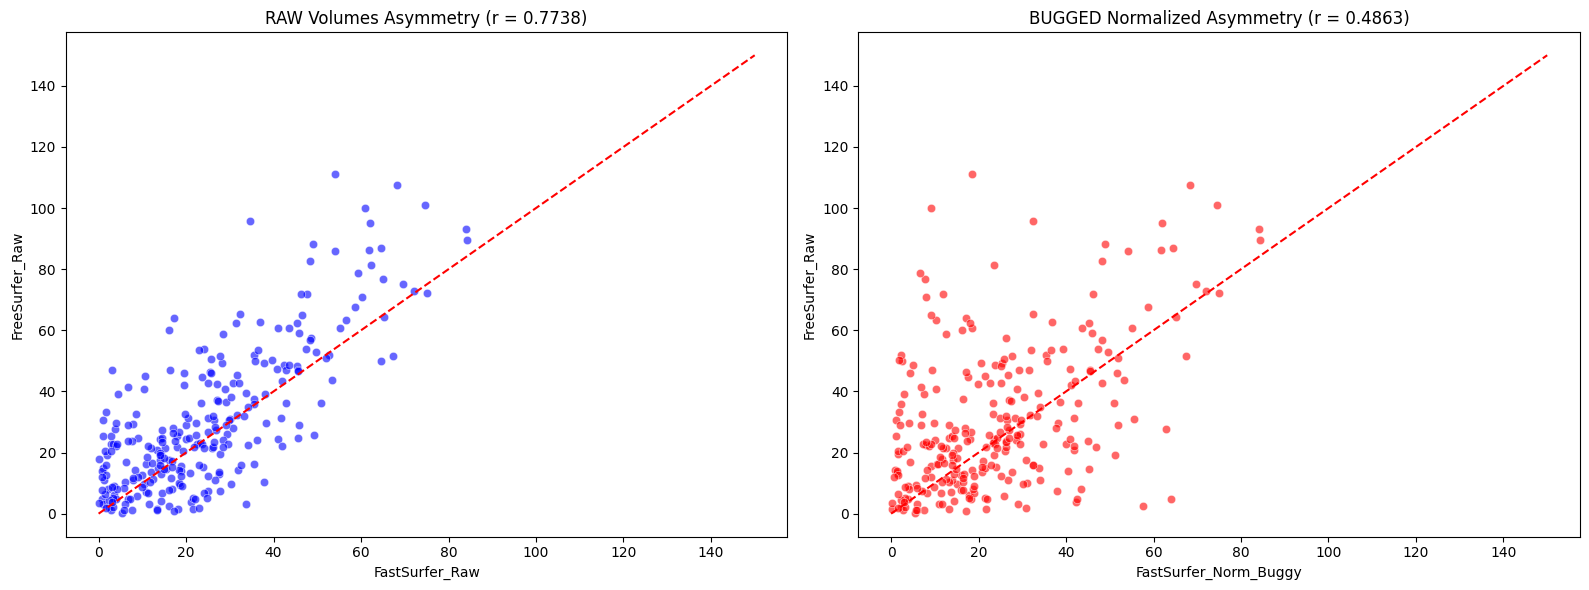

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Raw Asymmetry (from fs_shared and free_shared)
fs_asym_raw = (np.abs(fs_shared['Left-Inf-Lat-Vent'] - fs_shared['Right-Inf-Lat-Vent']) /
               ((fs_shared['Left-Inf-Lat-Vent'] + fs_shared['Right-Inf-Lat-Vent']) / 2)) * 100

free_asym_raw = (np.abs(free_shared['Left_Inf_Lat_Vent'] - free_shared['Right_Inf_Lat_Vent']) /
                 ((free_shared['Left_Inf_Lat_Vent'] + free_shared['Right_Inf_Lat_Vent']) / 2)) * 100

# 2. Reconstruct the "bugged" FastSurfer Normalized Asymmetry
# Note: This is bugged because the index on df_left_norm was not reset when row 182427 was dropped
bl_indices = fs_data[fs_data['EVENT_ID'] == 'BL'].index
fs_asym_norm_buggy = (np.abs(df_left_norm.loc[bl_indices, 'Inf-Lat-Vent'] -
                            df_right_norm.loc[bl_indices, 'Inf-Lat-Vent']) /
                     ((df_left_norm.loc[bl_indices, 'Inf-Lat-Vent'] +
                       df_right_norm.loc[bl_indices, 'Inf-Lat-Vent']) / 2)) * 100

# Align with PATNOs for comparison
fs_asym_norm_buggy.index = fs_data.loc[bl_indices, 'PATNO']

# 3. Create comparison dataframe
df_compare = pd.DataFrame({
    'FastSurfer_Raw': fs_asym_raw,
    'FastSurfer_Norm_Buggy': fs_asym_norm_buggy,
    'FreeSurfer_Raw': free_asym_raw
}).dropna()

print(f"Subjects in comparison: {len(df_compare)}")

# Plotting the paradox
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_compare, x='FastSurfer_Raw', y='FreeSurfer_Raw', ax=axes[0], color='blue', alpha=0.6)
axes[0].plot([0, 150], [0, 150], 'r--')
axes[0].set_title(f"RAW Volumes Asymmetry (r = {df_compare['FastSurfer_Raw'].corr(df_compare['FreeSurfer_Raw']):.4f})")

sns.scatterplot(data=df_compare, x='FastSurfer_Norm_Buggy', y='FreeSurfer_Raw', ax=axes[1], color='red', alpha=0.6)
axes[1].plot([0, 150], [0, 150], 'r--')
axes[1].set_title(f"BUGGED Normalized Asymmetry (r = {df_compare['FastSurfer_Norm_Buggy'].corr(df_compare['FreeSurfer_Raw']):.4f})")

plt.tight_layout()
plt.show()

Correlation between Fixed Norm and Raw: 1.000000


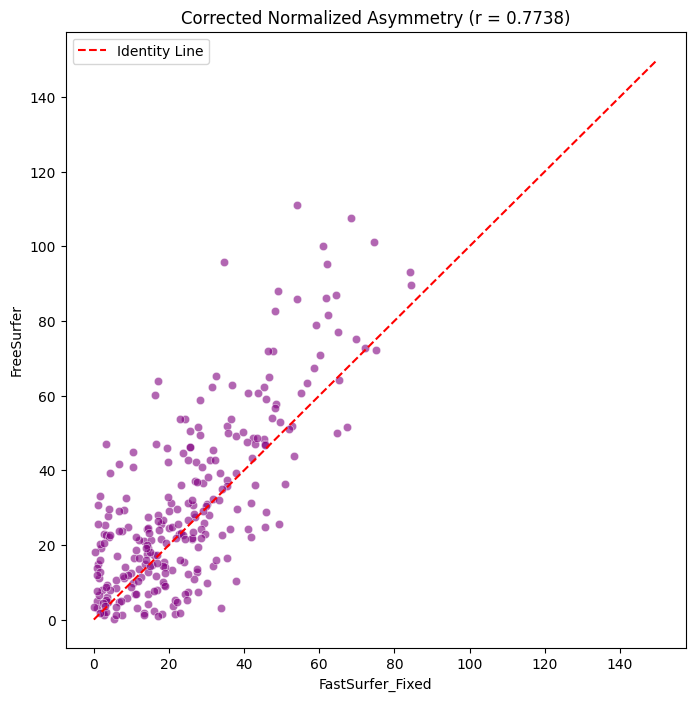

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-normalize properly using the updated dataframes (which now have aligned indices)
regions = [col for col in df_left_clean.columns if col not in base_cols]
df_left_norm = df_left_clean[regions].div(fs_data['MaskVol'], axis=0)
df_right_norm = df_right_clean[regions].div(fs_data['MaskVol'], axis=0)

# Calculate Fixed Asymmetry
bl_mask = fs_data['EVENT_ID'] == 'BL'
fs_asym_fixed = (np.abs(df_left_norm.loc[bl_mask, 'Inf-Lat-Vent'] -
                       df_right_norm.loc[bl_mask, 'Inf-Lat-Vent']) /
                ((df_left_norm.loc[bl_mask, 'Inf-Lat-Vent'] +
                  df_right_norm.loc[bl_mask, 'Inf-Lat-Vent']) / 2)) * 100

# Map back to PATNOs
fs_asym_fixed.index = fs_data.loc[bl_mask, 'PATNO']

# Sanity Check
print(f"Correlation between Fixed Norm and Raw: {fs_asym_fixed.corr(fs_asym_raw):.6f}")

# Comparison with FreeSurfer
df_plot = pd.DataFrame({
    'FastSurfer_Fixed': fs_asym_fixed,
    'FreeSurfer': free_asym_raw
}).dropna()

plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_plot, x='FastSurfer_Fixed', y='FreeSurfer', color='purple', alpha=0.6)
plt.plot([0, 150], [0, 150], 'r--', label='Identity Line')
plt.title(f"Corrected Normalized Asymmetry (r = {df_plot['FastSurfer_Fixed'].corr(df_plot['FreeSurfer']):.4f})")
plt.legend()
plt.show()

In [ ]:
print(df_pd_final.groupby('subgroup')['PATNO'].nunique())

subgroup
GBA             17
LRRK2           15
PRKN            13
SNCA             2
Sporadic PD    808
Name: PATNO, dtype: int64


# Linear Link Model with z-scored class indicator variables

In [ ]:
model_path = "/content/drive/MyDrive/data/m3_rmus_intercept_z_bl_trans_linear.rds"

ro.r(f'm3_rmus_intercept_z_bl_trans_linear <- readRDS("{model_path}")')

m3_rmus_intercept_z_bl_trans_linear = ro.globalenv['m3_rmus_intercept_z_bl_trans_linear']

In [ ]:
df_pd_final["trans_moca"] = np.sqrt(31 - df_pd_final["moca"])

In [ ]:
vars_to_z = ["rem", "trans_moca", "updrs3_score", "delta_sbp"]

base = df_pd_final[df_pd_final["YEAR"] == 0]

mu_base = base[vars_to_z].mean()
sd_base = base[vars_to_z].std()

df_pd_final[["z_bl_" + v for v in vars_to_z]] = (df_pd_final[vars_to_z] - mu_base) / sd_base

In [ ]:
df_pd_final.filter(like="z_bl_").describe()

,z_bl_rem,z_bl_trans_moca,z_bl_updrs3_score,z_bl_delta_sbp
count,3379.000000,3372.000000,2864.000000,3307.000000
mean,0.103496,0.055209,0.411544,0.057693
std,1.050013,1.141820,1.186819,1.073331
min,-1.390360,-1.688101,-2.077751,-4.249612
25%,-0.712310,-0.982341,-0.442863,-0.566941
50%,-0.034261,0.015755,0.272401,-0.018458
75%,0.982813,0.781621,1.192026,0.608380
max,3.016961,5.783589,4.666165,8.365496


In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

In [ ]:
ro.r('''
library(lcmm)
m3_rmus_intercept_z_bl_trans_linear_ref2 = permut(m3_rmus_intercept_z_bl_trans_linear, c(1, 3, 2))
postprob(m3_rmus_intercept_z_bl_trans_linear_ref2)
''')

 
Posterior classification: 
  class1 class2 class3
N 173.00 114.00 568.00
%  20.23  13.33  66.43
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2  prob3
class1 0.8684 0.0917 0.0400
class2 0.0894 0.7868 0.1238
class3 0.0080 0.0699 0.9221
 
Posterior probaBIlities above a threshold (%): 
         class1 class2 class3
prob>0.7  83.24  69.30  92.25
prob>0.8  75.72  54.39  85.92
prob>0.9  61.27  39.47  74.82
 


In [ ]:
import rpy2.robjects as ro

# 1. Define Predictors
ni_preds = ["SEX", "EDUCYRS", "age", "asyn_bl", "ptau_bl", "abeta_bl", "upsit_bl", "nfl_serum_bl", "MIA_CAUDATE_BILAT_bl", "MIA_PUTAMEN_BILAT_bl", "APOE_e4_bl"]
img_preds = ["SEX", "EDUCYRS", "age", "Thalamus_fs_bl", "Caudate_fs_bl", "Putamen_fs_bl", "Hippocampus_fs_bl", "choroid_plexus_fs_bl", "Pallidum_fs_bl", "Lateral_Ventricle_fs_bl", "Inf_Lat_Vent_fs_bl", "WM_hypointensities_fs_bl", "CerebralWhiteMatterVol_fs_bl"]

# 2. Prepare Shared Components
df_bl_bio = df_overlap.rename(columns={c: f'{c}_bl' for c in df_overlap.columns if c not in ['PATNO', 'EVENT_ID', 'YEAR']})[['PATNO'] + [f'{c}_bl' for c in biomarker_cols]].drop_duplicates('PATNO')
df_ext = df_pd_final.merge(df_bl_bio, on='PATNO', how='left')

# 2.1 Reconstruct MRI features (df_fs_combined)
fs_regions = ["Thalamus", "Caudate", "Putamen", "Hippocampus", "choroid_plexus", "Pallidum", "Lateral_Ventricle", "Inf_Lat_Vent"]
fs_globals = ["WM_hypointensities", "non_WM_hypointensities", "CerebralWhiteMatterVol", "SubCortGrayVol"]
df_fs_baseline = df_vol_both[["PATNO"] + fs_regions].copy()
df_globals = df_vol[["PATNO"] + fs_globals].copy()
df_fs_combined = df_fs_baseline.merge(df_globals, on="PATNO", how="left")
rename_dict = {col: f"{col}_fs_bl" for col in (fs_regions + fs_globals)}
df_fs_combined = df_fs_combined.rename(columns=rename_dict)

# 3. Non-Imaging Raw Dataframe (N=240)
df_ni_full_raw = df_ext.dropna(subset=ni_preds).copy()

# Apply targeted scaling to Non-Imaging predictors to stabilize the Hessian
df_ni_full_raw['asyn_bl'] = df_ni_full_raw['asyn_bl'] / 100.0
df_ni_full_raw['abeta_bl'] = df_ni_full_raw['abeta_bl'] / 100.0
df_ni_full_raw['MIA_CAUDATE_BILAT_bl'] = df_ni_full_raw['MIA_CAUDATE_BILAT_bl'] * 10.0
df_ni_full_raw['MIA_PUTAMEN_BILAT_bl'] = df_ni_full_raw['MIA_PUTAMEN_BILAT_bl'] * 10.0

# 4. Imaging Raw Dataframe (N=474)
mri_ids = set(df_pd_final['PATNO']) & set(df_vol['PATNO']) - {3403, 157589}
df_img_full_raw = df_pd_final[df_pd_final['PATNO'].isin(mri_ids)].merge(df_fs_combined, on='PATNO', how='left').dropna(subset=img_preds).copy()

# Targeted scaling for Imaging to balance SDs
df_img_full_raw['CerebralWhiteMatterVol_fs_bl'] *= 100.0
df_img_full_raw['WM_hypointensities_fs_bl'] *= 1000.0
df_img_full_raw['Lateral_Ventricle_fs_bl'] *= 1000.0

# Everything else by 10,000
other_fs_cols = [c for c in img_preds if '_fs_bl' in c and c not in ['CerebralWhiteMatterVol_fs_bl', 'WM_hypointensities_fs_bl', 'Lateral_Ventricle_fs_bl']]
df_img_full_raw[other_fs_cols] *= 10000.0

# 5. Push to R and Configure Factors
ro.globalenv['df_ni_full_raw'] = df_ni_full_raw
ro.globalenv['df_img_full_raw'] = df_img_full_raw
ro.r("""
library(lcmm)
setup_df <- function(d) {
  d$TP <- factor(d$YEAR)
  d$SEX <- factor(d$SEX)
  if('APOE_e4_bl' %in% names(d)) d$APOE_e4_bl <- factor(d$APOE_e4_bl)
  return(d)
}
df_ni_full_raw <- setup_df(df_ni_full_raw)
df_img_full_raw <- setup_df(df_img_full_raw)
""")

print(f"Data Prepared: Non-Imaging (N={df_ni_full_raw['PATNO'].nunique()}), Imaging (N={df_img_full_raw['PATNO'].nunique()})")

Data Prepared: Non-Imaging (N=240), Imaging (N=474)


In [ ]:
# 1. Consolidate APOE: 0 = non-carrier, 1 or 2 = carrier (mapped to 1)
df_ni_full_raw['APOE_e4_bl'] = df_ni_full_raw['APOE_e4_bl'].replace({2.0: 1.0})

# 2. Re-push the updated dataframe to R
ro.globalenv['df_ni_full_raw'] = df_ni_full_raw

# 3. Re-configure factors in R
ro.r("""
df_ni_full_raw$TP <- factor(df_ni_full_raw$YEAR)
df_ni_full_raw$SEX <- factor(df_ni_full_raw$SEX)
df_ni_full_raw$APOE_e4_bl <- factor(df_ni_full_raw$APOE_e4_bl)
""")

print("APOE consolidated in df_ni_full_raw (0 = Non-Carrier, 1 = Carrier):")
print(df_ni_full_raw['APOE_e4_bl'].value_counts().sort_index())

APOE consolidated in df_ni_full_raw (0 = Non-Carrier, 1 = Carrier):
APOE_e4_bl
0.0    982
1.0    318
Name: count, dtype: int64


In [ ]:
cols_to_add = ["PATNO", "EVENT_ID"] + ["z_bl_" + v for v in vars_to_z]
z_cols = ["z_bl_" + v for v in vars_to_z]

# Drop columns if they already exist to avoid MergeError on re-run
df_img_full_raw = df_img_full_raw.drop(columns=[c for c in z_cols if c in df_img_full_raw.columns])
df_ni_full_raw = df_ni_full_raw.drop(columns=[c for c in z_cols if c in df_ni_full_raw.columns])
df_upsit_full = df_upsit_full.drop(columns=[c for c in z_cols if c in df_upsit_full.columns])
df_dat_final = df_dat_final.drop(columns=[c for c in z_cols if c in df_dat_final.columns])

# Add to dataframes
df_img_full_raw = df_img_full_raw.merge(df_pd_final[cols_to_add], on=["PATNO", "EVENT_ID"], how="left")
df_ni_full_raw = df_ni_full_raw.merge(df_pd_final[cols_to_add], on=["PATNO", "EVENT_ID"], how="left")
df_upsit_full = df_upsit_full.merge(df_pd_final[cols_to_add], on=["PATNO", "EVENT_ID"], how="left")
df_dat_final = df_dat_final.merge(df_pd_final[cols_to_add], on=["PATNO", "EVENT_ID"], how="left")

# Push all back to R
ro.globalenv['df_img_full_raw'] = df_img_full_raw
ro.globalenv['df_ni_full_raw'] = df_ni_full_raw
ro.globalenv['df_upsit_full'] = df_upsit_full
ro.globalenv['df_dat_final'] = df_dat_final

ro.r("""
setup_df_z <- function(d) {
  d$TP <- factor(d$YEAR)
  d$SEX <- factor(d$SEX)
  if('APOE_e4_bl' %in% names(d)) d$APOE_e4_bl <- factor(d$APOE_e4_bl)
  return(d)
}
df_img_full_raw <- setup_df_z(df_img_full_raw)
df_ni_full_raw <- setup_df_z(df_ni_full_raw)
df_upsit_full <- setup_df_z(df_upsit_full)
df_dat_final <- setup_df_z(df_dat_final)
""")

print(f"Successfully added/updated z-scored baseline variables in all cohorts.")

Successfully added/updated z-scored baseline variables in all cohorts.


In [ ]:
formula_img = " ~ " + " + ".join(img_preds)

print(f"--- Running Imaging externVar (Z-scored BL Linear Model, N={df_img_full_raw['PATNO'].nunique()}) ---")

ro.r(f"""
m3_img_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                         classmb = {formula_img},
                         subject = 'PATNO',
                         data = df_img_full_raw,
                         method = 'twoStageJoint',
                         maxiter = 100)

print(summary(m3_img_z_bl))
""")

--- Running Imaging externVar (Z-scored BL Linear Model, N=474) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + Thalamus_fs_bl + Caudate_fs_bl + 
        Putamen_fs_bl + Hippocampus_fs_bl + choroid_plexus_fs_bl + 
        Pallidum_fs_bl + Lateral_Ventricle_fs_bl + Inf_Lat_Vent_fs_bl + 
        WM_hypointensities_fs_bl + CerebralWhiteMatterVol_fs_bl, 
    data = df_img_full_raw, method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_img_full_raw 
     Number of subjects: 474 
     Number of latent classes: 3 
     Number of parameters: 28  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  29 
     Convergence criteria: parameters= 2.1e-06 
                         : l

In [ ]:
formula_ni = " ~ " + " + ".join(ni_preds)

print(f"--- Running Non-Imaging externVar (Z-scored BL Linear Model, N={df_ni_full_raw['PATNO'].nunique()}) ---")
ro.r(f"""
m3_ni_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                       classmb = {formula_ni},
                       subject = 'PATNO',
                       data = df_ni_full_raw,
                       method = 'twoStageJoint',
                       maxiter = 100)

print(summary(m3_ni_z_bl))
""")

--- Running Non-Imaging externVar (Z-scored BL Linear Model, N=474) ---


Exception ignored from cffi callback <function _processevents at 0x7f240e1c9620>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/rpy2/rinterface_lib/callbacks.py", line 283, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 


Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + asyn_bl + ptau_bl + abeta_bl + 
        upsit_bl + nfl_serum_bl + MIA_CAUDATE_BILAT_bl + MIA_PUTAMEN_BILAT_bl + 
        APOE_e4_bl, data = df_ni_full_raw, method = "twoStageJoint", 
    maxiter = 100)
 
Statistical Model: 
     Dataset: df_ni_full_raw 
     Number of subjects: 240 
     Number of latent classes: 3 
     Number of parameters: 24  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  20 
     Convergence criteria: parameters= 4.2e-08 
                         : likelihood= 4.1e-07 
                         : second derivatives= 5.5e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -7039.43  
     AIC: 14126.87  
     BIC:

In [ ]:
upsit_preds = ["SEX", "EDUCYRS", "age", "upsit_bl"]
formula_upsit = " ~ " + " + ".join(upsit_preds)

print(f"--- Running UPSIT externVar (Z-scored BL Linear Model, N={df_upsit_full['PATNO'].nunique()}) ---")

ro.r(f"""

# Run the secondary regression using the permuted z-scored linear model
m3_upsit_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                          classmb = {formula_upsit},
                          subject = 'PATNO',
                          data = df_upsit_full,
                          method = 'twoStageJoint',
                          maxiter = 100)

print(summary(m3_upsit_z_bl))
""")

--- Running UPSIT externVar (Z-scored BL Linear Model, N=834) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + upsit_bl, data = df_upsit_full, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_upsit_full 
     Number of subjects: 834 
     Number of latent classes: 3 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  9 
     Convergence criteria: parameters= 7.7e-05 
                         : likelihood= 2.3e-05 
                         : second derivatives= 1.2e-08 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -17876.73  
     AIC: 35773.45  
     BIC: 35820.72  
 
 
 
Maximum Likelihood Estimates: 
 
Fixed ef

In [ ]:
formula_dat = " ~ SEX + EDUCYRS + age + MIA_CAUDATE_bl + MIA_PUTAMEN_bl"

print(f"--- Running DATscan externVar (Z-scored BL Linear Model, N={df_dat_final['PATNO'].nunique()}) ---")

ro.r(f"""
m3_dat_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                         classmb = {formula_dat},
                         subject = 'PATNO',
                         data = df_dat_final,
                         method = 'twoStageJoint',
                         maxiter = 100)

print(summary(m3_dat_z_bl))
""")

--- Running DATscan externVar (Z-scored BL Linear Model, N=846) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + MIA_CAUDATE_bl + MIA_PUTAMEN_bl, 
    data = df_dat_final, method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_dat_final 
     Number of subjects: 846 
     Number of latent classes: 3 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  24 
     Convergence criteria: parameters= 1.2e-08 
                         : likelihood= 6.4e-06 
                         : second derivatives= 1.7e-05 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18050.48  
     AIC: 36124.97  
     BIC: 36181.85  
 
 
 
Maximum Likelihoo

In [ ]:
# 1. Identify PATNOs with available asyn at baseline
asyn_patnos = df_biomarkers[(df_biomarkers['YEAR'] == 0) & (df_biomarkers['asyn'].notna())]['PATNO'].unique()

# 2. Filter the longitudinal PD cohort for these subjects
df_asyn_full = df_pd_final[df_pd_final['PATNO'].isin(asyn_patnos)].copy()

# 3. Merge baseline asyn values back in for use as a predictor
df_asyn_bl_values = df_biomarkers[df_biomarkers['YEAR'] == 0][['PATNO', 'asyn']].rename(columns={'asyn': 'asyn_bl'})
df_asyn_full = df_asyn_full.merge(df_asyn_bl_values, on='PATNO', how='left')

# 4. Filter for records where asyn_bl is available and add basic demo predictors
# (Mirroring the logic of your other dedicated dataframes)
demo_cols = ['SEX', 'EDUCYRS', 'age']
df_asyn_full = df_asyn_full.dropna(subset=['asyn_bl'] + demo_cols).copy()

# 5. Push to R environment
ro.globalenv['df_asyn_full'] = df_asyn_full
ro.r("""
library(lcmm)
df_asyn_full$TP <- factor(df_asyn_full$YEAR)
df_asyn_full$SEX <- factor(df_asyn_full$SEX)
""")

print(f"Created 'df_asyn_full' with {df_asyn_full['PATNO'].nunique()} subjects and {len(df_asyn_full)} total rows.")
display(df_asyn_full[['PATNO', 'YEAR', 'asyn_bl']].head())

Created 'df_asyn_full' with 305 subjects and 1647 total rows.


,PATNO,YEAR,asyn_bl
0,3001,0,1154.4
1,3001,1,1154.4
2,3001,2,1154.4
3,3001,3,1154.4
4,3001,4,1154.4


In [ ]:
asyn_preds = ["SEX", "EDUCYRS", "age", "asyn_bl"]
formula_asyn = " ~ " + " + ".join(asyn_preds)

print(f"--- Running asyn externVar (Z-scored BL Linear Model, N={df_asyn_full['PATNO'].nunique()}) ---")

ro.r(f"""

df_asyn_full$SEX <- factor(df_asyn_full$SEX)

m3_asyn_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                             classmb = {formula_asyn},
                             subject = 'PATNO',
                             data = df_asyn_full,
                             method = 'twoStageJoint',
                             maxiter = 100)

print(summary(m3_asyn_z_bl))
""")

--- Running asyn externVar (Z-scored BL Linear Model, N=305) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + asyn_bl, data = df_asyn_full, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_asyn_full 
     Number of subjects: 305 
     Number of latent classes: 3 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  8 
     Convergence criteria: parameters= 4.8e-05 
                         : likelihood= 7.2e-06 
                         : second derivatives= 3.8e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -8930.42  
     AIC: 17880.84  
     BIC: 17918.04  
 
 
 
Maximum Likelihood Estimates: 
 
Fixed effects

## Saving Results to CSV, for MyST Markdown

In [ ]:
import pandas as pd
import numpy as np

upsit_text = """
intercept class1 -1.28493 1.20029 -1.071 0.28439
intercept class2  0.26131 1.53393  0.170 0.86473
SEX1 class1       1.18803 0.27851  4.266 0.00002
SEX1 class2       0.37479 0.30201  1.241 0.21461
EDUCYRS class1   -0.03071 0.03617 -0.849 0.39580
EDUCYRS class2   -0.01975 0.04595 -0.430 0.66739
age class1        0.00774 0.01464  0.529 0.59687
age class2       -0.00576 0.01929 -0.299 0.76529
upsit_bl class1  -0.03774 0.01357 -2.780 0.00543
upsit_bl class2  -0.05381 0.01710 -3.147 0.00165
"""

ni_text = """
intercept class1             5.63644 3.13430  1.798 0.07213
intercept class2             3.71546 2.87852  1.291 0.19679
SEX1 class1                  0.83399 0.63568  1.312 0.18953
SEX1 class2                 -0.01251 0.32715 -0.038 0.96950
EDUCYRS class1              -0.04481 0.08005 -0.560 0.57563
EDUCYRS class2              -0.00568 0.06664 -0.085 0.93209
age class1                  -0.06047 0.04442 -1.361 0.17339
age class2                  -0.01737 0.04001 -0.434 0.66411
asyn_bl class1              -0.14893 0.09842 -1.513 0.13021
asyn_bl class2              -0.04598 0.06665 -0.690 0.49026
ptau_bl class1               0.11072 0.08694  1.274 0.20281
ptau_bl class2               0.06018 0.06373  0.944 0.34499
abeta_bl class1             -0.05334 0.11083 -0.481 0.63036
abeta_bl class2             -0.10680 0.09253 -1.154 0.24840
upsit_bl class1             -0.03431 0.02874 -1.194 0.23263
upsit_bl class2             -0.04657 0.02626 -1.773 0.07623
nfl_serum_bl class1          0.04224 0.03053  1.383 0.16654
nfl_serum_bl class2         -0.02214 0.03795 -0.583 0.55964
MIA_CAUDATE_BILAT_bl class1 -0.09802 0.12298 -0.797 0.42543
MIA_CAUDATE_BILAT_bl class2  0.00857 0.11559  0.074 0.94088
MIA_PUTAMEN_BILAT_bl class1 -0.18148 0.14855 -1.222 0.22180
MIA_PUTAMEN_BILAT_bl class2 -0.23260 0.13797 -1.686 0.09182
APOE_e4_bl1 class1          -0.09343 0.59304 -0.158 0.87481
APOE_e4_bl1 class2          -0.29605 0.52808 -0.561 0.57506
"""

img_text = """
intercept class1                    -3.35959 3.82285 -0.879 0.37950
intercept class2                     0.01575 0.38823  0.041 0.96763
SEX1 class1                          1.34003 0.43255  3.098 0.00195
SEX1 class2                          0.48636 0.35641  1.365 0.17237
EDUCYRS class1                      -0.01991 0.05538 -0.360 0.71917
EDUCYRS class2                       0.00868 0.05544  0.157 0.87555
age class1                           0.00668 0.02684  0.249 0.80335
age class2                           0.00689 0.02210  0.312 0.75508
Thalamus_fs_bl class1               -0.11751 0.05062 -2.321 0.02027
Thalamus_fs_bl class2               -0.00328 0.05632 -0.058 0.95354
Caudate_fs_bl class1                 0.12979 0.06831  1.900 0.05745
Caudate_fs_bl class2                -0.08348 0.06894 -1.211 0.22592
Putamen_fs_bl class1                -0.17798 0.06219 -2.862 0.00421
Putamen_fs_bl class2                -0.04666 0.05785 -0.806 0.41998
Hippocampus_fs_bl class1             0.15509 0.07492  2.070 0.03844
Hippocampus_fs_bl class2            -0.03377 0.07522 -0.449 0.65349
choroid_plexus_fs_bl class1         -0.22476 0.13863 -1.621 0.10496
choroid_plexus_fs_bl class2          0.02551 0.13786  0.185 0.85320
Pallidum_fs_bl class1                0.14053 0.12757  1.102 0.27063
Pallidum_fs_bl class2                0.33462 0.13427  2.492 0.01270
Lateral_Ventricle_fs_bl class1       0.01115 0.05367  0.208 0.83542
Lateral_Ventricle_fs_bl class2      -0.05339 0.05646 -0.946 0.34435
Inf_Lat_Vent_fs_bl class1            0.11718 0.08630  1.358 0.17451
Inf_Lat_Vent_fs_bl class2            0.03038 0.09555  0.318 0.75056
WM_hypointensities_fs_bl class1     -0.07847 0.05868 -1.337 0.18112
WM_hypointensities_fs_bl class2      0.01853 0.04029  0.460 0.64567
CerebralWhiteMatterVol_fs_bl class1  0.09860 0.06365  1.549 0.12135
CerebralWhiteMatterVol_fs_bl class2 -0.06459 0.05943 -1.087 0.27713
"""

def get_scale_factor(pred_name):
    if 'asyn_bl' in pred_name: return 0.01
    if 'abeta_bl' in pred_name: return 0.01
    if 'MIA_CAUDATE_BILAT_bl' in pred_name: return 10.0
    if 'MIA_PUTAMEN_BILAT_bl' in pred_name: return 10.0
    # MRI volumes: OR per 0.1% change in brain volume (0.001 units)
    if 'CerebralWhiteMatterVol_fs_bl' in pred_name: return 0.001 * 100.0
    if 'WM_hypointensities_fs_bl' in pred_name: return 0.001 * 1000.0
    if 'Lateral_Ventricle_fs_bl' in pred_name: return 0.001 * 1000.0
    if '_fs_bl' in pred_name: return 0.001 * 10000.0
    return 1.0

def safe_exp(x):
    return np.exp(np.clip(x, -500, 500))

def parse_lcmm_text(text, n, include_demographics=True, sensitivity_label=False):
    data = {}
    for line in text.strip().split('\n'):
        if not line.strip(): continue
        parts = line.split()
        pred = parts[0]
        if 'intercept' in pred.lower(): continue
        if not include_demographics and any(k in pred for k in ['SEX', 'EDUCYRS', 'age']): continue
        cls = parts[1]
        coef = float(parts[2])
        pval = float(parts[5])
        if pred not in data: data[pred] = {}
        data[pred][cls] = {'coef': coef, 'pval': pval}
    rows = []
    for pred_name, vals in data.items():
        if 'class1' in vals and 'class2' in vals:
            scale_factor = get_scale_factor(pred_name)
            unscaled_coef_c1 = vals['class1']['coef'] * scale_factor
            unscaled_coef_c2 = vals['class2']['coef'] * scale_factor
            clean_pred = pred_name.replace('_fs_bl', '').replace('_bl', '')
            if 'SEX' in clean_pred: clean_pred = 'Sex (Male=1)'
            elif 'APOE' in clean_pred: clean_pred = 'APOE_e4 (Carrier=1)'
            if sensitivity_label and 'upsit' in clean_pred.lower():
                clean_pred = f"{clean_pred} (sensitivity analysis)"
            rows.append({
                'Predictor': clean_pred,
                'N': n,
                'Odds Ratio (Class 1)': safe_exp(unscaled_coef_c1),
                'p-value (Class 1)': vals['class1']['pval'],
                'Odds Ratio (Class 3)': safe_exp(unscaled_coef_c2),
                'p-value (Class 3)': vals['class2']['pval']
            })
    return rows

rows_all = []
rows_all.extend(parse_lcmm_text(upsit_text, 834, include_demographics=True))
rows_all.extend(parse_lcmm_text(img_text, 474, include_demographics=False))
rows_all.extend(parse_lcmm_text(ni_text, 240, include_demographics=False, sensitivity_label=True))

df_results = pd.DataFrame(rows_all)
df_results = df_results[['Predictor', 'N', 'Odds Ratio (Class 1)', 'p-value (Class 1)', 'Odds Ratio (Class 3)', 'p-value (Class 3)']]

output_csv = "/content/m3_models_summary.csv"
df_results.to_csv(output_csv, index=False)
print(f"Data successfully exported to {output_csv}")
display(df_results.style.set_properties(subset=['Predictor'], **{'text-align': 'left'}))

Data successfully exported to /content/m3_models_summary.csv


,Predictor,N,Odds Ratio (Class 1),p-value (Class 1),Odds Ratio (Class 3),p-value (Class 3)
0,Sex (Male=1),834,3.280612,0.000020,1.454686,0.214610
1,EDUCYRS,834,0.969757,0.395800,0.980444,0.667390
2,age,834,1.007770,0.596870,0.994257,0.765290
3,upsit,834,0.962963,0.005430,0.947612,0.001650
4,Thalamus,474,0.308788,0.020270,0.967732,0.953540
5,Caudate,474,3.661599,0.057450,0.433961,0.225920
6,Putamen,474,0.168672,0.004210,0.627131,0.419980
7,Hippocampus,474,4.715712,0.038440,0.713409,0.653490
8,choroid_plexus,474,0.105652,0.104960,1.290591,0.853200
9,Pallidum,474,4.076750,0.270630,28.394629,0.012700


In [ ]:
import rpy2.robjects as ro
import pandas as pd

# 1. Define the imaging predictors used in the models
imaging_preds_full = [
    'SEX', 'EDUCYRS', 'age', 'Thalamus_fs_bl', 'Caudate_fs_bl', 'Putamen_fs_bl',
    'Hippocampus_fs_bl', 'choroid_plexus_fs_bl', 'Pallidum_fs_bl',
    'Lateral_Ventricle_fs_bl', 'Inf_Lat_Vent_fs_bl', 'WM_hypointensities_fs_bl',
    'CerebralWhiteMatterVol_fs_bl'
]

# 2. Identify the valid cohort IDs (excluding the 2 MRIQC outliers)
mriqc_outliers = [3403, 157589]
fs_vol_patnos = df_vol['PATNO'].unique()
pd_ids_with_mri = set(df_pd_final['PATNO'].unique()).intersection(set(fs_vol_patnos))
pd_ids_with_mri = [pid for pid in pd_ids_with_mri if pid not in mriqc_outliers]

# 3. Rebuild the dataframe from source
# We use df_pd_final for longitudinal clinical data and merge with df_fs_combined for MRI
df_img_full_raw = df_pd_final[df_pd_final['PATNO'].isin(pd_ids_with_mri)].copy()
df_img_full_raw = df_img_full_raw.merge(df_fs_combined, on='PATNO', how='left')

# 4. Clean and ensure raw proportions (no 100x or 10,000x scaling)
df_img_full_raw = df_img_full_raw.dropna(subset=imaging_preds_full).copy()

# 5. Push to R environment and configure
ro.globalenv['df_img_full_raw'] = df_img_full_raw
ro.r("""
library(lcmm)
df_img_full_raw$TP <- factor(df_img_full_raw$YEAR)
df_img_full_raw$SEX <- factor(df_img_full_raw$SEX)
""")

# 6. Verify Standard Deviations
fs_cols = [c for c in df_img_full_raw.columns if c.endswith('_fs_bl')]
print(f"Recreated df_img_full_raw with {df_img_full_raw['PATNO'].nunique()} subjects.")
print("\n--- Verification of Raw Proportions (SDs) ---")
display(df_img_full_raw[fs_cols].std().sort_values())

Recreated df_img_full_raw with 474 subjects.

--- Verification of Raw Proportions (SDs) ---


,0
non_WM_hypointensities_fs_bl,2.270790e-07
choroid_plexus_fs_bl,1.454628e-04
Pallidum_fs_bl,1.495685e-04
Inf_Lat_Vent_fs_bl,2.290374e-04
Caudate_fs_bl,2.984836e-04
Hippocampus_fs_bl,3.207726e-04
Putamen_fs_bl,3.674497e-04
Thalamus_fs_bl,5.039180e-04
SubCortGrayVol_fs_bl,3.168382e-03
Lateral_Ventricle_fs_bl,4.341165e-03


In [ ]:
import pandas as pd
import numpy as np

# 1. Extract raw SDs for the 13 imaging predictors from the N=474 cohort
fs_cols = [c for c in df_img_full_raw.columns if c.endswith('_fs_bl')]
raw_sds = df_img_full_raw[fs_cols + ['EDUCYRS', 'age']].std()

# 2. Re-import the unstandardized summary table
df_final_or = pd.read_csv('/content/m3_models_summary.csv')

# 3. Define the conversion function
def standardize_or(row, class_col):
    pred = row['Predictor']
    raw_or = row[class_col]
    matched_sd_name = next((c for c in raw_sds.index if pred in c), None)
    if matched_sd_name and '_fs_bl' in matched_sd_name:
        sd = raw_sds[matched_sd_name]
        std_or = np.exp((np.log(raw_or) / 0.001) * sd)
        return std_or
    return raw_or

# 4. Create the standardized table
df_std = df_final_or.copy()
df_std['Odds Ratio (Class 1)'] = df_std.apply(lambda x: standardize_or(x, 'Odds Ratio (Class 1)'), axis=1)
df_std['Odds Ratio (Class 3)'] = df_std.apply(lambda x: standardize_or(x, 'Odds Ratio (Class 3)'), axis=1)

# 5. Export and Display with fixed alignment
output_std = '/content/m3_models_standardized_final.csv'
df_std.to_csv(output_std, index=False)

print(f'Standardized table (OR per 1-SD) exported to {output_std}')
display(df_std.style.set_properties(subset=['Predictor'], **{'text-align': 'right'}).set_caption('Standardized Odds Ratios (per 1-SD for Imaging)'))

Standardized table (OR per 1-SD) exported to /content/m3_models_standardized_final.csv


,Predictor,N,Odds Ratio (Class 1),p-value (Class 1),Odds Ratio (Class 3),p-value (Class 3)
0,Sex (Male=1),834,3.280612,0.000020,1.454686,0.214610
1,EDUCYRS,834,0.969757,0.395800,0.980444,0.667390
2,age,834,1.007770,0.596870,0.994257,0.765290
3,upsit,834,0.962963,0.005430,0.947612,0.001650
4,Thalamus,474,0.553135,0.020270,0.983607,0.953540
5,Caudate,474,1.473148,0.057450,0.779444,0.225920
6,Putamen,474,0.519969,0.004210,0.842441,0.419980
7,Hippocampus,474,1.644582,0.038440,0.897336,0.653490
8,choroid_plexus,474,0.721125,0.104960,1.037805,0.853200
9,Pallidum,474,1.233911,0.270630,1.649523,0.012700


In [ ]:
import pandas as pd
import numpy as np
import csv

# 1. Load the standardized results
df = pd.read_csv('/content/m3_models_standardized_final.csv')

# 2. Rename predictors for a professional look (using LaTeX for MyST)
# Includes clinical biomarkers and full spelling of MRI regions
rename_map = {
    'asyn': r'CSF $\alpha$-synuclein',
    'ptau': r'CSF phosphorylated-$\tau$',
    'abeta': r'CSF amyloid-$\beta$',
    'MIA_CAUDATE_BILAT': 'Striatal SBR Caudate',
    'MIA_PUTAMEN_BILAT': 'Striatal SBR Putamen',
    'APOE_e4 (Carrier=1)': r'APOE $\epsilon$4 (Carrier=1)',
    'upsit': 'UPSIT',
    'nfl_serum': 'Serum NfL Chain',
    'choroid_plexus': 'Choroid Plexus',
    'Lateral_Ventricle': 'Lateral Ventricle',
    'Inf_Lat_Vent': 'Inf. Lat. Ventricle',
    'WM_hypointensities': 'WM Hypointensities',
    'CerebralWhiteMatterVol': 'Cerebral White Matter',
    'upsit (sensitivity analysis)': 'UPSIT (sensitivity analysis)',
    'EDUCYRS': 'Education (Years)',
    'age': 'Age'
}
df['Predictor'] = df['Predictor'].replace(rename_map)

# 3. Helper functions for conditional formatting
def format_p_value(val):
    p_float = float(val)
    if p_float < 0.001:
        formatted = '<.001'
    else:
        formatted = '{:.3f}'.format(p_float)
    # Bold if significant
    return f"**{formatted}**" if p_float < 0.05 else formatted

def format_or(row, class_num):
    or_val = row[f'Odds Ratio (Class {class_num})']
    p_val = float(row[f'p-value (Class {class_num})'])
    formatted_or = '{:.2f}'.format(or_val)
    # Bold OR if its corresponding p-value is significant
    return f"**{formatted_or}**" if p_val < 0.05 else formatted_or

# 4. Apply formatting to Classes 1 and 3
for cls in [1, 3]:
    p_col = f'p-value (Class {cls})'
    or_col = f'Odds Ratio (Class {cls})'

    # Order matters: check p-values to format ORs first, then format p-values
    df[or_col] = df.apply(lambda x: format_or(x, cls), axis=1)
    df[p_col] = df[p_col].apply(format_p_value)

# 5. Rename Headings to include <br> before brackets
df = df.rename(columns={
    'Odds Ratio (Class 1)': 'Odds Ratio<br>(Class 1)',
    'p-value (Class 1)': 'p-value<br>(Class 1)',
    'Odds Ratio (Class 3)': 'Odds Ratio<br>(Class 3)',
    'p-value (Class 3)': 'p-value<br>(Class 3)'
})

# 6. Final Polish and Export
df['N'] = df['N'].astype(int)

output_myst = '/content/m3_results_myst_formatted.csv'
df.to_csv(output_myst, index=False, quoting=csv.QUOTE_ALL)

print(f"Tailored CSV with bolded ORs and P-values saved to: {output_myst}")
display(df.style.set_properties(subset=['Predictor'], **{'text-align': 'left'}))

Tailored CSV with bolded ORs and P-values saved to: /content/m3_results_myst_formatted.csv


,Predictor,N,Odds Ratio(Class 1),p-value(Class 1),Odds Ratio(Class 3),p-value(Class 3)
0,Sex (Male=1),834,**3.28**,**<.001**,1.45,0.215
1,Education (Years),834,0.97,0.396,0.98,0.667
2,Age,834,1.01,0.597,0.99,0.765
3,UPSIT,834,**0.96**,**0.005**,**0.95**,**0.002**
4,Thalamus,474,**0.55**,**0.020**,0.98,0.954
5,Caudate,474,1.47,0.057,0.78,0.226
6,Putamen,474,**0.52**,**0.004**,0.84,0.420
7,Hippocampus,474,**1.64**,**0.038**,0.90,0.653
8,Choroid Plexus,474,0.72,0.105,1.04,0.853
9,Pallidum,474,1.23,0.271,**1.65**,**0.013**


# Linear Mixed Model for MRI Trajectories

## Plots

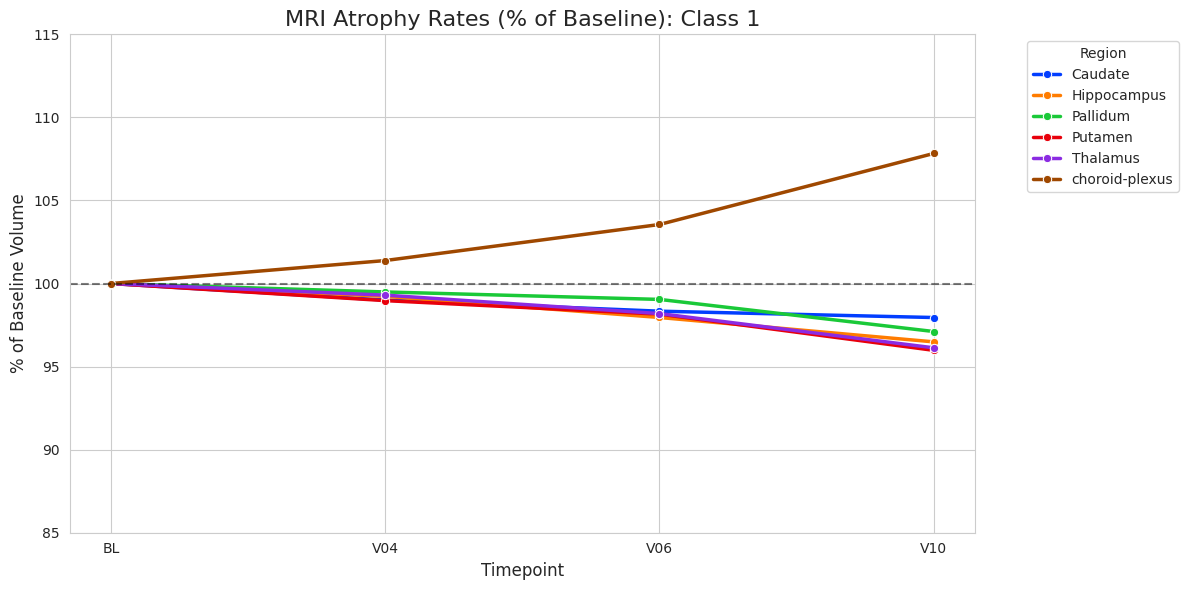

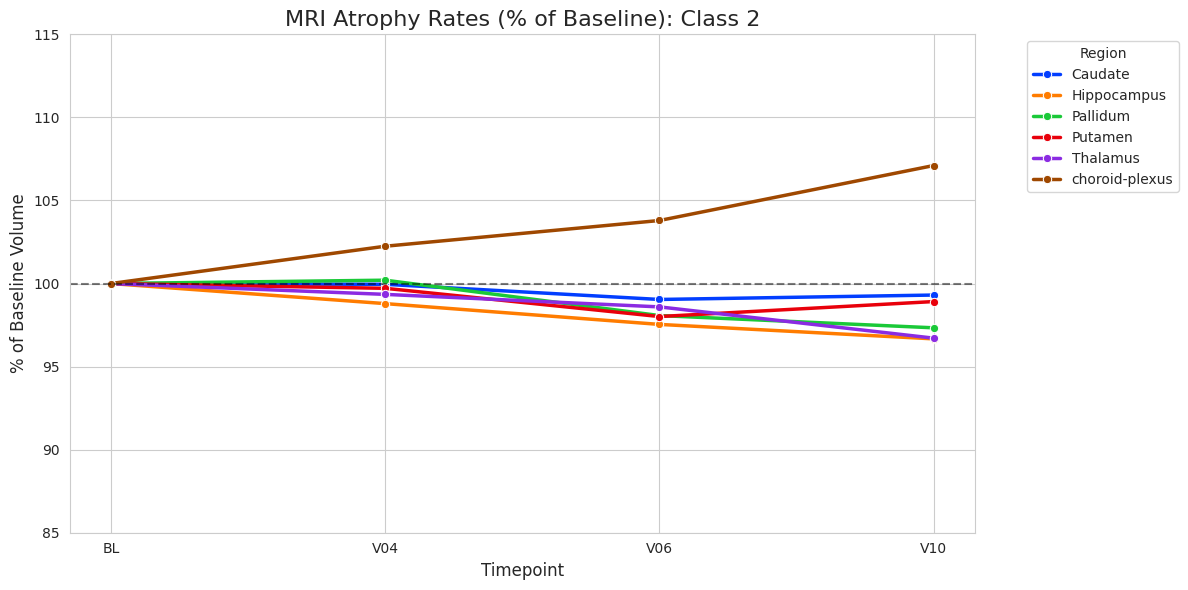

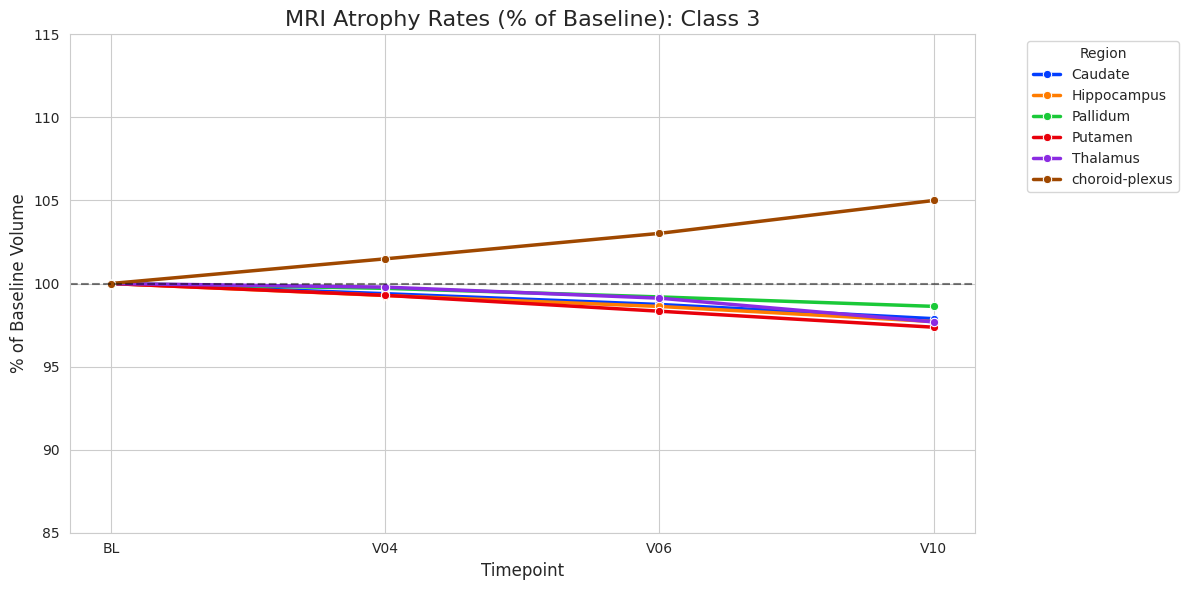

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load class assignments from the 3-class linear model (already in memory as pprob_df)
pp_m3 = pprob_df[['PATNO', 'class']].copy()
pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)

# 1.5 Create df_averaged for FastSurfer regions
target_regions = ['Thalamus', 'Caudate', 'Pallidum', 'Putamen', 'Hippocampus', 'choroid-plexus']
df_averaged = fs_data[['PATNO', 'EVENT_ID']].copy()
for r in target_regions:
    df_averaged[r] = (fs_data[f'Left-{r}'] + fs_data[f'Right-{r}']) / 2

# 2. Merge with averaged regional data
df_mri = df_averaged.merge(pp_m3, on='PATNO', how='inner')

# 3. Filter visits
timepoint_map = {'BL': 0, 'V04': 1, 'V06': 2, 'V10': 3}
df_mri = df_mri[df_mri['EVENT_ID'].isin(timepoint_map.keys())].copy()
df_mri['Visit_Order'] = df_mri['EVENT_ID'].map(timepoint_map)

# 4. Calculate % of Baseline Volume per subject
def calculate_pct_baseline(group):
    # Sort by visit order to ensure BL is identified correctly
    group = group.sort_values('Visit_Order')
    bl_row = group[group['EVENT_ID'] == 'BL']

    if not bl_row.empty:
        for region in target_regions:
            bl_vol = bl_row[region].values[0]
            if bl_vol > 0:
                group[f'{region}_pct'] = (group[region] / bl_vol) * 100
            else:
                group[f'{region}_pct'] = np.nan
    else:
        for region in target_regions:
            group[f'{region}_pct'] = np.nan
    return group

df_pct = df_mri.groupby('PATNO', group_keys=False).apply(calculate_pct_baseline, include_groups=False)

# 5. Reshape for plotting
pct_vars = [f'{r}_pct' for r in target_regions]
df_long = df_pct.melt(id_vars=['class', 'Visit_Order', 'EVENT_ID'],
                           value_vars=pct_vars,
                           var_name='Region', value_name='Pct_Baseline')

# Clean region names for legend
df_long['Region'] = df_long['Region'].str.replace('_pct', '')

# 6. Calculate Class Averages
df_grouped = df_long.groupby(['class', 'Visit_Order', 'EVENT_ID', 'Region'])['Pct_Baseline'].mean().reset_index()

# 7. Plotting
sns.set_style("whitegrid")
classes = sorted(df_grouped['class'].unique())

for cls in classes:
    plt.figure(figsize=(12, 6))
    data_cls = df_grouped[df_grouped['class'] == cls]

    sns.lineplot(data=data_cls, x='Visit_Order', y='Pct_Baseline', hue='Region',
                 marker='o', palette='bright', linewidth=2.5)

    plt.title(f"MRI Atrophy Rates (% of Baseline): Class {int(cls)}", fontsize=16)
    plt.xticks(range(4), ['BL', 'V04', 'V06', 'V10'])
    plt.xlabel("Timepoint", fontsize=12)
    plt.ylabel("% of Baseline Volume", fontsize=12)
    plt.ylim(85, 115) # Centered around 100% to see gain/loss clearly
    plt.axhline(100, ls='--', color='black', alpha=0.5)
    plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


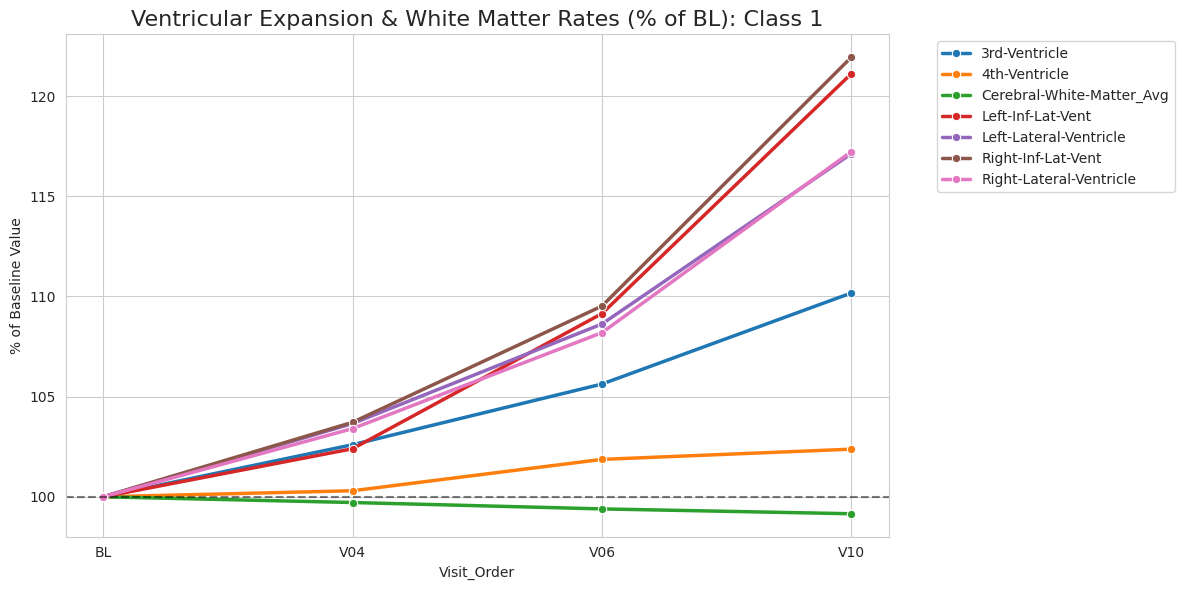

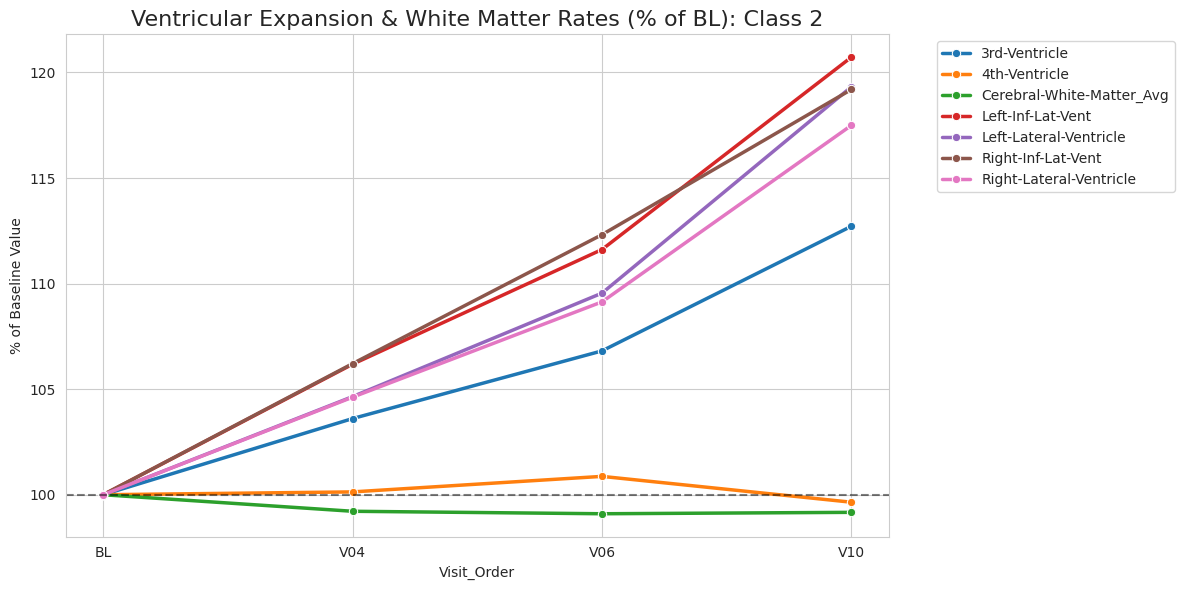

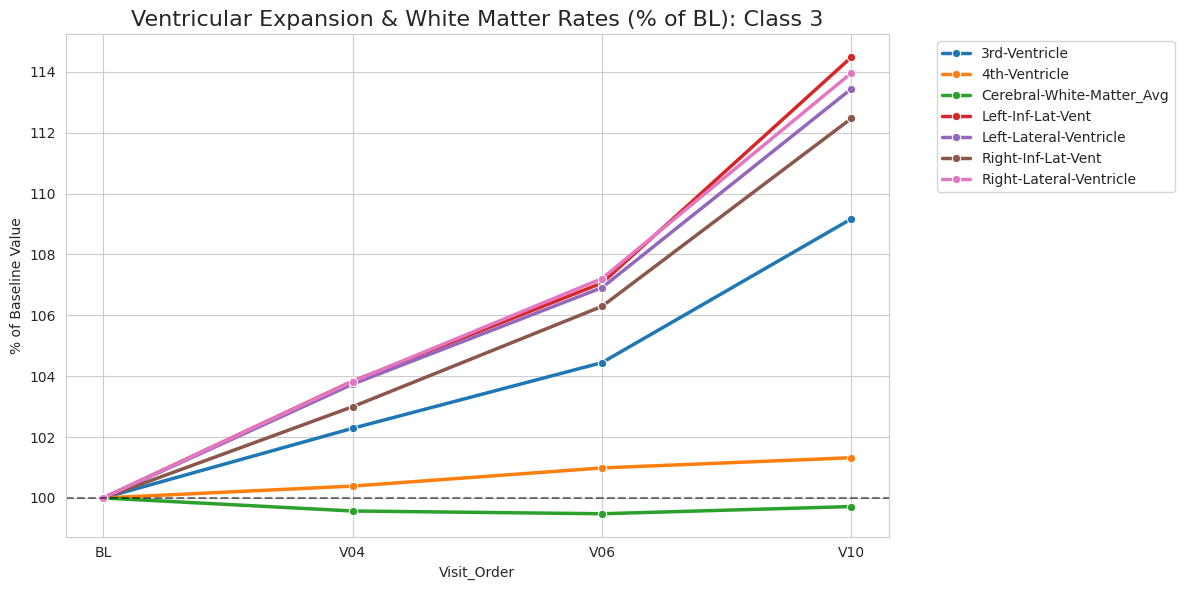

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the structure data (7 structures)
# Note: MaskVol is used for normalization as before
mask_vol = fs_data['MaskVol']

# Initialize dataframe with metadata
df_ventricles = fs_data[['PATNO', 'EVENT_ID', 'Study_Date', 'MaskVol']].copy()

# Add lateralized ventricles (Left and Right separately, not averaged)
df_ventricles['Left-Lateral-Ventricle'] = fs_data['Left-Lateral-Ventricle']
df_ventricles['Right-Lateral-Ventricle'] = fs_data['Right-Lateral-Ventricle']
df_ventricles['Left-Inf-Lat-Vent'] = fs_data['Left-Inf-Lat-Vent']
df_ventricles['Right-Inf-Lat-Vent'] = fs_data['Right-Inf-Lat-Vent']

# Add unlateralized ventricles (3rd and 4th)
df_ventricles['3rd-Ventricle'] = fs_data['3rd-Ventricle']
df_ventricles['4th-Ventricle'] = fs_data['4th-Ventricle']

# Add averaged Cerebral-White-Matter
df_ventricles['Cerebral-White-Matter_Avg'] = (fs_data['Left-Cerebral-White-Matter'] + fs_data['Right-Cerebral-White-Matter']) / 2

# 2. Normalize all structures by MaskVol
ventricle_structs = ['Left-Lateral-Ventricle', 'Right-Lateral-Ventricle', 'Left-Inf-Lat-Vent', 'Right-Inf-Lat-Vent', '3rd-Ventricle', '4th-Ventricle', 'Cerebral-White-Matter_Avg']
for col in ventricle_structs:
    df_ventricles[col] = df_ventricles[col] / df_ventricles['MaskVol']

# 3. Merge with class assignments
pp_m3 = pprob_df[['PATNO', 'class']].copy()
pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)
df_vent_plot = df_ventricles.merge(pp_m3, on='PATNO', how='inner')

# 4. Filter visits and map order
timepoint_map = {'BL': 0, 'V04': 1, 'V06': 2, 'V10': 3}
df_vent_plot = df_vent_plot[df_vent_plot['EVENT_ID'].isin(timepoint_map.keys())].copy()
df_vent_plot['Visit_Order'] = df_vent_plot['EVENT_ID'].map(timepoint_map)

# 5. Calculate % of Baseline per subject
def calculate_pct_baseline_vent(group):
    group = group.sort_values('Visit_Order')
    bl_row = group[group['EVENT_ID'] == 'BL']
    if not bl_row.empty:
        for region in ventricle_structs:
            bl_val = bl_row[region].values[0]
            if bl_val > 0:
                group[f'{region}_pct'] = (group[region] / bl_val) * 100
            else:
                group[f'{region}_pct'] = np.nan
    else:
        for region in ventricle_structs:
            group[f'{region}_pct'] = np.nan
    return group

df_vent_pct = df_vent_plot.groupby('PATNO', group_keys=False).apply(calculate_pct_baseline_vent, include_groups=False)

# 6. Reshape and Plot averages
pct_cols = [f'{r}_pct' for r in ventricle_structs]
df_long_vent = df_vent_pct.melt(id_vars=['class', 'Visit_Order', 'EVENT_ID'],
                               value_vars=pct_cols,
                               var_name='Structure', value_name='Pct_Baseline')

# Clean names for legend
df_long_vent['Structure'] = df_long_vent['Structure'].str.replace('_pct', '')

df_grouped_vent = df_long_vent.groupby(['class', 'Visit_Order', 'EVENT_ID', 'Structure'])['Pct_Baseline'].mean().reset_index()

sns.set_style("whitegrid")
classes = sorted(df_grouped_vent['class'].unique())

for cls in classes:
    plt.figure(figsize=(12, 6))
    data_cls = df_grouped_vent[df_grouped_vent['class'] == cls]
    sns.lineplot(data=data_cls, x='Visit_Order', y='Pct_Baseline', hue='Structure',
                 marker='o', palette='tab10', linewidth=2.5)
    plt.title(f"Ventricular Expansion & White Matter Rates (% of BL): Class {int(cls)}", fontsize=16)
    plt.xticks(range(4), ['BL', 'V04', 'V06', 'V10'])
    plt.axhline(100, ls='--', color='black', alpha=0.5)
    plt.ylabel("% of Baseline Value")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
# Calculate attrition: Number of unique patients per class at each timepoint
attrition_table = df_mri.groupby(['class', 'EVENT_ID'])['PATNO'].nunique().unstack()

# Reorder columns to match the timeline
attrition_table = attrition_table[['BL', 'V04', 'V06', 'V10']]

print("Number of patients with FastSurfer data at each timepoint, by class:")
display(attrition_table)


Number of patients with FastSurfer data at each timepoint, by class:


EVENT_ID,BL,V04,V06,V10
class,,,,
1,78,76,39,15
2,52,48,39,9
3,245,235,143,51


## Final LMMs

In [ ]:
import rpy2.robjects as ro
import pandas as pd
import numpy as np

# 1. Get class assignments from the permuted z-scored linear model
# (Using the _ref2 version so Class 3, the largest, is our reference)
with (ro.default_converter + ro.pandas2ri.converter).context():
    pprob_df = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))

df_classes = pprob_df[['PATNO', 'class']].copy()
df_classes['PATNO'] = df_classes['PATNO'].astype(int)

# 2. Extract RAW longitudinal volumes from fs_data and NORMALIZE by MaskVol
lateralized_regions = [
    ('Thalamus', 'Thalamus'),
    ('Caudate', 'Caudate'),
    ('Putamen', 'Putamen'),
    ('Hippocampus', 'Hippocampus'),
    ('choroid-plexus', 'choroid_plexus'),
    ('Pallidum', 'Pallidum'),
    ('Lateral-Ventricle', 'Lateral_Ventricle'),
    ('Inf-Lat-Vent', 'Inf_Lat_Vent'),
    ('Cerebral-White-Matter', 'Cerebral_White_Matter')
]

df_mri_norm = fs_data[['PATNO', 'EVENT_ID']].copy()

for fs_name, clean_name in lateralized_regions:
    avg_vol = (fs_data[f'Left-{fs_name}'] + fs_data[f'Right-{fs_name}']) / 2
    df_mri_norm[clean_name] = avg_vol / fs_data['MaskVol']

if 'WM-hypointensities' in fs_data.columns:
    df_mri_norm['WM_hypointensities'] = fs_data['WM-hypointensities'] / fs_data['MaskVol']

# 3. Add YEAR and baseline age/sex
df_years = df_pd_final[['PATNO', 'EVENT_ID', 'YEAR']].drop_duplicates()

# ---- MANUAL ADDITION OF MISSING SCANS ----
missing_years = pd.DataFrame([
    {'PATNO': 101070, 'EVENT_ID': 'V06', 'YEAR': 2.0},
    {'PATNO': 140671, 'EVENT_ID': 'V02', 'YEAR': 0.5},
    {'PATNO': 182927, 'EVENT_ID': 'V02', 'YEAR': 0.5},
    {'PATNO': 184507, 'EVENT_ID': 'V02', 'YEAR': 0.5}
])
df_years = pd.concat([df_years, missing_years], ignore_index=True)
# ------------------------------------------

df_bl_demo = df_pd_final[df_pd_final['YEAR'] == 0][['PATNO', 'age', 'SEX']].drop_duplicates()
df_bl_demo = df_bl_demo.rename(columns={'age': 'age_bl', 'SEX': 'sex'})

df_mri_norm = df_mri_norm.merge(df_classes, on='PATNO', how='inner')
df_mri_norm = df_mri_norm.merge(df_years, on=['PATNO', 'EVENT_ID'], how='inner')
df_mri_norm = df_mri_norm.merge(df_bl_demo, on='PATNO', how='left')

# Drop rows missing necessary covariates
df_mri_norm = df_mri_norm.dropna(subset=['YEAR', 'age_bl', 'sex'])

# Scale volumes by 10,000 for LMM numerical stability
mri_cols = [clean_name for _, clean_name in lateralized_regions]
if 'WM_hypointensities' in df_mri_norm.columns:
    mri_cols.append('WM_hypointensities')
df_mri_norm[mri_cols] = df_mri_norm[mri_cols] * 10000

# Push to R (Keeping the name df_lmm_raw in R to avoid changing all the hlme cells)
ro.globalenv['df_lmm_raw'] = df_mri_norm

# 4. Debug Checks
print("--- Data Preparation Summary ---")
print(f"Total scans available for LMM: {len(df_mri_norm)}")
print(f"Unique patients: {df_mri_norm['PATNO'].nunique()}")

is_182427_bl_excluded = not ((df_mri_norm['PATNO'] == 182427) & (df_mri_norm['EVENT_ID'] == 'BL')).any()
print(f"Is PATNO 182427 BL excluded? {is_182427_bl_excluded}")

print("\nFirst rows of normalized MRI data:")
display(df_mri_norm.head())


--- Data Preparation Summary ---
Total scans available for LMM: 1035
Unique patients: 382
Is PATNO 182427 BL excluded? True

First rows of normalized MRI data:


,PATNO,EVENT_ID,Thalamus,Caudate,Putamen,Hippocampus,choroid_plexus,Pallidum,Lateral_Ventricle,Inf_Lat_Vent,Cerebral_White_Matter,WM_hypointensities,class,YEAR,age_bl,sex
0,100001,BL,53.126248,22.775086,35.722861,30.153131,5.622047,14.973536,59.145007,3.415833,1651.503304,8.392854,3,0.0,67.386301,1
1,100001,V06,53.327520,22.382439,35.137056,29.126035,6.138172,14.934841,62.114323,4.004284,1629.981670,7.164673,3,2.0,67.386301,1
2,100001,V10,57.112356,22.108561,34.182363,29.795153,5.214914,13.095317,69.257036,3.422679,1685.121226,4.448294,3,4.0,67.386301,1
3,100005,BL,56.599581,22.228517,35.048891,32.891239,4.027355,15.477693,43.611102,1.704812,1750.308220,7.902339,3,0.0,52.791781,1
4,100005,V04,56.660257,22.097712,34.797080,32.605195,4.278038,15.167208,45.420021,1.823404,1745.427394,7.853863,3,1.0,52.791781,1


In [ ]:
print("--- Running LMM for Thalamus ---")
ro.r("""
library(lcmm)

# Initial setup for all models
df_lmm_raw$class <- relevel(as.factor(df_lmm_raw$class), ref = "3")
df_lmm_raw$YEAR <- as.numeric(df_lmm_raw$YEAR)
df_lmm_raw$sex <- as.factor(df_lmm_raw$sex)

p_vals_c1 <- list()
p_vals_c2 <- list()

# Run Thalamus
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Thalamus), ]
model_Thalamus <- hlme(Thalamus ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Thalamus))

# Calculate p-values manually from the model's coefficients and variance-covariance matrix
b <- model_Thalamus$best
se <- sqrt(abs(diag(model_Thalamus$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Thalamus <- p_val["class1:YEAR"]
    p_vals_c2$Thalamus <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Thalamus <- NA
    p_vals_c2$Thalamus <- NA
}
""")

--- Running LMM for Thalamus ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Thalamus ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  16 
     Convergence criteria: parameters= 1.5e-06 
                         : likelihood= 3.3e-07 
                         : second derivatives= 5.5e-12 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -2019.48  
     AIC: 4062.96  
     BIC: 4110.31  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   66.98469 1.60040  41.855 0.00000
class1      -0.15267 0.44513  -0.343 0.73162
class2       0.39456 0.5250

In [ ]:
print("--- Running LMM for Caudate ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Caudate), ]
model_Caudate <- hlme(Caudate ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Caudate))

b <- model_Caudate$best
se <- sqrt(abs(diag(model_Caudate$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Caudate <- p_val["class1:YEAR"]
    p_vals_c2$Caudate <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Caudate <- NA
    p_vals_c2$Caudate <- NA
}
""")

--- Running LMM for Caudate ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Caudate ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  11 
     Convergence criteria: parameters= 1.4e-07 
                         : likelihood= 5.3e-08 
                         : second derivatives= 4e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1335.65  
     AIC: 2695.31  
     BIC: 2742.65  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   25.78363 1.28944  19.996 0.00000
class1       0.18346 0.34679   0.529 0.59680
class2       0.60065 0.40929   

In [ ]:
print("--- Running LMM for Putamen ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Putamen), ]
model_Putamen <- hlme(Putamen ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Putamen))

b <- model_Putamen$best
se <- sqrt(abs(diag(model_Putamen$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Putamen <- p_val["class1:YEAR"]
    p_vals_c2$Putamen <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Putamen <- NA
    p_vals_c2$Putamen <- NA
}
""")

--- Running LMM for Putamen ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Putamen ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  9 
     Convergence criteria: parameters= 4.1e-10 
                         : likelihood= 1.4e-08 
                         : second derivatives= 1.2e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1802.59  
     AIC: 3629.18  
     BIC: 3676.53  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   38.00205 1.42283 26.709 0.00000
class1      -0.64914 0.39363 -1.649 0.09913
class2       0.74317 0.46468  1.5

In [ ]:
print("--- Running LMM for Hippocampus ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Hippocampus), ]
model_Hippocampus <- hlme(Hippocampus ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Hippocampus))

b <- model_Hippocampus$best
se <- sqrt(abs(diag(model_Hippocampus$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Hippocampus <- p_val["class1:YEAR"]
    p_vals_c2$Hippocampus <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Hippocampus <- NA
    p_vals_c2$Hippocampus <- NA
}
""")

--- Running LMM for Hippocampus ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Hippocampus ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  13 
     Convergence criteria: parameters= 1.4e-09 
                         : likelihood= 2.5e-08 
                         : second derivatives= 3.1e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1312.26  
     AIC: 2648.52  
     BIC: 2695.87  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   38.05890 1.15581 32.928 0.00000
class1       0.24753 0.30336  0.816 0.41452
class2       0.40370 0.3

In [ ]:
print("--- Running LMM for choroid_plexus ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$choroid_plexus), ]
model_choroid_plexus <- hlme(choroid_plexus ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_choroid_plexus))

b <- model_choroid_plexus$best
se <- sqrt(abs(diag(model_choroid_plexus$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$choroid_plexus <- p_val["class1:YEAR"]
    p_vals_c2$choroid_plexus <- p_val["class2:YEAR"]
} else {
    p_vals_c1$choroid_plexus <- NA
    p_vals_c2$choroid_plexus <- NA
}
""")

--- Running LMM for choroid_plexus ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = choroid_plexus ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  10 
     Convergence criteria: parameters= 1.4e-06 
                         : likelihood= 5.5e-06 
                         : second derivatives= 7.5e-12 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -902.32  
     AIC: 1828.63  
     BIC: 1875.98  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   -0.71167 0.60848  -1.170 0.24217
class1       0.07960 0.16558   0.481 0.63068
class2       0.1

In [ ]:
print("--- Running LMM for Pallidum ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Pallidum), ]
model_Pallidum <- hlme(Pallidum ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Pallidum))

b <- model_Pallidum$best
se <- sqrt(abs(diag(model_Pallidum$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Pallidum <- p_val["class1:YEAR"]
    p_vals_c2$Pallidum <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Pallidum <- NA
    p_vals_c2$Pallidum <- NA
}
""")

--- Running LMM for Pallidum ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Pallidum ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  11 
     Convergence criteria: parameters= 1.8e-06 
                         : likelihood= 2.4e-06 
                         : second derivatives= 3.4e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1093.16  
     AIC: 2210.33  
     BIC: 2257.67  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   16.52606 0.60599 27.271 0.00000
class1      -0.03687 0.16895 -0.218 0.82726
class2       0.33115 0.19880  

In [ ]:
print("--- Running LMM for Lateral_Ventricle ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Lateral_Ventricle), ]
model_Lateral_Ventricle <- hlme(Lateral_Ventricle ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Lateral_Ventricle))

b <- model_Lateral_Ventricle$best
se <- sqrt(abs(diag(model_Lateral_Ventricle$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Lateral_Ventricle <- p_val["class1:YEAR"]
    p_vals_c2$Lateral_Ventricle <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Lateral_Ventricle <- NA
    p_vals_c2$Lateral_Ventricle <- NA
}
""")

--- Running LMM for Lateral_Ventricle ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Lateral_Ventricle ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  23 
     Convergence criteria: parameters= 2.2e-07 
                         : likelihood= 3.7e-10 
                         : second derivatives= 2e-16 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -4118.32  
     AIC: 8260.65  
     BIC: 8307.99  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                  coef       Se     Wald p-value
intercept    -70.09088 23.19851   -3.021 0.00252
class1         0.74228  6.29477    0.118 0.90613

In [ ]:
print("--- Running LMM for Inf_Lat_Vent ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Inf_Lat_Vent), ]
model_Inf_Lat_Vent <- hlme(Inf_Lat_Vent ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Inf_Lat_Vent))

b <- model_Inf_Lat_Vent$best
se <- sqrt(abs(diag(model_Inf_Lat_Vent$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Inf_Lat_Vent <- p_val["class1:YEAR"]
    p_vals_c2$Inf_Lat_Vent <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Inf_Lat_Vent <- NA
    p_vals_c2$Inf_Lat_Vent <- NA
}
""")

--- Running LMM for Inf_Lat_Vent ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Inf_Lat_Vent ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  14 
     Convergence criteria: parameters= 1.9e-08 
                         : likelihood= 9.5e-09 
                         : second derivatives= 2.1e-15 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1326.44  
     AIC: 2676.87  
     BIC: 2724.22  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   -4.56578 1.07528 -4.246 0.00002
class1       0.48121 0.30316  1.587 0.11245
class2       0.48647 0

In [ ]:
print("--- Running LMM for Cerebral_White_Matter ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Cerebral_White_Matter), ]
model_Cerebral_White_Matter <- hlme(Cerebral_White_Matter ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Cerebral_White_Matter))

b <- model_Cerebral_White_Matter$best
se <- sqrt(abs(diag(model_Cerebral_White_Matter$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Cerebral_White_Matter <- p_val["class1:YEAR"]
    p_vals_c2$Cerebral_White_Matter <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Cerebral_White_Matter <- NA
    p_vals_c2$Cerebral_White_Matter <- NA
}
""")

--- Running LMM for Cerebral_White_Matter ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Cerebral_White_Matter ~ class * YEAR + age_bl + 
    sex, random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  34 
     Convergence criteria: parameters= 7.2e-08 
                         : likelihood= 2.6e-09 
                         : second derivatives= 4.2e-12 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -5337.7  
     AIC: 10699.4  
     BIC: 10746.75  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                  coef       Se     Wald p-value
intercept   1957.20797 43.78802   44.697 0.00000
class1        -7.28163 11.84695   -0.6

In [ ]:
print("--- Running LMM for WM_hypointensities ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$WM_hypointensities), ]
model_WM_hypointensities <- hlme(WM_hypointensities ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_WM_hypointensities))

b <- model_WM_hypointensities$best
se <- sqrt(abs(diag(model_WM_hypointensities$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$WM_hypointensities <- p_val["class1:YEAR"]
    p_vals_c2$WM_hypointensities <- p_val["class2:YEAR"]
} else {
    p_vals_c1$WM_hypointensities <- NA
    p_vals_c2$WM_hypointensities <- NA
}
""")

--- Running LMM for WM_hypointensities ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = WM_hypointensities ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  18 
     Convergence criteria: parameters= 7.8e-06 
                         : likelihood= 3.4e-06 
                         : second derivatives= 1.7e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -3573.58  
     AIC: 7171.16  
     BIC: 7218.51  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                 coef      Se    Wald p-value
intercept   -11.77822 7.99349  -1.473 0.14062
class1        2.40630 2.66502   0.903 0.36657
clas

In [ ]:
import rpy2.robjects as ro

ro.r("""
print("--- Names of the model object ---")
print(names(model_Putamen))

print("\n--- Structure of the model object (max.level=1) ---")
str(model_Putamen, max.level=1)

print("\n--- Names of the best coefficients ---")
print(names(model_Putamen$best))
""")


[1] "--- Names of the model object ---"
 [1] "ns"          "ng"          "idea0"       "idprob0"     "idg0"       
 [6] "idcor0"      "loglik"      "best"        "V"           "gconv"      
[11] "conv"        "call"        "niter"       "N"           "idiag"      
[16] "pred"        "pprob"       "predRE"      "classpredRE" "varRE"      
[21] "Xnames"      "Xnames2"     "cholesky"    "na.action"   "AIC"        
[26] "BIC"         "data"        "wRandom"     "b0Random"    "levels"     
[31] "var.time"    "runtime"    
[1] "\n--- Structure of the model object (max.level=1) ---"
List of 32
 $ ns         : int 382
 $ ng         : num 1
 $ idea0      : num [1:8] 1 0 0 1 0 0 0 0
 $ idprob0    : num [1:8] 0 0 0 0 0 0 0 0
 $ idg0       : num [1:8] 1 1 1 1 1 1 1 1
 $ idcor0     : num [1:8] 0 0 0 0 0 0 0 0
 $ loglik     : num -1803
 $ best       : Named num [1:12] 38.002 -0.6491 0.7432 -0.201 -0.0856 ...
  ..- attr(*, "names")= chr [1:12] "intercept" "class1" "class2" "YEAR" ...
 $ V          : 

In [ ]:
import pandas as pd

# Manually extracted p-values from the previous LMM summaries
data = {
    'Region': [
        'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
        'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
        'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
    ],
    'P_Class1_vs_3_YEAR': [
        0.94989, 0.68395, 0.43270, 0.56099,
        0.99015, 0.27110, 0.39287, 0.05395,
        0.79898, 0.06723
    ],
    'P_Class2_vs_3_YEAR': [
        0.83530, 0.03572, 0.30584, 0.09017,
        0.04356, 0.98973, 0.02019, 0.00886,
        0.43032, 0.37777
    ]
}

df_pvals = pd.DataFrame(data)

print("--- P-values for class-time interactions (Reference: Class 3) ---")
display(df_pvals)


--- P-values for class-time interactions (Reference: Class 3) ---


,Region,P_Class1_vs_3_YEAR,P_Class2_vs_3_YEAR
0,Thalamus,0.94989,0.83530
1,Caudate,0.68395,0.03572
2,Putamen,0.43270,0.30584
3,Hippocampus,0.56099,0.09017
4,choroid_plexus,0.99015,0.04356
5,Pallidum,0.27110,0.98973
6,Lateral_Ventricle,0.39287,0.02019
7,Inf_Lat_Vent,0.05395,0.00886
8,Cerebral_White_Matter,0.79898,0.43032
9,WM_hypointensities,0.06723,0.37777


In [ ]:
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

# Create a copy of the p-values dataframe
df_pvals_fdr = df_pvals.copy()

# Apply FDR correction (Benjamini-Hochberg) with q < 0.10
reject_c1, pval_corr_c1 = fdrcorrection(df_pvals_fdr['P_Class1_vs_3_YEAR'], alpha=0.10, method='indep')
reject_c2, pval_corr_c2 = fdrcorrection(df_pvals_fdr['P_Class2_vs_3_YEAR'], alpha=0.10, method='indep')

# Add corrected p-values and significance flags to the dataframe
df_pvals_fdr['FDR_P_Class1'] = pval_corr_c1
df_pvals_fdr['Sig_Class1 (q<0.10)'] = reject_c1

df_pvals_fdr['FDR_P_Class2'] = pval_corr_c2
df_pvals_fdr['Sig_Class2 (q<0.10)'] = reject_c2

print("--- FDR Corrected P-values (q < 0.10) ---")
display(df_pvals_fdr)


--- FDR Corrected P-values (q < 0.10) ---


,Region,P_Class1_vs_3_YEAR,P_Class2_vs_3_YEAR,FDR_P_Class1,Sig_Class1 (q<0.10),FDR_P_Class2,Sig_Class2 (q<0.10)
0,Thalamus,0.94989,0.83530,0.990150,False,0.928111,False
1,Caudate,0.68395,0.03572,0.977071,False,0.108900,False
2,Putamen,0.43270,0.30584,0.865400,False,0.509733,False
3,Hippocampus,0.56099,0.09017,0.934983,False,0.180340,False
4,choroid_plexus,0.99015,0.04356,0.990150,False,0.108900,False
5,Pallidum,0.27110,0.98973,0.865400,False,0.989730,False
6,Lateral_Ventricle,0.39287,0.02019,0.865400,False,0.100950,False
7,Inf_Lat_Vent,0.05395,0.00886,0.336150,False,0.088600,True
8,Cerebral_White_Matter,0.79898,0.43032,0.990150,False,0.537900,False
9,WM_hypointensities,0.06723,0.37777,0.336150,False,0.537900,False


In [ ]:
import pandas as pd
import numpy as np

# Technical Mapping Logic for LMM Trajectories:
# The model was run with Original Class 2 as the reference (permut index 3).
# Permuted Class 1 -> Original Class 1
# Permuted Class 2 -> Original Class 3

# 1. Use the FDR-corrected p-value table from the Random Slopes model
df_lmm_unpermuted = df_pvals_fdr.copy()

# 2. Rename columns to reflect the original class identities for publication
# Removing 'vs 2' as requested and focusing on Class 1 and Class 3 labels
df_lmm_final = df_lmm_unpermuted.rename(columns={
    'P_Class1_vs_3_YEAR': 'p-value (Class 1)',
    'FDR_P_Class1': 'FDR q (Class 1)',
    'P_Class2_vs_3_YEAR': 'p-value (Class 3)',
    'FDR_P_Class2': 'FDR q (Class 3)'
})

# 3. Organize columns for the final table
output_cols = [
    'Region',
    'p-value (Class 1)', 'FDR q (Class 1)',
    'p-value (Class 3)', 'FDR q (Class 3)'
]
df_lmm_final = df_lmm_final[output_cols]

# 4. Export the unpermuted LMM results
output_path_lmm = '/content/m3_lmm_trajectories_unpermuted.csv'
df_lmm_final.to_csv(output_path_lmm, index=False)

print(f'Unpermuted LMM Results Table exported to: {output_path_lmm}')

# Display with left-aligned Region column
display(df_lmm_final.style.set_properties(subset=['Region'], **{'text-align': 'left'}).set_caption('LMM Slope Comparisons (Reference: Class 2)'))

Unpermuted LMM Results Table exported to: /content/m3_lmm_trajectories_unpermuted.csv


,Region,p-value (Class 1),FDR q (Class 1),p-value (Class 3),FDR q (Class 3)
0,Thalamus,0.949890,0.990150,0.835300,0.928111
1,Caudate,0.683950,0.977071,0.035720,0.108900
2,Putamen,0.432700,0.865400,0.305840,0.509733
3,Hippocampus,0.560990,0.934983,0.090170,0.180340
4,choroid_plexus,0.990150,0.990150,0.043560,0.108900
5,Pallidum,0.271100,0.865400,0.989730,0.989730
6,Lateral_Ventricle,0.392870,0.865400,0.020190,0.100950
7,Inf_Lat_Vent,0.053950,0.336150,0.008860,0.088600
8,Cerebral_White_Matter,0.798980,0.990150,0.430320,0.537900
9,WM_hypointensities,0.067230,0.336150,0.377770,0.537900


In [ ]:
import pandas as pd
import csv

# 1. Load the unpermuted LMM results
df_lmm = pd.read_csv('/content/m3_lmm_trajectories_unpermuted.csv')

# 2. Professional Region Mapping
rename_map = {
    'Thalamus': 'Thalamus',
    'Caudate': 'Caudate',
    'Putamen': 'Putamen',
    'Hippocampus': 'Hippocampus',
    'choroid_plexus': 'Choroid Plexus',
    'Pallidum': 'Pallidum',
    'Lateral_Ventricle': 'Lateral Ventricle',
    'Inf_Lat_Vent': 'Inf. Lat. Ventricle',
    'Cerebral_White_Matter': 'Cerebral White Matter',
    'WM_hypointensities': 'WM Hypointensities'
}
df_lmm['Region'] = df_lmm['Region'].replace(rename_map)

# 3. Helper functions for conditional formatting
def format_p_value(val):
    p_float = float(val)
    if p_float < 0.001:
        formatted = '<.001'
    else:
        formatted = '{:.3f}'.format(p_float)
    # Bold if unadjusted p < 0.05
    return f"**{formatted}**" if p_float < 0.05 else formatted

def format_q_value(val):
    q_float = float(val)
    if q_float < 0.001:
        formatted = '<.001'
    else:
        formatted = '{:.3f}'.format(q_float)
    # Bold if FDR q < 0.10
    return f"**{formatted}**" if q_float < 0.10 else formatted

# 4. Apply formatting to Classes 1 and 3
for cls in [1, 3]:
    p_col = f'p-value (Class {cls})'
    q_col = f'FDR q (Class {cls})'

    # Apply bolding based on independent thresholds for p and q
    df_lmm[p_col] = df_lmm[p_col].apply(format_p_value)
    df_lmm[q_col] = df_lmm[q_col].apply(format_q_value)

# 5. Rename Headings for MyST layout
df_lmm = df_lmm.rename(columns={
    'p-value (Class 1)': 'p-value<br>(Class 1)',
    'FDR q (Class 1)': 'FDR q<0.10<br>(Class 1)',
    'p-value (Class 3)': 'p-value<br>(Class 3)',
    'FDR q (Class 3)': 'FDR q<0.10<br>(Class 3)'
})

# 6. Export
output_myst_lmm = '/content/m3_lmm_results_myst_formatted.csv'
df_lmm.to_csv(output_myst_lmm, index=False, quoting=csv.QUOTE_ALL)

print(f"LMM results saved to: {output_myst_lmm}")
display(df_lmm.style.set_properties(subset=['Region'], **{'text-align': 'left'}))

LMM results saved to: /content/m3_lmm_results_myst_formatted.csv


,Region,p-value(Class 1),FDR q<0.10(Class 1),p-value(Class 3),FDR q<0.10(Class 3)
0,Thalamus,0.950,0.990,0.835,0.928
1,Caudate,0.684,0.977,**0.036**,0.109
2,Putamen,0.433,0.865,0.306,0.510
3,Hippocampus,0.561,0.935,0.090,0.180
4,Choroid Plexus,0.990,0.990,**0.044**,0.109
5,Pallidum,0.271,0.865,0.990,0.990
6,Lateral Ventricle,0.393,0.865,**0.020**,0.101
7,Inf. Lat. Ventricle,0.054,0.336,**0.009**,**0.089**
8,Cerebral White Matter,0.799,0.990,0.430,0.538
9,WM Hypointensities,0.067,0.336,0.378,0.538


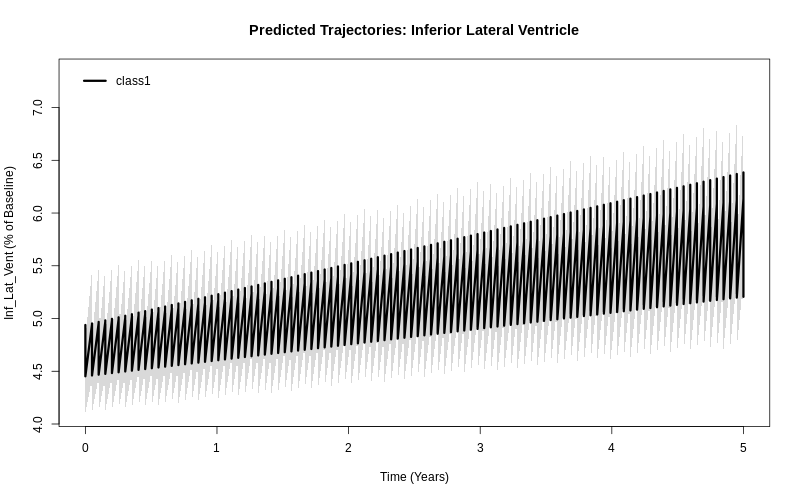

In [ ]:
%%R -w 800 -h 500 -u px
library(lcmm)

# 1. Create a simulated dataset spanning the time range (YEAR 0 to 5)
new_data <- expand.grid(
    class = factor(c("1", "2", "3")),
    YEAR = seq(0, 5, length.out = 100),
    age_bl = mean(df_lmm_raw$age_bl, na.rm = TRUE),
    sex = factor("1", levels = c("0", "1"))
)

# 2. Generate predictions
pred_Inf_Lat_Vent <- predictY(model_Inf_Lat_Vent,
                              new_data,
                              var.time = "YEAR",
                              draws = TRUE)

# 3. Explicitly plot using R's graphics device
plot(pred_Inf_Lat_Vent,
     lty = 1,
     lwd = 3,
     ylab = "Inf_Lat_Vent (% of Baseline)",
     xlab = "Time (Years)",
     main = "Predicted Trajectories: Inferior Lateral Ventricle",
     legend.loc = "topleft",
     shades = TRUE)

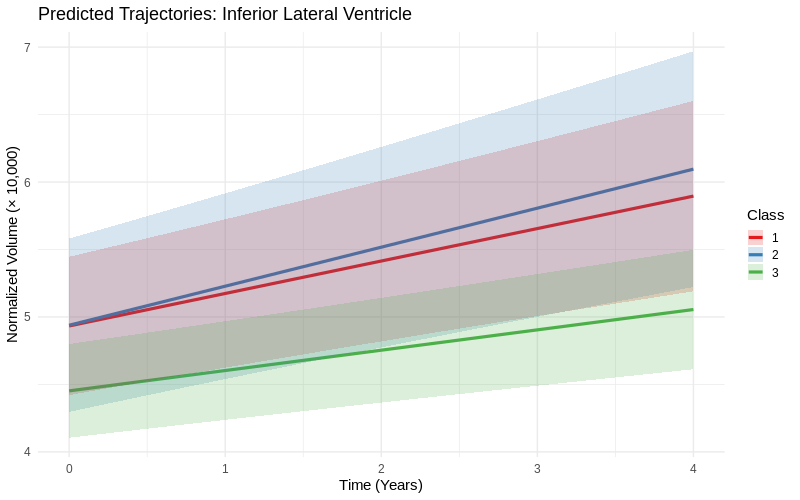

In [ ]:
%%R -w 800 -h 500 -u px
library(lcmm)
library(ggplot2)

# 1. Create a simulated dataset spanning the true time range (YEAR 0 to 4)
new_data <- expand.grid(
    YEAR = seq(0, 4, length.out = 100),
    class = factor(c("1", "2", "3")),
    age_bl = mean(df_lmm_raw$age_bl, na.rm = TRUE),
    sex = factor("1", levels = c("0", "1"))
)

# 2. Generate predictions
pred_Inf_Lat_Vent <- predictY(model_Inf_Lat_Vent,
                              new_data,
                              var.time = "YEAR",
                              draws = TRUE)

# 3. Bind predictions to our new_data to keep the 'class' grouping
plot_data <- cbind(new_data, pred_Inf_Lat_Vent$pred)

# 4. Plot using ggplot2
ggplot(plot_data, aes(x = YEAR, y = Ypred, color = class, fill = class)) +
  geom_line(linewidth = 1.5) +
  geom_ribbon(aes(ymin = lower.Ypred, ymax = upper.Ypred), alpha = 0.2, color = NA) +
  theme_minimal(base_size = 15) +
  labs(
    title = "Predicted Trajectories: Inferior Lateral Ventricle",
    x = "Time (Years)",
    y = "Normalized Volume (× 10,000)",
    color = "Class",
    fill = "Class"
  ) +
  scale_color_brewer(palette = "Set1") +
  scale_fill_brewer(palette = "Set1")

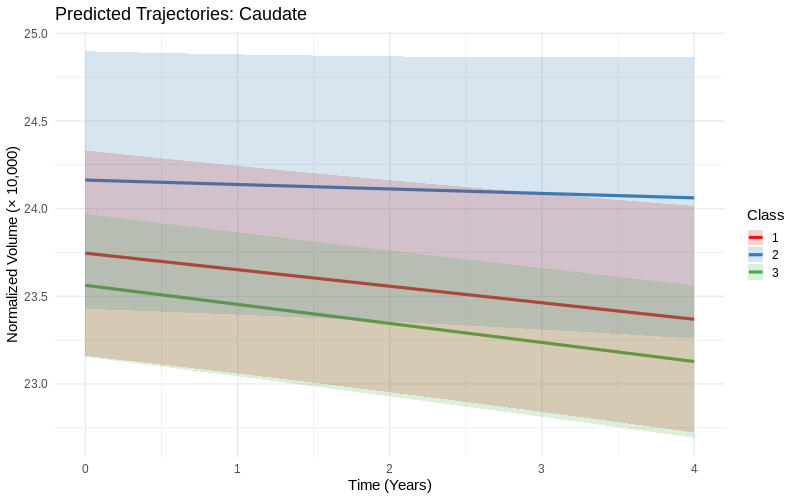

In [ ]:
%%R -w 800 -h 500 -u px
library(lcmm)
library(ggplot2)

# 1. Create a simulated dataset spanning the true time range (YEAR 0 to 4)
new_data <- expand.grid(
    YEAR = seq(0, 4, length.out = 100),
    class = factor(c("1", "2", "3")),
    age_bl = mean(df_lmm_raw$age_bl, na.rm = TRUE),
    sex = factor("1", levels = c("0", "1"))
)

# 2. Generate predictions for Caudate
pred_Caudate <- predictY(model_Caudate,
                         new_data,
                         var.time = "YEAR",
                         draws = TRUE)

# 3. Bind predictions to our new_data to keep the 'class' grouping
plot_data <- cbind(new_data, pred_Caudate$pred)

# 4. Plot using ggplot2
ggplot(plot_data, aes(x = YEAR, y = Ypred, color = class, fill = class)) +
  geom_line(linewidth = 1.5) +
  geom_ribbon(aes(ymin = lower.Ypred, ymax = upper.Ypred), alpha = 0.2, color = NA) +
  theme_minimal(base_size = 15) +
  labs(
    title = "Predicted Trajectories: Caudate",
    x = "Time (Years)",
    y = "Normalized Volume (× 10,000)",
    color = "Class",
    fill = "Class"
  ) +
  scale_color_brewer(palette = "Set1") +
  scale_fill_brewer(palette = "Set1")

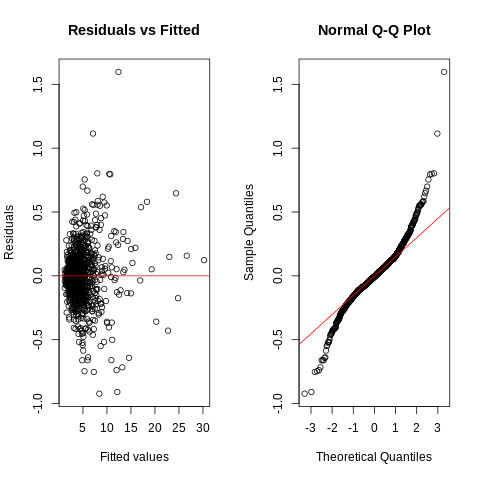

In [ ]:
%%R
res <- residuals(model_Inf_Lat_Vent)

# Diagnostic plots for the significant finding
par(mfrow = c(1,2))
plot(fitted(model_Inf_Lat_Vent), res, main = "Residuals vs Fitted",
     xlab = "Fitted values", ylab = "Residuals")
abline(h = 0, col = "red")
qqnorm(res, main = "Normal Q-Q Plot"); qqline(res, col = "red")

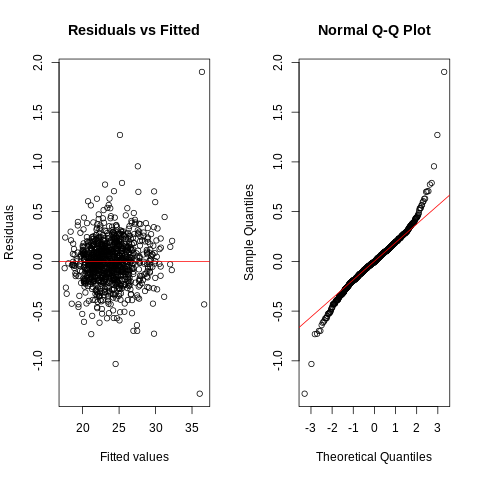

In [ ]:
%%R
res <- residuals(model_Caudate)

# Diagnostic plots for the significant finding
par(mfrow = c(1,2))
plot(fitted(model_Caudate), res, main = "Residuals vs Fitted",
     xlab = "Fitted values", ylab = "Residuals")
abline(h = 0, col = "red")
qqnorm(res, main = "Normal Q-Q Plot"); qqline(res, col = "red")

## Sensitivity Analysis

In [ ]:
print("--- Sensitivity Analysis: LMM for Thalamus (Random Intercept Only) ---")
ro.r("""
model_Thalamus_ri <- hlme(Thalamus ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Thalamus_ri))
""")

--- Sensitivity Analysis: LMM for Thalamus (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Thalamus ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  9 
     Convergence criteria: parameters= 1.1e-09 
                         : likelihood= 2.6e-07 
                         : second derivatives= 6.2e-06 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -2044.27  
     AIC: 4108.54  
     BIC: 4147.99  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   67.02574 1.59628  41.989 0.00000
class1      -0.15978 0.43794  -0.3

In [ ]:
print("--- Sensitivity Analysis: LMM for Caudate (Random Intercept Only) ---")
ro.r("""
model_Caudate_ri <- hlme(Caudate ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Caudate_ri))
""")

--- Sensitivity Analysis: LMM for Caudate (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Caudate ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  10 
     Convergence criteria: parameters= 2.8e-08 
                         : likelihood= 1.2e-08 
                         : second derivatives= 7.1e-14 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1356.36  
     AIC: 2732.72  
     BIC: 2772.17  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   25.17739 1.28689 19.565 0.00000
class1       0.17519 0.35122  0.499 0

In [ ]:
print("--- Sensitivity Analysis: LMM for Putamen (Random Intercept Only) ---")
ro.r("""
model_Putamen_ri <- hlme(Putamen ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Putamen_ri))
""")

--- Sensitivity Analysis: LMM for Putamen (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Putamen ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  11 
     Convergence criteria: parameters= 1.2e-08 
                         : likelihood= 4.2e-09 
                         : second derivatives= 3.8e-14 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1833.95  
     AIC: 3687.9  
     BIC: 3727.35  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   37.19039 1.50442 24.721 0.00000
class1      -0.59872 0.41219 -1.453 0.

In [ ]:
print("--- Sensitivity Analysis: LMM for Hippocampus (Random Intercept Only) ---")
ro.r("""
model_Hippocampus_ri <- hlme(Hippocampus ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Hippocampus_ri))
""")

--- Sensitivity Analysis: LMM for Hippocampus (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Hippocampus ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  10 
     Convergence criteria: parameters= 1.4e-05 
                         : likelihood= 1e-05 
                         : second derivatives= 1.2e-10 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1334.31  
     AIC: 2688.63  
     BIC: 2728.08  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   38.76383 1.12165  34.560 0.00000
class1       0.26582 0.30627 

In [ ]:
print("--- Sensitivity Analysis: LMM for Choroid Plexus (Random Intercept Only) ---")
ro.r("""
model_choroid_plexus_ri <- hlme(choroid_plexus ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_choroid_plexus_ri))
""")

--- Sensitivity Analysis: LMM for Choroid Plexus (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = choroid_plexus ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  10 
     Convergence criteria: parameters= 6.6e-06 
                         : likelihood= 1.8e-05 
                         : second derivatives= 2e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -921.17  
     AIC: 1862.35  
     BIC: 1901.8  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   -0.70187 0.61486 -1.142 0.25366
class1       0.06357 0.1685

In [ ]:
print("--- Sensitivity Analysis: LMM for Pallidum (Random Intercept Only) ---")
ro.r("""
model_Pallidum_ri <- hlme(Pallidum ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Pallidum_ri))
""")

--- Sensitivity Analysis: LMM for Pallidum (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Pallidum ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  12 
     Convergence criteria: parameters= 1.1e-08 
                         : likelihood= 3.8e-08 
                         : second derivatives= 4.5e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1136.92  
     AIC: 2293.84  
     BIC: 2333.29  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   16.53250 0.60323 27.407 0.00000
class1      -0.02928 0.16632 -0.176

In [ ]:
print("--- Sensitivity Analysis: LMM for Lateral Ventricle (Random Intercept Only) ---")
ro.r("""
model_Lateral_Ventricle_ri <- hlme(Lateral_Ventricle ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Lateral_Ventricle_ri))
""")

--- Sensitivity Analysis: LMM for Lateral Ventricle (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Lateral_Ventricle ~ class * YEAR + age_bl + sex, 
    random = ~1, subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  34 
     Convergence criteria: parameters= 6.5e-07 
                         : likelihood= 5.5e-10 
                         : second derivatives= 5.2e-16 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -4281.79  
     AIC: 8583.58  
     BIC: 8623.04  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                  coef       Se     Wald p-value
intercept   -144.91864 24.32246   -5.958 0.00000
class1 

In [ ]:
print("--- Sensitivity Analysis: LMM for Inf Lat Vent (Random Intercept Only) ---")
ro.r("""
model_Inf_Lat_Vent_ri <- hlme(Inf_Lat_Vent ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Inf_Lat_Vent_ri))
""")

--- Sensitivity Analysis: LMM for Inf Lat Vent (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Inf_Lat_Vent ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  9 
     Convergence criteria: parameters= 6e-06 
                         : likelihood= 5.7e-06 
                         : second derivatives= 8.4e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1499.51  
     AIC: 3019.02  
     BIC: 3058.47  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   -8.39557 1.18987 -7.056 0.00000
class1       0.35465 0.32542  

In [ ]:
print("--- Sensitivity Analysis: LMM for Cerebral White Matter (Random Intercept Only) ---")
ro.r("""
model_Cerebral_White_Matter_ri <- hlme(Cerebral_White_Matter ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Cerebral_White_Matter_ri))
""")

--- Sensitivity Analysis: LMM for Cerebral White Matter (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Cerebral_White_Matter ~ class * YEAR + age_bl + 
    sex, random = ~1, subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  27 
     Convergence criteria: parameters= 7.4e-06 
                         : likelihood= 4.5e-09 
                         : second derivatives= 5.3e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -5356.39  
     AIC: 10732.78  
     BIC: 10772.24  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                  coef       Se     Wald p-value
intercept   1963.26840 43.30324   45.338 0.000

In [ ]:
print("--- Sensitivity Analysis: LMM for WM Hypointensities (Random Intercept Only) ---")
ro.r("""
model_WM_hypointensities_ri <- hlme(WM_hypointensities ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_WM_hypointensities_ri))
""")

--- Sensitivity Analysis: LMM for WM Hypointensities (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = WM_hypointensities ~ class * YEAR + age_bl + sex, 
    random = ~1, subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  18 
     Convergence criteria: parameters= 4.7e-10 
                         : likelihood= 3.2e-11 
                         : second derivatives= 1.1e-16 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -3808.4  
     AIC: 7636.81  
     BIC: 7676.26  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                 coef       Se    Wald p-value
intercept   -65.87499 10.63937  -6.192 0.00000
class1    

In [ ]:
import pandas as pd

# Manually extracting p-values for Class:YEAR interactions from the Sensitivity Analysis (Random Intercept Only models)
# Reference: Class 3
sensitivity_data = {
    'Region': [
        'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
        'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
        'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
    ],
    'P_Class1_vs_3_YEAR_RI': [
        0.98393, 0.41121, 0.16353, 0.17989,
        0.41129, 0.05026, 0.00199, 0.00150,
        0.95445, 0.07488
    ],
    'P_Class2_vs_3_YEAR_RI': [
        0.83040, 0.01039, 0.15645, 0.06738,
        0.00560, 0.57498, 0.00303, 0.00074,
        0.33456, 0.12148
    ]
}

df_sensitivity_pvals = pd.DataFrame(sensitivity_data)

print("--- Sensitivity Analysis Interaction P-values (Random Intercept Only) ---")
display(df_sensitivity_pvals)

--- Sensitivity Analysis Interaction P-values (Random Intercept Only) ---


,Region,P_Class1_vs_3_YEAR_RI,P_Class2_vs_3_YEAR_RI
0,Thalamus,0.98393,0.83040
1,Caudate,0.41121,0.01039
2,Putamen,0.16353,0.15645
3,Hippocampus,0.17989,0.06738
4,choroid_plexus,0.41129,0.00560
5,Pallidum,0.05026,0.57498
6,Lateral_Ventricle,0.00199,0.00303
7,Inf_Lat_Vent,0.00150,0.00074
8,Cerebral_White_Matter,0.95445,0.33456
9,WM_hypointensities,0.07488,0.12148


In [ ]:
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

# Apply FDR correction to the sensitivity analysis p-values
df_sens_fdr = df_sensitivity_pvals.copy()

# Correct Class 1 vs 3 YEAR RI
reject_c1, pval_corr_c1 = fdrcorrection(df_sens_fdr['P_Class1_vs_3_YEAR_RI'], alpha=0.10, method='indep')
df_sens_fdr['FDR_P_Class1_RI'] = pval_corr_c1
df_sens_fdr['Sig_Class1_RI (q<0.10)'] = reject_c1

# Correct Class 2 vs 3 YEAR RI
reject_c2, pval_corr_c2 = fdrcorrection(df_sens_fdr['P_Class2_vs_3_YEAR_RI'], alpha=0.10, method='indep')
df_sens_fdr['FDR_P_Class2_RI'] = pval_corr_c2
df_sens_fdr['Sig_Class2_RI (q<0.10)'] = reject_c2

print("--- FDR Corrected P-values for Sensitivity Analysis (Random Intercept Models, q < 0.10) ---")
display(df_sens_fdr)

--- FDR Corrected P-values for Sensitivity Analysis (Random Intercept Models, q < 0.10) ---


,Region,P_Class1_vs_3_YEAR_RI,P_Class2_vs_3_YEAR_RI,FDR_P_Class1_RI,Sig_Class1_RI (q<0.10),FDR_P_Class2_RI,Sig_Class2_RI (q<0.10)
0,Thalamus,0.98393,0.83040,0.983930,False,0.830400,False
1,Caudate,0.41121,0.01039,0.514112,False,0.025975,True
2,Putamen,0.16353,0.15645,0.299817,False,0.223500,False
3,Hippocampus,0.17989,0.06738,0.299817,False,0.134760,False
4,choroid_plexus,0.41129,0.00560,0.514112,False,0.018667,True
5,Pallidum,0.05026,0.57498,0.167533,False,0.638867,False
6,Lateral_Ventricle,0.00199,0.00303,0.009950,True,0.015150,True
7,Inf_Lat_Vent,0.00150,0.00074,0.009950,True,0.007400,True
8,Cerebral_White_Matter,0.95445,0.33456,0.983930,False,0.418200,False
9,WM_hypointensities,0.07488,0.12148,0.187200,False,0.202467,False


In [ ]:
# 1. Prepare the Primary Analysis dataframe for merging
# df_pvals_fdr contains the Random Slope model results
df_primary = df_pvals_fdr[['Region', 'FDR_P_Class1', 'Sig_Class1 (q<0.10)', 'FDR_P_Class2', 'Sig_Class2 (q<0.10)']].copy()
df_primary.columns = ['Region', 'Primary_FDR_P_C1', 'Primary_Sig_C1', 'Primary_FDR_P_C2', 'Primary_Sig_C2']

# 2. Prepare the Sensitivity Analysis dataframe for merging
df_sensitivity = df_sens_fdr[['Region', 'FDR_P_Class1_RI', 'Sig_Class1_RI (q<0.10)', 'FDR_P_Class2_RI', 'Sig_Class2_RI (q<0.10)']].copy()
df_sensitivity.columns = ['Region', 'Sens_FDR_P_C1', 'Sens_Sig_C1', 'Sens_FDR_P_C2', 'Sens_Sig_C2']

# 3. Merge and reorganize
df_final_comparison = df_primary.merge(df_sensitivity, on='Region')

# Sort by Class 2 Primary P-value to highlight the most robust findings
df_final_comparison = df_final_comparison.sort_values('Primary_FDR_P_C2')

print("--- Final Comparison: Primary (Random Slopes) vs. Sensitivity (Random Intercepts) ---")
display(df_final_comparison)

--- Final Comparison: Primary (Random Slopes) vs. Sensitivity (Random Intercepts) ---


,Region,Primary_FDR_P_C1,Primary_Sig_C1,Primary_FDR_P_C2,Primary_Sig_C2,Sens_FDR_P_C1,Sens_Sig_C1,Sens_FDR_P_C2,Sens_Sig_C2
7,Inf_Lat_Vent,0.336150,False,0.088600,True,0.009950,True,0.007400,True
6,Lateral_Ventricle,0.865400,False,0.100950,False,0.009950,True,0.015150,True
1,Caudate,0.977071,False,0.108900,False,0.514112,False,0.025975,True
4,choroid_plexus,0.990150,False,0.108900,False,0.514112,False,0.018667,True
3,Hippocampus,0.934983,False,0.180340,False,0.299817,False,0.134760,False
2,Putamen,0.865400,False,0.509733,False,0.299817,False,0.223500,False
9,WM_hypointensities,0.336150,False,0.537900,False,0.187200,False,0.202467,False
8,Cerebral_White_Matter,0.990150,False,0.537900,False,0.983930,False,0.418200,False
0,Thalamus,0.990150,False,0.928111,False,0.983930,False,0.830400,False
5,Pallidum,0.865400,False,0.989730,False,0.167533,False,0.638867,False


In [ ]:
import pandas as pd
import rpy2.robjects as ro

# 1. Define the list of regions we modeled
regions = [
    'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
    'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
    'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
]

# 2. Extract AIC and BIC from the R objects using a small R helper script
ro.r("""
get_metrics <- function(model_name) {
  if (exists(model_name)) {
    m <- get(model_name)
    return(c(AIC = m$AIC, BIC = m$BIC))
  } else {
    return(c(AIC = NA, BIC = NA))
  }
}
""")

comparison_results = []

for region in regions:
    # Primary models were named 'model_Region'
    # Sensitivity models were named 'model_Region_ri'
    metrics_rs = ro.r(f"get_metrics('model_{region}')")
    metrics_ri = ro.r(f"get_metrics('model_{region}_ri')")

    aic_rs, bic_rs = metrics_rs[0], metrics_rs[1]
    aic_ri, bic_ri = metrics_ri[0], metrics_ri[1]

    # Determine model preference
    better_aic = "Random Slope" if aic_rs < aic_ri else "Random Intercept"
    better_bic = "Random Slope" if bic_rs < bic_ri else "Random Intercept"

    comparison_results.append({
        'Region': region,
        'AIC (Random ~ YEAR)': aic_rs,
        'BIC (Random ~ YEAR)': bic_rs,
        'AIC (Random ~ 1)': aic_ri,
        'BIC (Random ~ 1)': bic_ri,
        'Smaller AIC': better_aic,
        'Smaller BIC': better_bic
    })

# 3. Create DataFrame and Display
df_model_fit = pd.DataFrame(comparison_results)

print("--- Model Comparison Table: Random Slopes vs. Random Intercepts ---")
display(df_model_fit)

# Quick summary
win_aic = df_model_fit['Smaller AIC'].value_counts()
win_bic = df_model_fit['Smaller BIC'].value_counts()
print(f"\nSummary (AIC): {win_aic.get('Random Slope', 0)} regions favored Random Slope.")
print(f"Summary (BIC): {win_bic.get('Random Slope', 0)} regions favored Random Slope.")

--- Model Comparison Table: Random Slopes vs. Random Intercepts ---


,Region,AIC (Random ~ YEAR),BIC (Random ~ YEAR),AIC (Random ~ 1),BIC (Random ~ 1),Smaller AIC,Smaller BIC
0,Thalamus,4062.961560,4110.306607,4108.538892,4147.993098,Random Slope,Random Slope
1,Caudate,2695.307659,2742.652706,2732.715083,2772.169289,Random Slope,Random Slope
2,Putamen,3629.183211,3676.528258,3687.899522,3727.353728,Random Slope,Random Slope
3,Hippocampus,2648.523392,2695.868439,2688.627161,2728.081367,Random Slope,Random Slope
4,choroid_plexus,1828.631023,1875.976070,1862.345420,1901.799626,Random Slope,Random Slope
5,Pallidum,2210.328473,2257.673520,2293.838613,2333.292820,Random Slope,Random Slope
6,Lateral_Ventricle,8260.645456,8307.990503,8583.582956,8623.037162,Random Slope,Random Slope
7,Inf_Lat_Vent,2676.873656,2724.218703,3019.015012,3058.469218,Random Slope,Random Slope
8,Cerebral_White_Matter,10699.403205,10746.748252,10732.783897,10772.238103,Random Slope,Random Slope
9,WM_hypointensities,7171.160866,7218.505913,7636.806594,7676.260800,Random Slope,Random Slope



Summary (AIC): 10 regions favored Random Slope.
Summary (BIC): 10 regions favored Random Slope.


In [ ]:
import pandas as pd
import rpy2.robjects as ro
from scipy.stats import chi2

# 1. Define regions
regions = [
    'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
    'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
    'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
]

# 2. Extract Log-Likelihoods and Number of Parameters
ro.r("""
get_lrt_stats <- function(model_name) {
  if (exists(model_name)) {
    m <- get(model_name)
    return(c(loglik = m$loglik, npm = length(m$best)))
  } else {
    return(c(loglik = NA, npm = NA))
  }
}
""")

lrt_results = []

for region in regions:
    # Get stats for Random Slope (RS) and Random Intercept (RI)
    stats_rs = ro.r(f"get_lrt_stats('model_{region}')")
    stats_ri = ro.r(f"get_lrt_stats('model_{region}_ri')")

    loglik_rs, npm_rs = stats_rs[0], stats_rs[1]
    loglik_ri, npm_ri = stats_ri[0], stats_ri[1]

    # LRT calculation: 2 * (LogLik_complex - LogLik_simple)
    # df = difference in number of parameters
    lrt_stat = 2 * (loglik_rs - loglik_ri)
    df_diff = npm_rs - npm_ri
    p_val = chi2.sf(lrt_stat, df_diff)

    lrt_results.append({
        'Region': region,
        'LogLik (Slope)': loglik_rs,
        'LogLik (Intercept)': loglik_ri,
        'LRT Statistic': lrt_stat,
        'df Difference': df_diff,
        'LRT P-value': p_val
    })

# 3. Create DataFrame and format scientific notation
df_lrt = pd.DataFrame(lrt_results)
pd.options.display.float_format = '{:.4e}'.format

print("--- Likelihood Ratio Test: Random Slope vs. Random Intercept ---")
display(df_lrt)

# Check significance
sig_count = (df_lrt['LRT P-value'] < 0.05).sum()
print(f"\nSummary: In {sig_count} out of {len(regions)} regions, the Random Slope model is significantly better (p < 0.05).")

--- Likelihood Ratio Test: Random Slope vs. Random Intercept ---


,Region,LogLik (Slope),LogLik (Intercept),LRT Statistic,df Difference,LRT P-value
0,Thalamus,-2.0195e+03,-2.0443e+03,4.9577e+01,2.0000e+00,1.7156e-11
1,Caudate,-1.3357e+03,-1.3564e+03,4.1407e+01,2.0000e+00,1.0197e-09
2,Putamen,-1.8026e+03,-1.8339e+03,6.2716e+01,2.0000e+00,2.4062e-14
3,Hippocampus,-1.3123e+03,-1.3343e+03,4.4104e+01,2.0000e+00,2.6484e-10
4,choroid_plexus,-9.0232e+02,-9.2117e+02,3.7714e+01,2.0000e+00,6.4628e-09
5,Pallidum,-1.0932e+03,-1.1369e+03,8.7510e+01,2.0000e+00,9.9406e-20
6,Lateral_Ventricle,-4.1183e+03,-4.2818e+03,3.2694e+02,2.0000e+00,1.0149e-71
7,Inf_Lat_Vent,-1.3264e+03,-1.4995e+03,3.4614e+02,2.0000e+00,6.8606e-76
8,Cerebral_White_Matter,-5.3377e+03,-5.3564e+03,3.7381e+01,2.0000e+00,7.6364e-09
9,WM_hypointensities,-3.5736e+03,-3.8084e+03,4.6965e+02,2.0000e+00,1.0417e-102



Summary: In 10 out of 10 regions, the Random Slope model is significantly better (p < 0.05).


## Final Figure

In [ ]:
import pandas as pd

# Define the expected core years (plus the V02 = 0.5 exception you noted)
expected_years = [0.0, 0.5, 1.0, 2.0, 4.0]

# Find all scans that don't fall into the expected years
anomalous_scans = df_mri_norm[~df_mri_norm['YEAR'].isin(expected_years)].copy()

print(f"Found {len(anomalous_scans)} anomalous scans.")
print("\n--- Breakdown by YEAR and EVENT_ID ---")
display(anomalous_scans.groupby(['YEAR', 'EVENT_ID'])['PATNO'].count().reset_index(name='Count'))

print("\n--- Detailed List of Anomalous Scans ---")
display(anomalous_scans[['PATNO', 'EVENT_ID', 'YEAR', 'age_bl', 'sex']].sort_values(by=['YEAR', 'PATNO']))


Found 2 anomalous scans.

--- Breakdown by YEAR and EVENT_ID ---


,YEAR,EVENT_ID,Count
0,3.0000e+00,V08,2



--- Detailed List of Anomalous Scans ---


,PATNO,EVENT_ID,YEAR,age_bl,sex
749,3309,V08,3.0000e+00,5.4038e+01,0
757,3323,V08,3.0000e+00,6.9282e+01,1


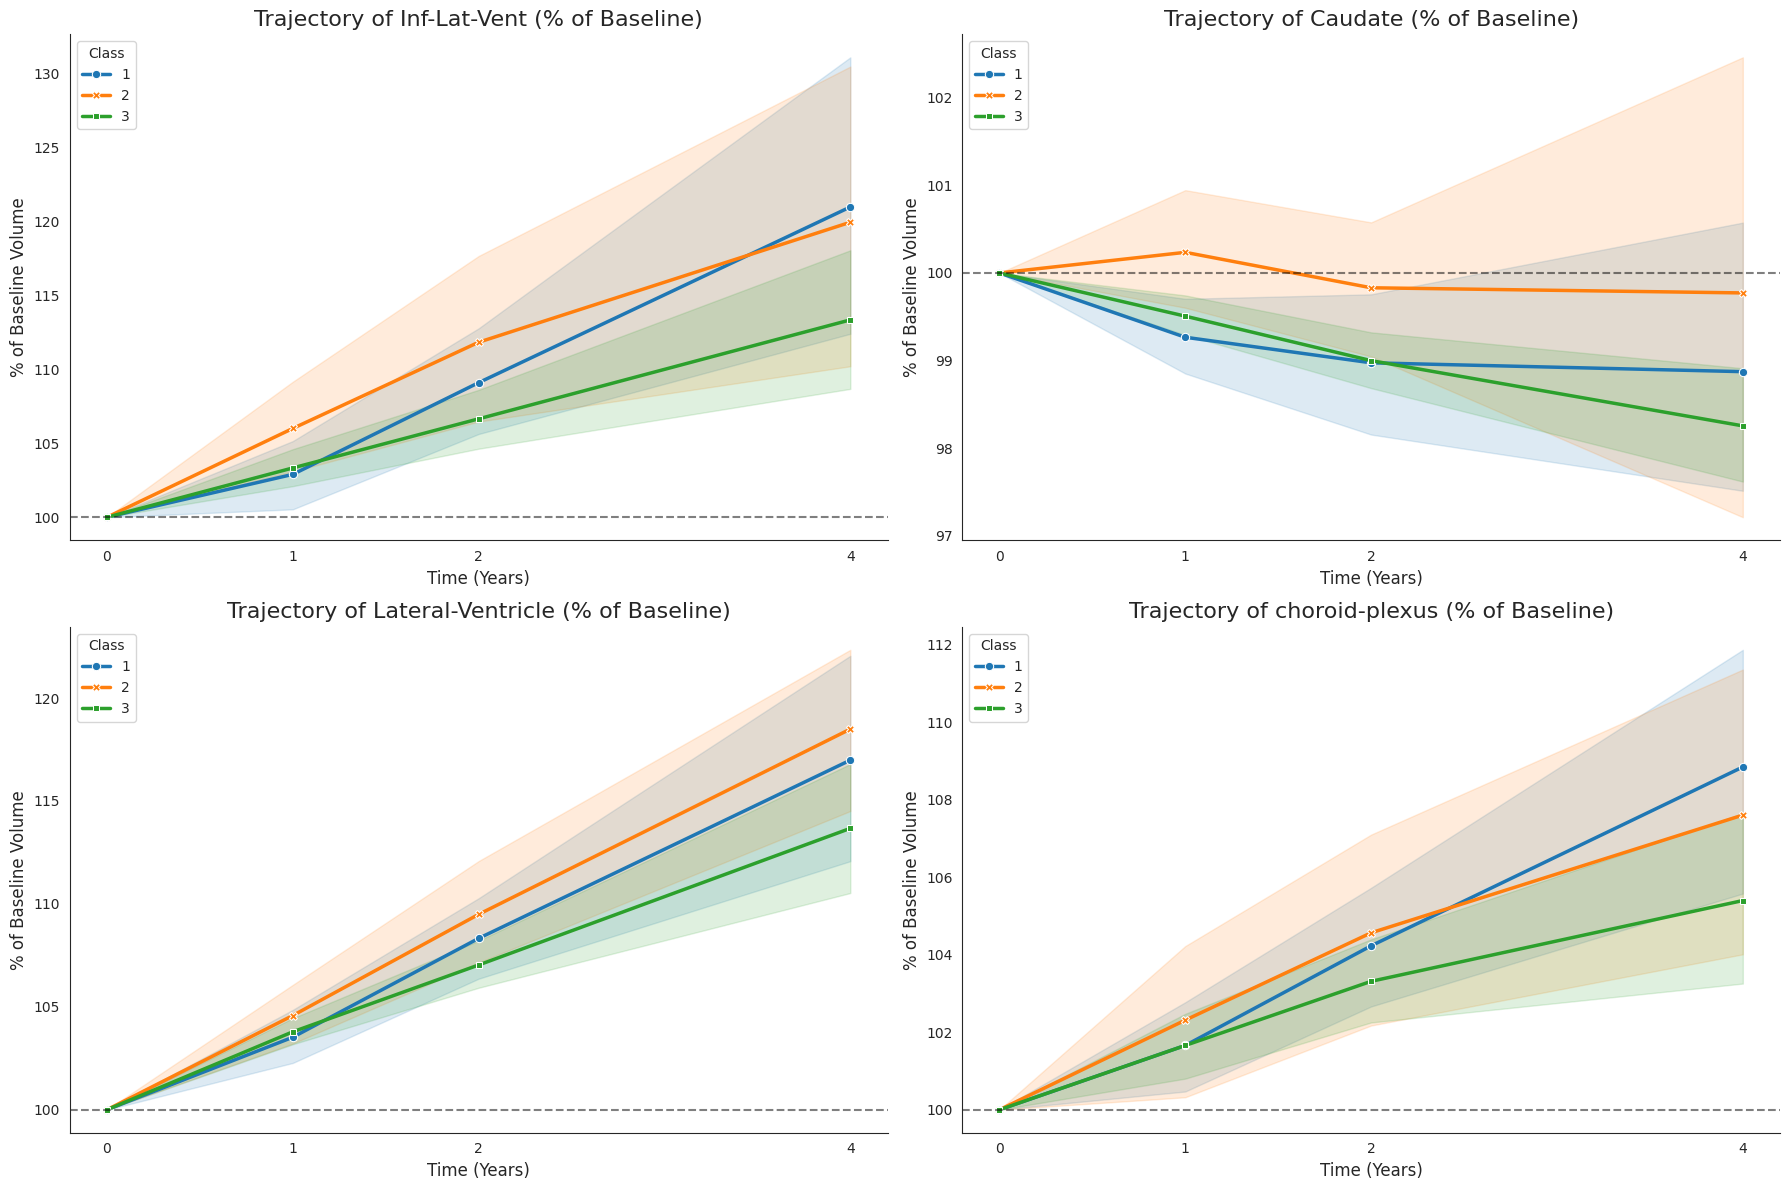

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import rpy2.robjects as ro

# 1. Extract class assignments from the R model into Python
with (ro.default_converter + ro.pandas2ri.converter).context():
    pp_m3 = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))

pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)

# 2. Define the 4 target regions
target_regions = ['Inf-Lat-Vent', 'Caudate', 'Lateral-Ventricle', 'choroid-plexus']

# 3. Prepare the plotting data (Normalize by MaskVol and then % of baseline)
df_plot_data = fs_data[['PATNO', 'EVENT_ID', 'MaskVol']].copy()
for region in target_regions:
    avg_vol = (fs_data[f'Left-{region}'] + fs_data[f'Right-{region}']) / 2
    df_plot_data[region] = avg_vol / fs_data['MaskVol']

# Merge with class and YEAR
df_plot_data = df_plot_data.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')
df_plot_data = df_plot_data.merge(df_years, on=['PATNO', 'EVENT_ID'], how='inner')

# Calculate % of baseline per subject
def get_pct_of_bl(group):
    group = group.sort_values('YEAR')
    bl_row = group[group['YEAR'] == 0]
    if not bl_row.empty:
        for region in target_regions:
            bl_val = bl_row[region].values[0]
            if bl_val > 0:
                group[f'{region}_pct'] = (group[region] / bl_val) * 100
            else:
                group[f'{region}_pct'] = np.nan
    else:
        for region in target_regions:
            group[f'{region}_pct'] = np.nan
    return group

# Updated to silence DeprecationWarning and handle grouping columns explicitly
df_plot_data = df_plot_data.groupby('PATNO', group_keys=False).apply(get_pct_of_bl, include_groups=False).reset_index()

# 4. Filter for robust timepoints
robust_years = [0.0, 1.0, 2.0, 4.0]
df_plot_clean = df_plot_data[df_plot_data['YEAR'].isin(robust_years)].copy()

# 5. Plotting
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, region in enumerate(target_regions):
    sns.lineplot(data=df_plot_clean, x='YEAR', y=f'{region}_pct', hue='class',
                 style='class', markers=True, dashes=False, palette='tab10',
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[i])

    axes[i].set_title(f"Trajectory of {region} (% of Baseline)", fontsize=16)
    axes[i].set_xlabel("Time (Years)", fontsize=12)
    axes[i].set_ylabel("% of Baseline Volume", fontsize=12)
    axes[i].set_xticks(robust_years)
    axes[i].axhline(100, ls='--', color='black', alpha=0.5)
    axes[i].legend(title='Class')
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Learn more about the underlying theory at https://ggplot2-book.org/

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



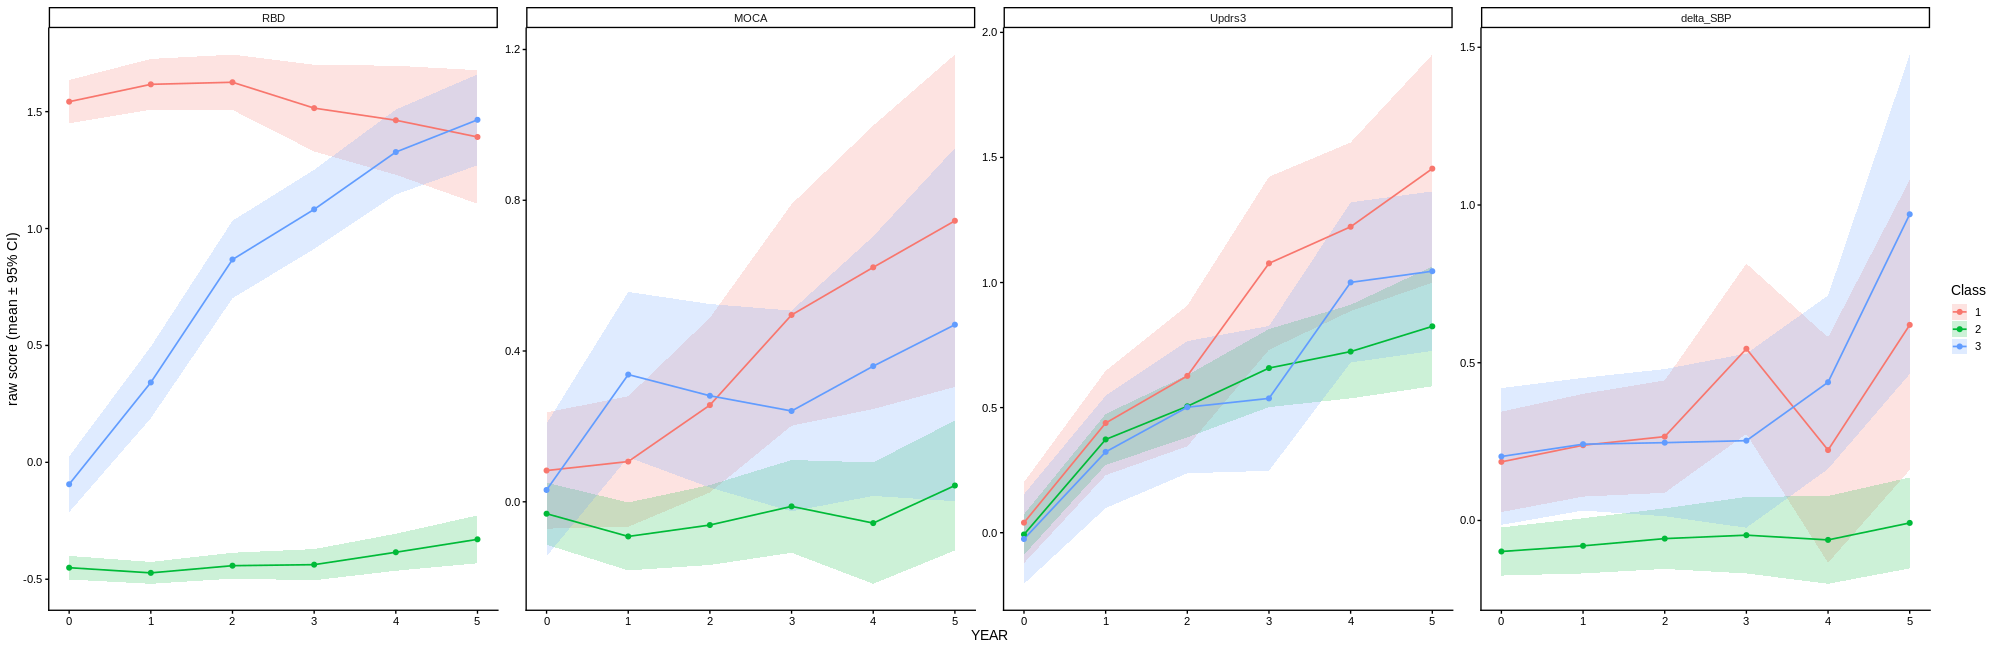

In [ ]:
%%R -w 2000 -h 650

library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)

pp <- read_csv("/content/drive/MyDrive/data/m3_rmus_intercept_z_bl_trans_linear_postprob.csv")

pp$class <- factor(pp$class)

pp$PATNO <- as.numeric(pp$PATNO)
df$PATNO <- as.numeric(df$PATNO)

d <- df %>%
  select(PATNO, YEAR, z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp) %>%
  left_join(pp %>% select(PATNO, class), by = "PATNO")

table(is.na(d$class))

long <- d %>%
  pivot_longer(
    cols = c(z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp),
    names_to = "domain",
    values_to = "value"
  ) %>%
  mutate(
    domain = recode(
      domain,
      z_bl_rem = "RBD",
      z_bl_trans_moca = "MOCA",
      z_bl_updrs3_score = "Updrs3",
      z_bl_delta_sbp = "delta_SBP"
    ),
    domain = factor(domain, levels = c("RBD", "MOCA", "Updrs3", "delta_SBP"))
  )

plot_df <- long %>%
  group_by(class, YEAR, domain) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    n    = sum(!is.na(value)),
    se   = sd / sqrt(n),
    ci_low  = mean - 1.96 * se,
    ci_high = mean + 1.96 * se,
    .groups = "drop"
  )

ggplot(plot_df, aes(x = YEAR, y = mean, color = class, group = class, fill = class)) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.20, colour = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~domain, nrow = 1, scales = "free_y") +
  labs(
    x = "YEAR",
    y = "raw score (mean ± 95% CI)",
    color = "Class",
    fill  = "Class"
  ) + theme_classic(base_size = 14)

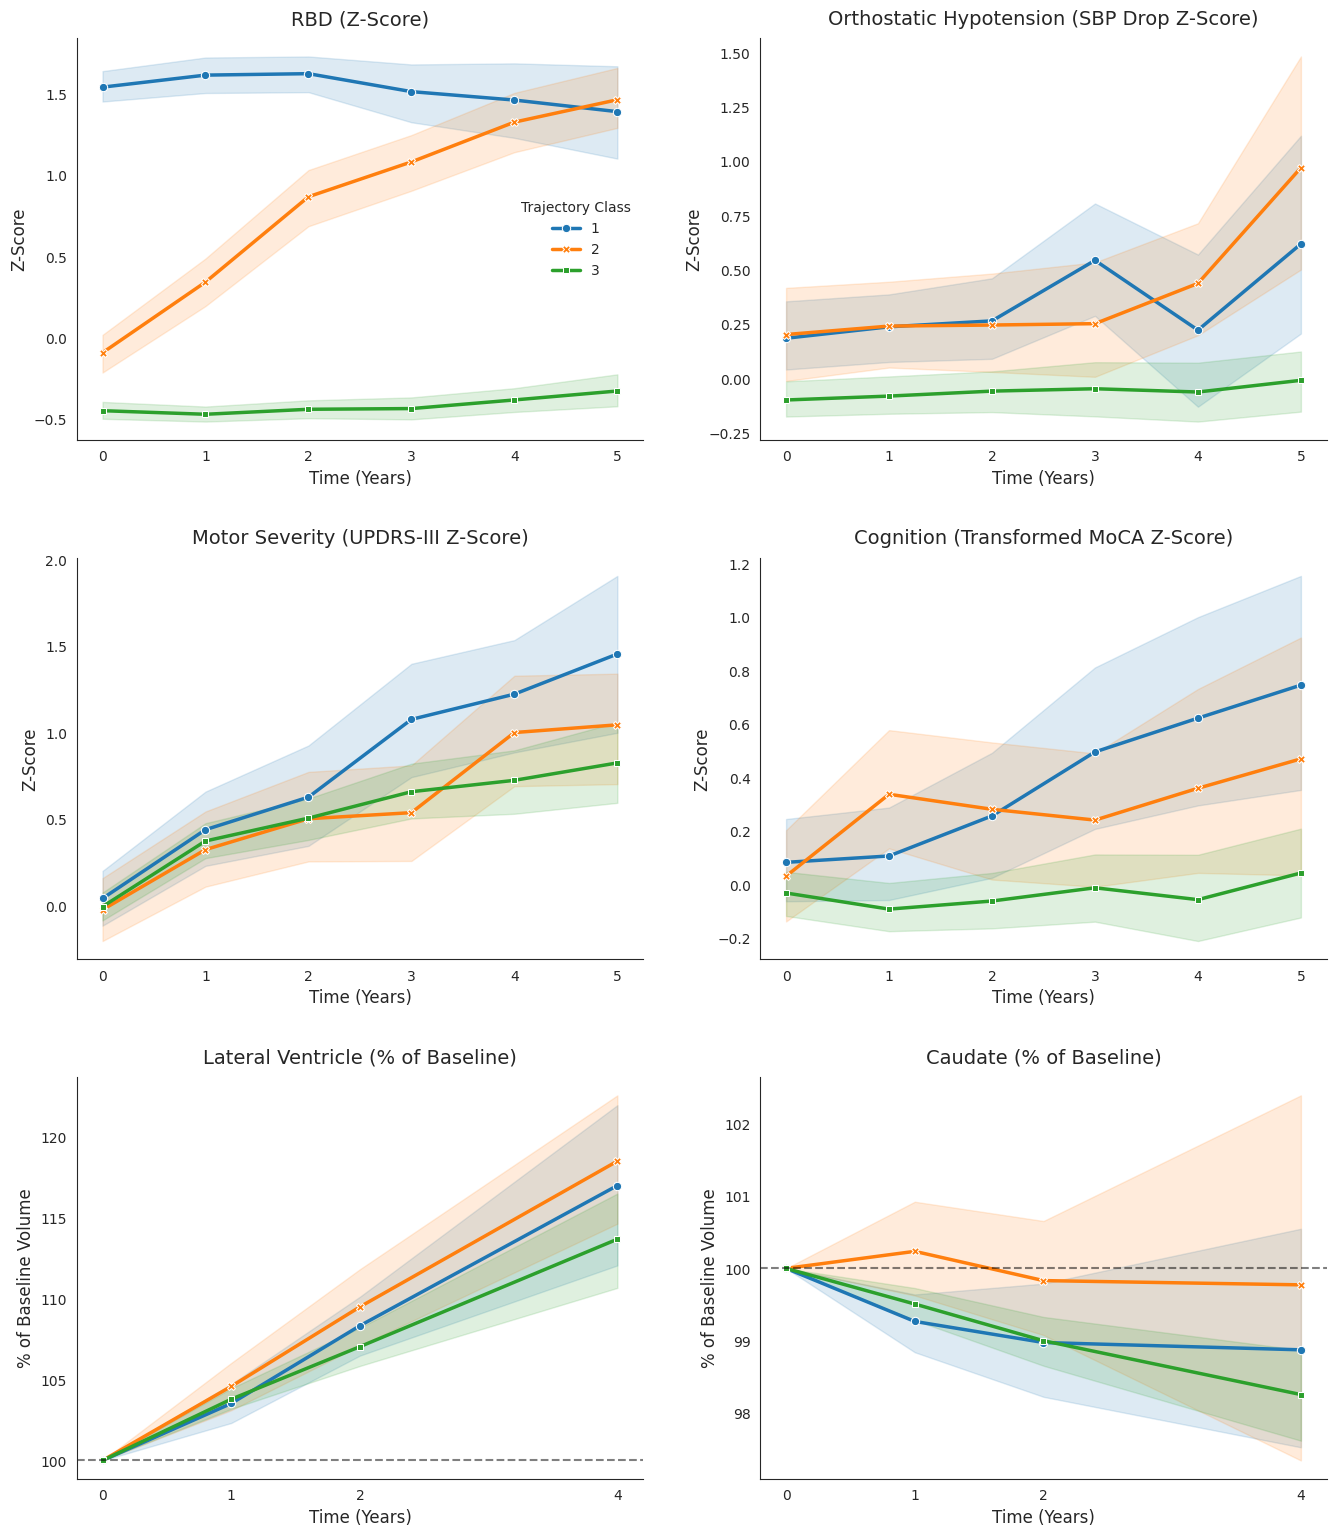

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Ensure consistent class types (strings for categorical plotting)
pp_m3['class'] = pp_m3['class'].astype(int).astype(str)
df_plot_clean['class'] = df_plot_clean['class'].astype(int).astype(str)

# 2. Prepare Clinical Data
# We map the clinical variables from df_pd_final to the permuted classes
clinical_vars = {
    'z_bl_rem': 'RBD (Z-Score)',
    'z_bl_delta_sbp': 'Orthostatic Hypotension (SBP Drop Z-Score)',
    'z_bl_updrs3_score': 'Motor Severity (UPDRS-III Z-Score)',
    'z_bl_trans_moca': 'Cognition (Transformed MoCA Z-Score)'
}

# Merge clinical features with consistent, permuted class assignments
df_clinical = df_pd_final[['PATNO', 'YEAR'] + list(clinical_vars.keys())].copy()
df_clinical = df_clinical.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')

# 3. Setup the 3x2 Figure
sns.set_style("white")
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

# Define consistent color palette and order
hue_order = ['1', '2', '3']
palette = sns.color_palette("tab10", n_colors=3)

# 4. Plot Clinical variables (Top 2 rows = 4 panels)
for i, (col, title) in enumerate(clinical_vars.items()):
    sns.lineplot(data=df_clinical, x='YEAR', y=col, hue='class', style='class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[i], legend=(i==0))

    axes[i].set_title(title, fontsize=14, pad=10)
    axes[i].set_xlabel("Time (Years)", fontsize=12)
    axes[i].set_ylabel("Z-Score", fontsize=12)
    axes[i].set_xticks([0, 1, 2, 3, 4, 5])
    sns.despine(ax=axes[i])

    if i == 0:
        axes[i].legend(title='Trajectory Class', frameon=False)

# 5. Plot MRI variables (Bottom row = 2 panels)
mri_vars = {
    'Lateral-Ventricle_pct': 'Lateral Ventricle (% of Baseline)',
    'Caudate_pct': 'Caudate (% of Baseline)'
}

robust_years = [0.0, 1.0, 2.0, 4.0]

for j, (col, title) in enumerate(mri_vars.items()):
    ax_idx = j + 4
    sns.lineplot(data=df_plot_clean, x='YEAR', y=col, hue='class', style='class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[ax_idx], legend=False)

    axes[ax_idx].set_title(title, fontsize=14, pad=10)
    axes[ax_idx].set_xlabel("Time (Years)", fontsize=12)
    axes[ax_idx].set_ylabel("% of Baseline Volume", fontsize=12)
    axes[ax_idx].set_xticks(robust_years)
    axes[ax_idx].axhline(100, ls='--', color='black', alpha=0.5)
    sns.despine(ax=axes[ax_idx])

plt.tight_layout(pad=3.0)
plt.show()

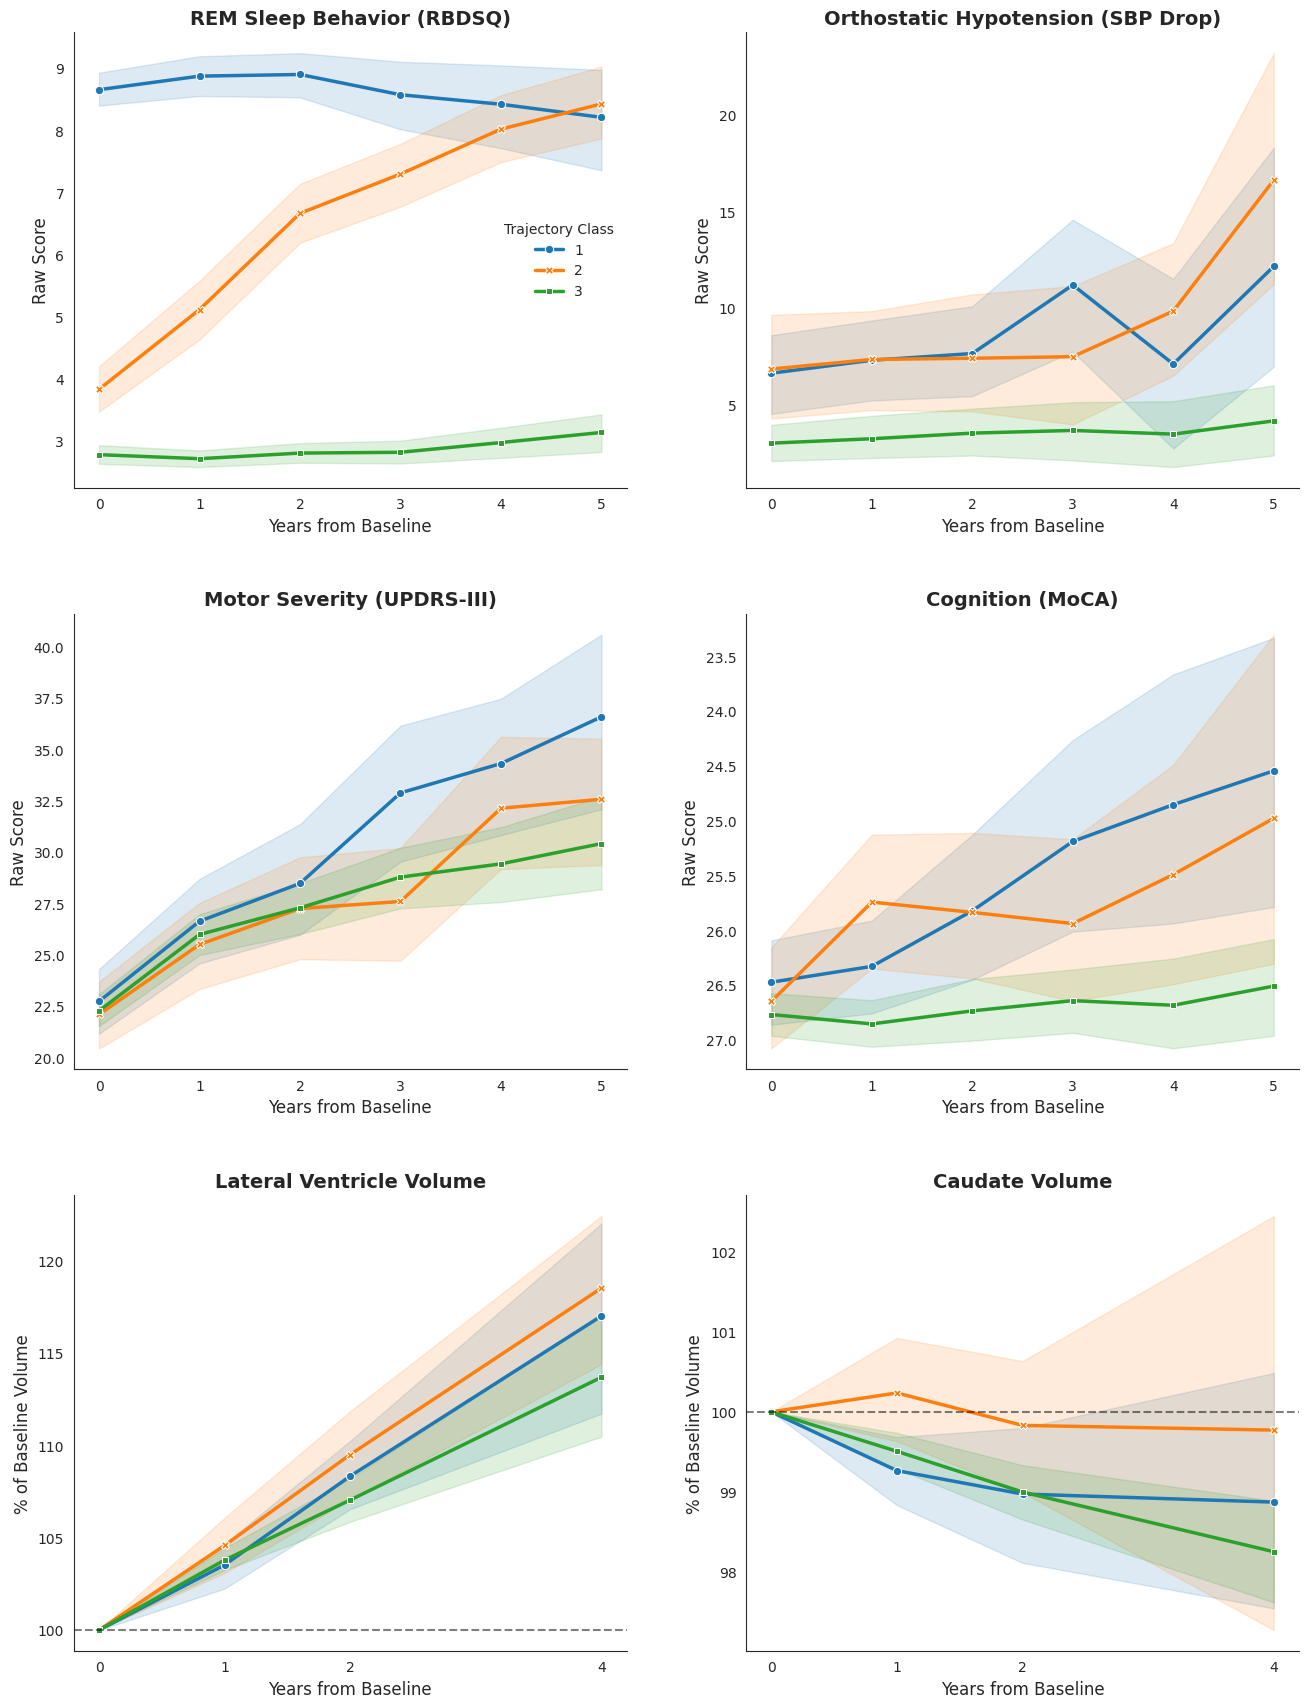

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import rpy2.robjects as ro

# 1. Get consistent class assignments and metadata
with (ro.default_converter + ro.pandas2ri.converter).context():
    pp_m3 = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))

pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)
pp_m3['class'] = pp_m3['class'].astype(int).astype(str)

# 2. Prepare RAW Clinical Data
clinical_vars_raw = {
    'rem': 'REM Sleep Behavior (RBDSQ)',
    'delta_sbp': 'Orthostatic Hypotension (SBP Drop)',
    'updrs3_score': 'Motor Severity (UPDRS-III)',
    'moca': 'Cognition (MoCA)'
}

df_clinical_raw = df_pd_final[['PATNO', 'YEAR'] + list(clinical_vars_raw.keys())].copy()
df_clinical_raw = df_clinical_raw.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')

# 3. Prepare MRI Data as % of Baseline
target_mri = ['Lateral-Ventricle', 'Caudate']
df_mri_pct = fs_data[['PATNO', 'EVENT_ID', 'MaskVol']].copy()
for region in target_mri:
    avg_vol = (fs_data[f'Left-{region}'] + fs_data[f'Right-{region}']) / 2
    df_mri_pct[region] = avg_vol / fs_data['MaskVol']

df_mri_pct = df_mri_pct.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')
df_mri_pct = df_mri_pct.merge(df_years, on=['PATNO', 'EVENT_ID'], how='inner')

def get_pct_of_bl(group):
    group = group.sort_values('YEAR')
    bl_row = group[group['YEAR'] == 0]
    if not bl_row.empty:
        for region in target_mri:
            bl_val = bl_row[region].values[0]
            if bl_val > 0:
                group[f'{region}_pct'] = (group[region] / bl_val) * 100
            else:
                group[f'{region}_pct'] = np.nan
    else:
        for region in target_mri:
            group[f'{region}_pct'] = np.nan
    return group

df_mri_pct = df_mri_pct.groupby('PATNO', group_keys=False).apply(get_pct_of_bl, include_groups=False).reset_index()
robust_years = [0.0, 1.0, 2.0, 4.0]
df_mri_clean = df_mri_pct[df_mri_pct['YEAR'].isin(robust_years)].copy()
df_mri_clean['class'] = df_mri_clean['class'].astype(str)

# 4. Create the 3x2 Unified Figure
sns.set_style("white")
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten()

hue_order = ['1', '2', '3']
palette = sns.color_palette("tab10", n_colors=3)

# A. Plot Clinical Raw Scores
for i, (col, title) in enumerate(clinical_vars_raw.items()):
    sns.lineplot(data=df_clinical_raw, x='YEAR', y=col, hue='class', style='class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[i], legend=(i==0))
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Years from Baseline", fontsize=12)
    axes[i].set_ylabel("Raw Score", fontsize=12)
    axes[i].set_xticks([0, 1, 2, 3, 4, 5])

    # INVERT Y-AXIS SPECIFICALLY FOR MOCA
    if col == 'moca':
        axes[i].invert_yaxis()

    sns.despine(ax=axes[i])
    if i == 0:
        # Updated legend handling to match previous stable method
        axes[i].legend(title='Trajectory Class', frameon=False)

# B. Plot MRI % of Baseline
mri_vars = ['Lateral-Ventricle_pct', 'Caudate_pct']
mri_labels = ['Lateral Ventricle', 'Caudate']
for j, col in enumerate(mri_vars):
    ax_idx = j + 4
    sns.lineplot(data=df_mri_clean, x='YEAR', y=col, hue='class', style='class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[ax_idx], legend=False)
    axes[ax_idx].set_title(mri_labels[j] + " Volume", fontsize=14, fontweight='bold')
    axes[ax_idx].set_xlabel("Years from Baseline", fontsize=12)
    axes[ax_idx].set_ylabel("% of Baseline Volume", fontsize=12)
    axes[ax_idx].set_xticks(robust_years)
    axes[ax_idx].axhline(100, ls='--', color='black', alpha=0.5)
    sns.despine(ax=axes[ax_idx])

plt.tight_layout(pad=4.0)
plt.show()

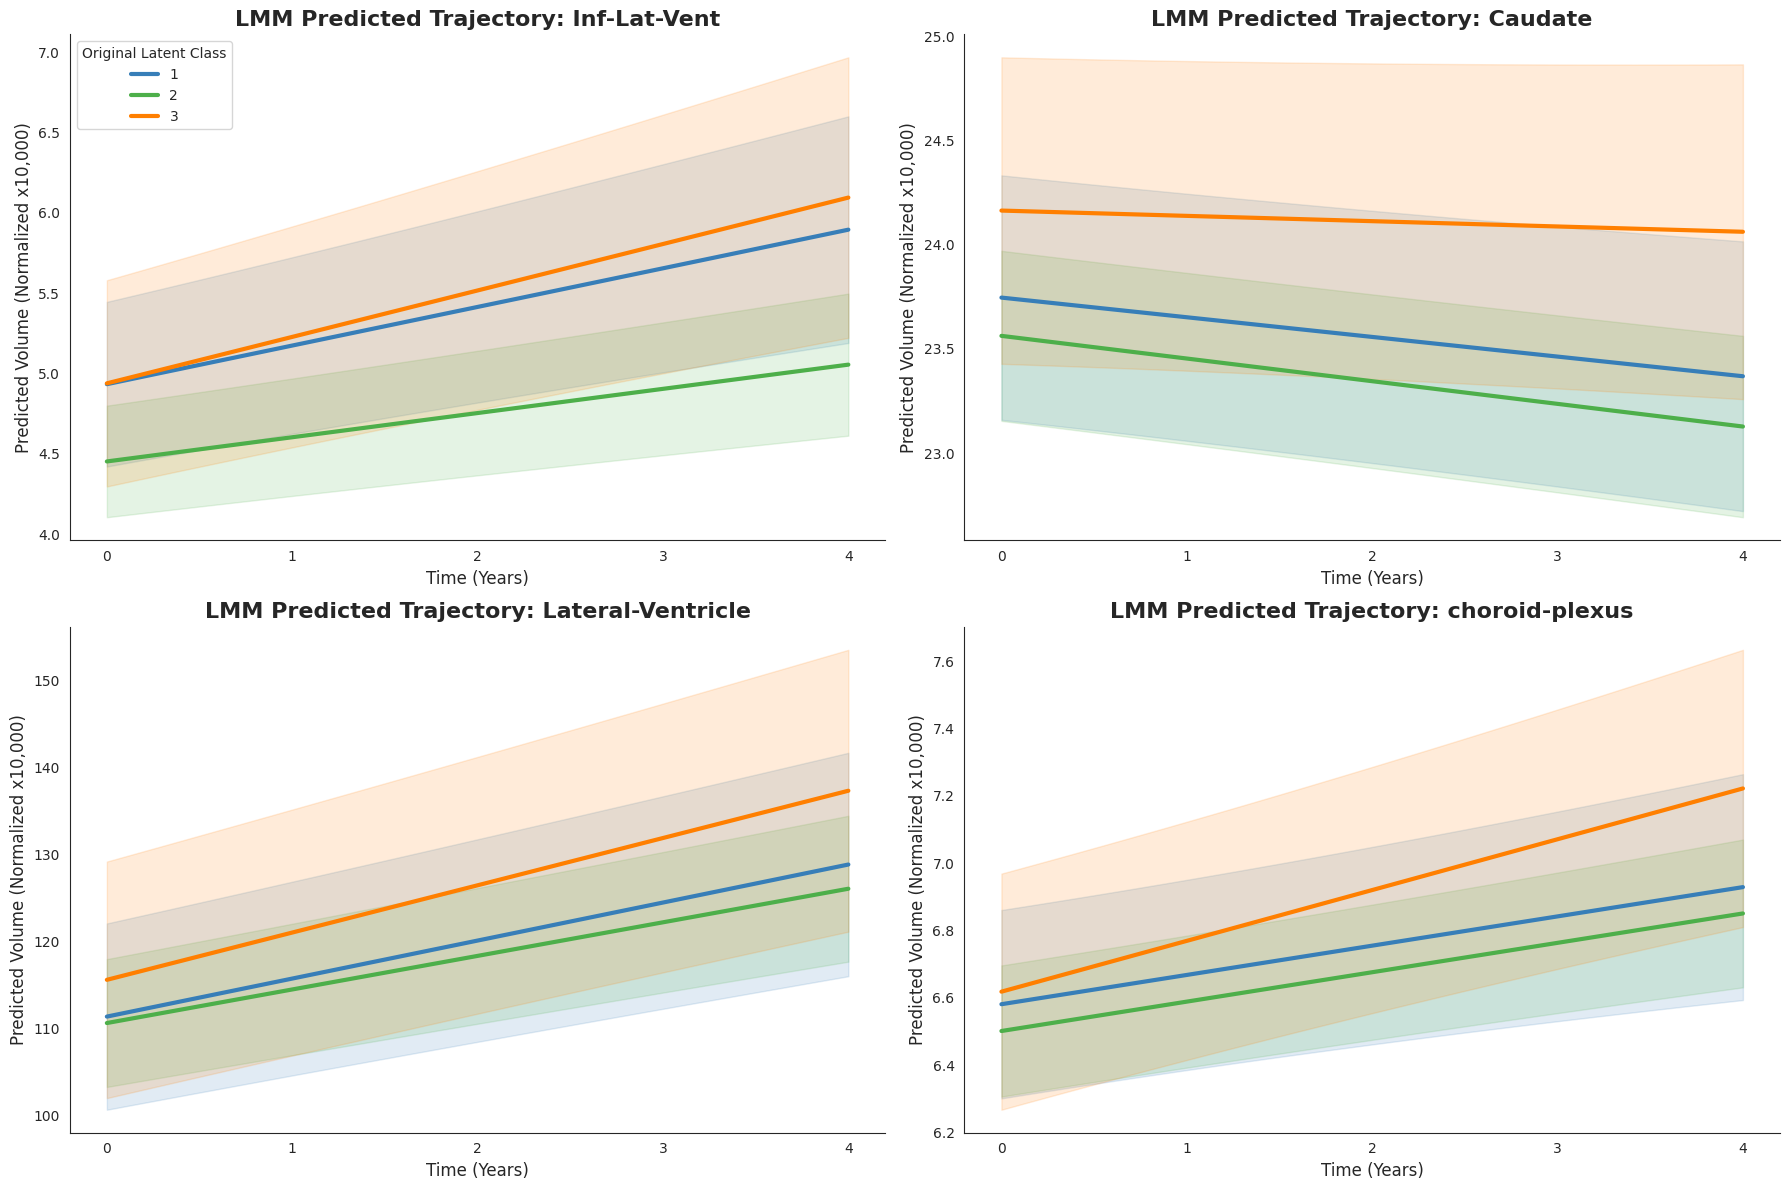

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rpy2.robjects as ro

# 1. Generate predictions in R for all 4 models
ro.r("""
library(lcmm)
new_data <- expand.grid(
    YEAR = seq(0, 4, length.out = 100),
    class = factor(c("1", "2", "3")),
    age_bl = mean(df_lmm_raw$age_bl, na.rm = TRUE),
    sex = factor("1", levels = c("0", "1"))
)

get_preds <- function(model, region_name) {
    pred <- predictY(model, new_data, var.time = "YEAR", draws = TRUE)
    df <- cbind(new_data, pred$pred)
    df$Region <- region_name
    return(df)
}

pred_inf_lat_vent <- get_preds(model_Inf_Lat_Vent, 'Inf-Lat-Vent')
pred_caudate <- get_preds(model_Caudate, 'Caudate')
pred_lat_vent <- get_preds(model_Lateral_Ventricle, 'Lateral-Ventricle')
pred_choroid <- get_preds(model_choroid_plexus, 'choroid-plexus')

all_preds <- rbind(pred_inf_lat_vent, pred_caudate, pred_lat_vent, pred_choroid)
""")

# 2. Pull predictions back into Python
with (ro.default_converter + ro.pandas2ri.converter).context():
    df_preds = ro.conversion.get_conversion().rpy2py(ro.r("all_preds"))

# --- RELABEL CLASSES TO UNPERMUTED ORIGINALS ---
# Model Class 1 -> Original Class 1
# Model Class 2 -> Original Class 3
# Model Class 3 -> Original Class 2
class_map = {'1': '1', '2': '3', '3': '2'}
df_preds['orig_class'] = df_preds['class'].astype(str).map(class_map)

# 3. Setup the 2x2 Figure
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

target_regions = ['Inf-Lat-Vent', 'Caudate', 'Lateral-Ventricle', 'choroid-plexus']

# Reverting to the preferred color scheme:
# Class 3 (Fastest) in Orange
palette_dict = {
    '1': '#377eb8', # Blue
    '2': '#4daf4a', # Green
    '3': '#ff7f00'  # Orange (Distinctive for Class 3)
}
hue_order = ['1', '2', '3']

# 4. Plotting
for i, region in enumerate(target_regions):
    data = df_preds[df_preds['Region'] == region]

    # Plot central lines
    sns.lineplot(data=data, x='YEAR', y='Ypred', hue='orig_class',
                 palette=palette_dict, hue_order=hue_order, linewidth=3, ax=axes[i], legend=(i==0))

    # Plot confidence bands manually
    for cls in hue_order:
        cls_data = data[data['orig_class'] == cls]
        axes[i].fill_between(cls_data['YEAR'], cls_data['lower.Ypred'], cls_data['upper.Ypred'],
                             color=palette_dict[cls], alpha=0.15)

    axes[i].set_title(f"LMM Predicted Trajectory: {region}", fontsize=16, fontweight='bold')
    axes[i].set_xlabel("Time (Years)", fontsize=12)
    axes[i].set_ylabel("Predicted Volume (Normalized x10,000)", fontsize=12)
    axes[i].set_xticks([0, 1, 2, 3, 4])
    sns.despine(ax=axes[i])

axes[0].legend(title='Original Latent Class', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## Boxplots



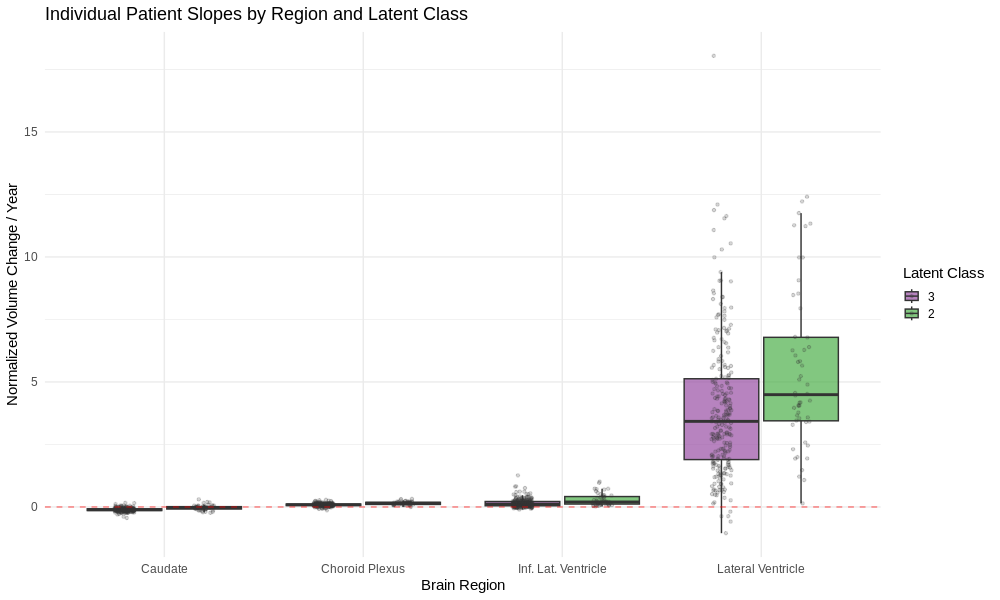

In [ ]:
%%R -w 1000 -h 600 -u px
library(ggplot2)
library(dplyr)

# Function to extract Individual Subject Slopes
extract_slopes <- function(model_obj, region_name) {
  b <- model_obj$best
  slope_ref <- b["YEAR"]
  slope_diff_c1 <- b["class1:YEAR"]
  slope_diff_c2 <- b["class2:YEAR"]

  re <- model_obj$predRE
  names(re)[which(names(re) == "YEAR")] <- "Random_Slope"

  classes <- unique(df_lmm_raw[, c("PATNO", "class")])
  dat <- merge(re, classes, by="PATNO")

  dat$Fixed_Slope <- ifelse(dat$class == "3", slope_ref,
                     ifelse(dat$class == "1", slope_ref + slope_diff_c1,
                            slope_ref + slope_diff_c2))

  dat$Total_Slope <- dat$Fixed_Slope + dat$Random_Slope
  dat$Region <- region_name

  return(dat)
}

# Extract slopes
slopes_caudate <- extract_slopes(model_Caudate, "Caudate")
slopes_ilv <- extract_slopes(model_Inf_Lat_Vent, "Inf. Lat. Ventricle")
slopes_lv <- extract_slopes(model_Lateral_Ventricle, "Lateral Ventricle")
slopes_choroid <- extract_slopes(model_choroid_plexus, "Choroid Plexus")

df_all_slopes <- rbind(slopes_caudate, slopes_ilv, slopes_lv, slopes_choroid)

# Filter to compare Class 2 vs Class 3
df_plot <- df_all_slopes %>%
  filter(class %in% c("2", "3")) %>%
  mutate(Region_Class = paste(Region, "\nClass", class))

# Plot the distribution of individual slopes in one continuous plot
ggplot(df_plot, aes(x = Region, y = Total_Slope, fill = class)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA, position = position_dodge(width = 0.8)) +
  geom_jitter(aes(group = class), position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8),
              alpha = 0.2, size = 1.2, color="#333333") +
  theme_minimal(base_size = 15) +
  labs(title = "Individual Patient Slopes by Region and Latent Class",
       y = "Normalized Volume Change / Year",
       x = "Brain Region",
       fill = "Latent Class") +
  scale_fill_manual(values = c("2" = "#4daf4a", "3" = "#984ea3")) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", alpha = 0.5) +
  theme(legend.position = "right",
        axis.text.x = element_text(angle = 0, hjust = 0.5))

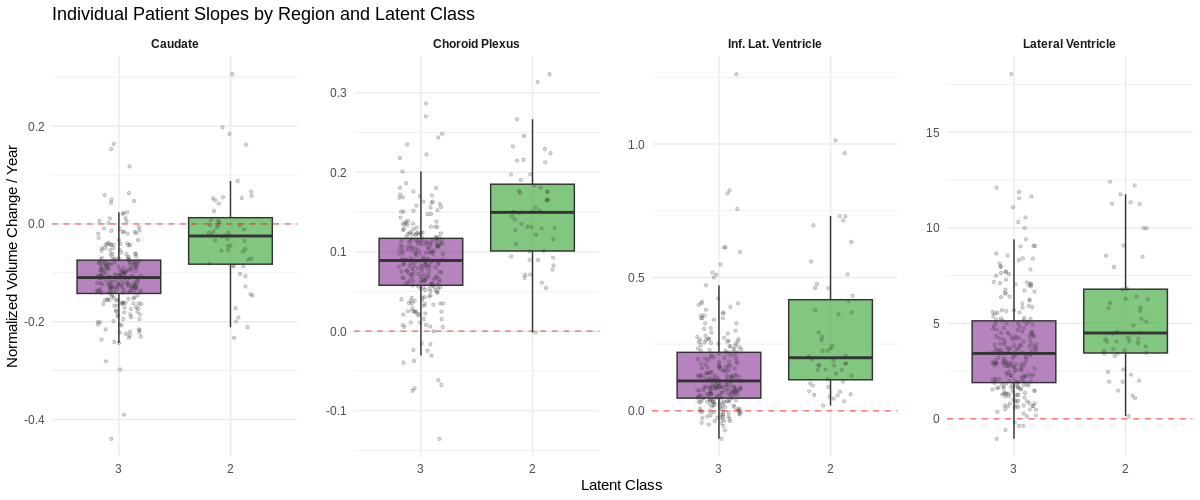

In [ ]:
%%R -w 1200 -h 500 -u px
library(ggplot2)
library(dplyr)

# Using the df_all_slopes dataframe already created in the previous cell
df_plot <- df_all_slopes %>%
  filter(class %in% c("2", "3"))

# Create faceted plot with free y-scales
ggplot(df_plot, aes(x = class, y = Total_Slope, fill = class)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA) +
  geom_jitter(alpha = 0.2, size = 1.2, color="#333333", width = 0.2) +
  facet_wrap(~Region, scales = "free_y", nrow = 1) +
  theme_minimal(base_size = 15) +
  labs(title = "Individual Patient Slopes by Region and Latent Class",
       y = "Normalized Volume Change / Year",
       x = "Latent Class",
       fill = "Latent Class") +
  scale_fill_manual(values = c("2" = "#4daf4a", "3" = "#984ea3")) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", alpha = 0.5) +
  theme(legend.position = "none",
        panel.spacing = unit(2, "lines"),
        strip.text = element_text(face = "bold"))

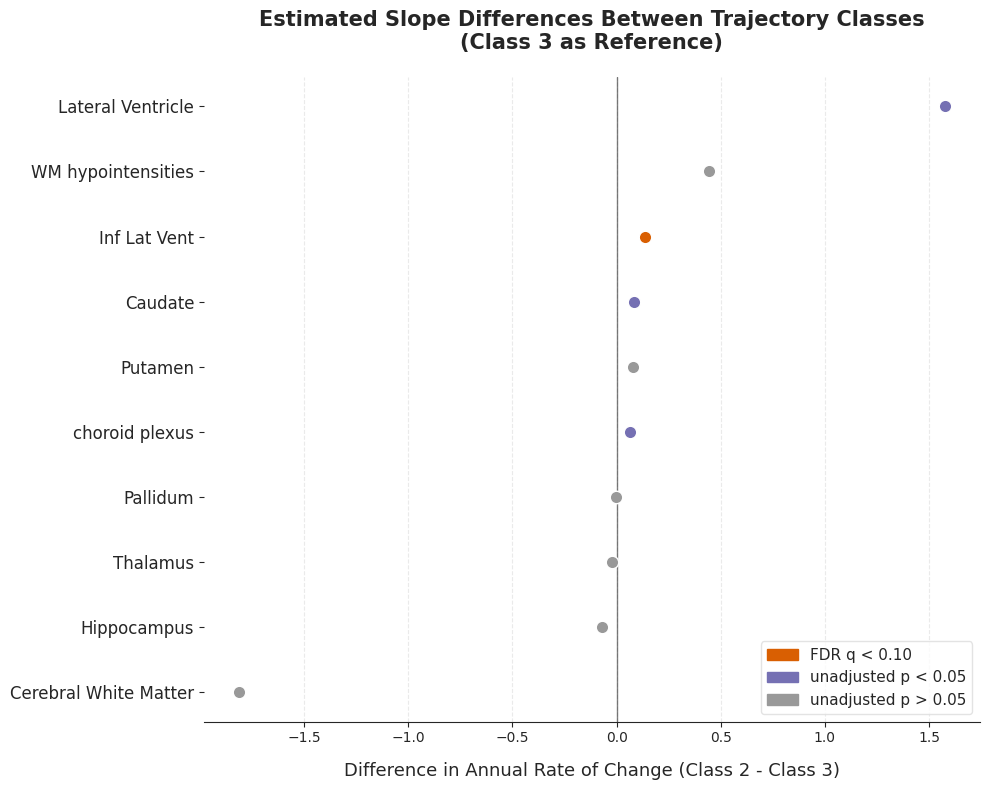

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Robust extraction of estimates and standard errors from R models
# We ensure SE extraction handles the internal structure of hlme objects correctly
ro.r("""
regions <- c('Thalamus', 'Caudate', 'Putamen', 'Hippocampus', 'choroid_plexus',
             'Pallidum', 'Lateral_Ventricle', 'Inf_Lat_Vent',
             'Cerebral_White_Matter', 'WM_hypointensities')

results <- data.frame(Region=character(), Estimate=numeric(), SE=numeric(), stringsAsFactors=FALSE)

for (reg in regions) {
  mod_name <- paste0("model_", reg)
  if (exists(mod_name)) {
    mod <- get(mod_name)
    # Extract coefficients and SEs from the variance-covariance matrix
    coefs <- mod$best
    ses <- sqrt(abs(diag(mod$V)))

    if ("class2:YEAR" %in% names(coefs)) {
        results <- rbind(results, data.frame(
            Region = reg,
            Estimate = as.numeric(coefs["class2:YEAR"]),
            SE = as.numeric(ses["class2:YEAR"]),
            stringsAsFactors = FALSE
        ))
    }
  }
}
""")

# Pull the results back to Python
with (ro.default_converter + ro.pandas2ri.converter).context():
    df_forest = ro.conversion.get_conversion().rpy2py(ro.r("results"))

# 2. Merge with p-values
df_forest = df_forest.merge(df_pvals_fdr[['Region', 'P_Class2_vs_3_YEAR', 'FDR_P_Class2']], on='Region', how='left')

# 3. Calculate 95% Confidence Intervals (1.96 * SE)
df_forest['CI_lower'] = df_forest['Estimate'] - 1.96 * df_forest['SE']
df_forest['CI_upper'] = df_forest['Estimate'] + 1.96 * df_forest['SE']

# Clean region names for display
df_forest['Region'] = df_forest['Region'].str.replace('_', ' ')
# Sort by effect size for a professional 'waterfall' presentation
df_forest = df_forest.sort_values('Estimate', ascending=True).reset_index(drop=True)

# 4. Professional Plotting
plt.figure(figsize=(10, 8))
sns.set_style("ticks")

# Define color palette
color_fdr = '#d95f02'   # Orange
color_unadj = '#7570b3' # Purple
color_ns = '#999999'    # Gray

colors = []
for _, row in df_forest.iterrows():
    if row['FDR_P_Class2'] < 0.10: colors.append(color_fdr)
    elif row['P_Class2_vs_3_YEAR'] < 0.05: colors.append(color_unadj)
    else: colors.append(color_ns)

for i, row in df_forest.iterrows():
    # Plot the 95% CI using errorbar for better visibility
    plt.errorbar(row['Estimate'], i, xerr=[[row['Estimate'] - row['CI_lower']], [row['CI_upper'] - row['Estimate']]],
                 fmt='o', color=colors[i], markersize=9, markeredgecolor='white', markeredgewidth=1, linewidth=2.5, capsize=5)

# Refined Formatting
plt.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.yticks(range(len(df_forest)), df_forest['Region'], fontsize=12, fontweight='medium')
plt.xlabel('Difference in Annual Rate of Change (Class 2 - Class 3)', fontsize=13, labelpad=12)
plt.title('Estimated Slope Differences Between Trajectory Classes\n(Class 3 as Reference)', fontsize=15, pad=20, fontweight='bold')

# Legend without stars
fdr_patch = mpatches.Patch(color=color_fdr, label='FDR q < 0.10')
unadj_patch = mpatches.Patch(color=color_unadj, label='unadjusted p < 0.05')
ns_patch = mpatches.Patch(color=color_ns, label='unadjusted p > 0.05')

plt.legend(handles=[fdr_patch, unadj_patch, ns_patch], loc='lower right',
           fontsize=11, frameon=True, facecolor='white', edgecolor='#dddddd')

sns.despine(left=True, bottom=False)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


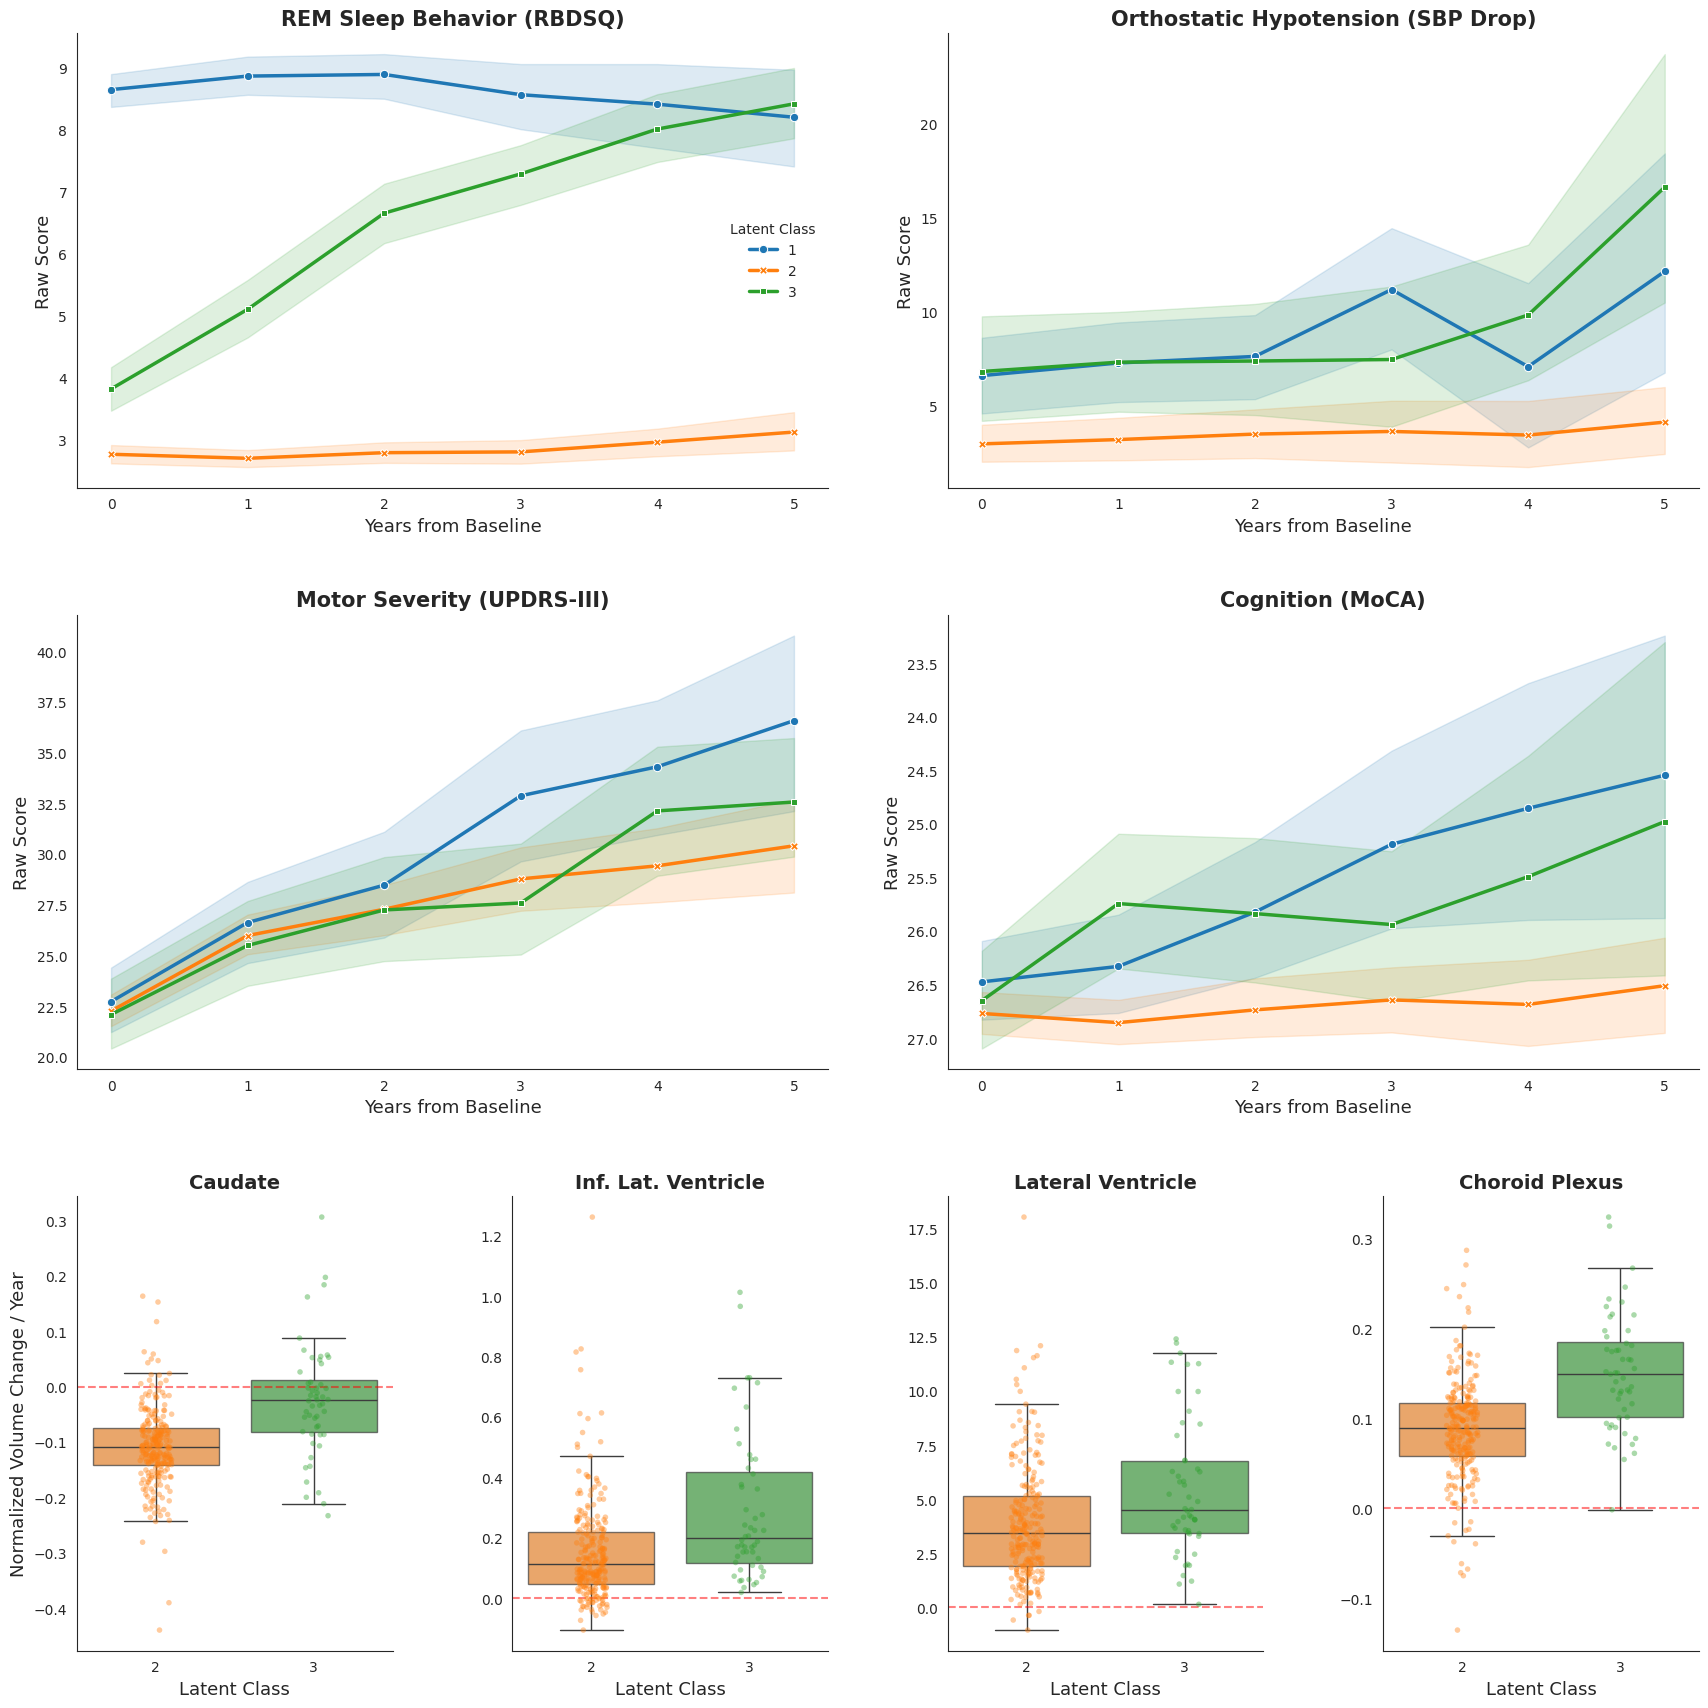

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import rpy2.robjects as ro

# 1. Map classes back to unpermuted originals
# The permuted model used: c(1, 3, 2), which means:
# Permuted 1 -> Original 1
# Permuted 2 -> Original 3
# Permuted 3 -> Original 2 (Reference class)
class_map = {'1': '1', '2': '3', '3': '2'}

# 2. Prepare Clinical Data
clinical_vars_raw = {
    'rem': 'REM Sleep Behavior (RBDSQ)',
    'delta_sbp': 'Orthostatic Hypotension (SBP Drop)',
    'updrs3_score': 'Motor Severity (UPDRS-III)',
    'moca': 'Cognition (MoCA)'
}

# Extract class assignments from R
with (ro.default_converter + ro.pandas2ri.converter).context():
    pp_m3 = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))
pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)

df_clinical_raw = df_pd_final[['PATNO', 'YEAR'] + list(clinical_vars_raw.keys())].copy()
df_clinical_raw = df_clinical_raw.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')

df_clinical_plot = df_clinical_raw.copy()
df_clinical_plot['orig_class'] = df_clinical_plot['class'].astype(str).map(class_map)

# 3. Prepare Boxplot Data from R
with (ro.default_converter + ro.pandas2ri.converter).context():
    df_all_slopes = ro.conversion.get_conversion().rpy2py(ro.r("df_all_slopes"))

df_all_slopes['orig_class'] = df_all_slopes['class'].astype(str).map(class_map)

# Filter for the non-reference vs reference (Original Class 3 vs Original Class 2)
df_box_plot = df_all_slopes[df_all_slopes['orig_class'].isin(['2', '3'])].copy()

# 4. Setup Unified Figure
sns.set_style("white")
fig = plt.figure(figsize=(18, 18))
gs = fig.add_gridspec(3, 4)

ax1 = fig.add_subplot(gs[0, 0:2]) # REM
ax2 = fig.add_subplot(gs[0, 2:4]) # SBP
ax3 = fig.add_subplot(gs[1, 0:2]) # UPDRS3
ax4 = fig.add_subplot(gs[1, 2:4]) # MOCA

axes_clin = [ax1, ax2, ax3, ax4]

# Shared color palette mapped to original classes
base_palette = sns.color_palette("tab10", n_colors=3)
palette_dict = {'1': base_palette[0], '2': base_palette[1], '3': base_palette[2]}
hue_order = ['1', '2', '3']
box_hue_order = ['2', '3'] # This ensures 2 comes before 3

# --- A. Plot Clinical Trajectories ---
for i, (col, title) in enumerate(clinical_vars_raw.items()):
    ax = axes_clin[i]
    sns.lineplot(data=df_clinical_plot, x='YEAR', y=col, hue='orig_class', style='orig_class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette_dict,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=ax, legend=(i==0))

    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel("Years from Baseline", fontsize=13)
    ax.set_ylabel("Raw Score", fontsize=13)
    ax.set_xticks([0, 1, 2, 3, 4, 5])

    if col == 'moca':
        ax.invert_yaxis()

    sns.despine(ax=ax)
    if i == 0:
        ax.legend(title='Latent Class', frameon=False)

# --- B. Plot Individual Slopes Boxplot ---
unique_regions = df_box_plot['Region'].unique()
axes_box = [fig.add_subplot(gs[2, i]) for i in range(len(unique_regions))]

for i, region in enumerate(unique_regions):
    ax = axes_box[i]
    df_region = df_box_plot[df_box_plot['Region'] == region]

    sns.boxplot(data=df_region, x='orig_class', y='Total_Slope', hue='orig_class',
                palette=palette_dict, hue_order=box_hue_order, order=box_hue_order, ax=ax,
                boxprops={'alpha': 0.7}, showfliers=False)

    sns.stripplot(data=df_region, x='orig_class', y='Total_Slope', hue='orig_class',
                  palette=palette_dict, hue_order=box_hue_order, order=box_hue_order,
                  dodge=False, alpha=0.4, size=4, ax=ax)

    ax.set_title(region, fontsize=14, fontweight='bold')
    ax.set_xlabel("Latent Class", fontsize=13)
    if i == 0:
        ax.set_ylabel("Normalized Volume Change / Year", fontsize=13)
    else:
        ax.set_ylabel("")

    ax.axhline(0, ls='--', color='red', alpha=0.5)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    sns.despine(ax=ax)

plt.tight_layout(pad=4.0)
plt.show()